# **ERC en afrodescendientes: Relación entre estado nutricional y estadios iniciales de la enfermedad**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML
import math
import pingouin as pg

## **Base de datos**

Iniciialmnte se retoma el contexto de la limpieza de los datos.

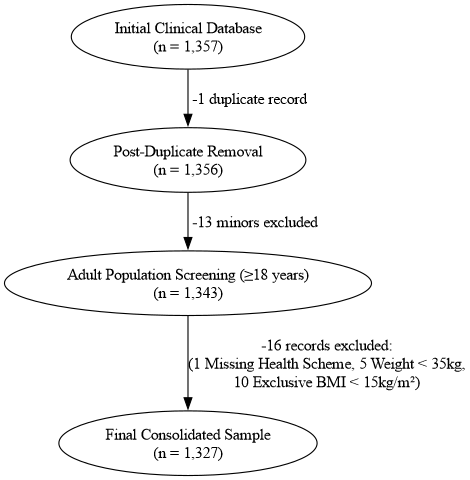

In [2]:
from IPython.display import Image
Image('data_cleaning_flow.png')

Se trabaja a partir de la base de datos resultante de los cambios realizadas en el anterior estudio.

In [3]:
df = pd.read_csv('data_afro_final.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1327 entries, 0 to 1326
Data columns (total 58 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Departamento_Tamizaje         1327 non-null   object 
 1   Municipio_Tamizaje            1327 non-null   object 
 2   Edad                          1327 non-null   int64  
 3   Genero                        1327 non-null   object 
 4   Escolaridad                   1327 non-null   object 
 5   Regimen_Salud                 1327 non-null   object 
 6   Medicacion_Diabetes           1327 non-null   object 
 7   Diabetes_Embarazo             1327 non-null   object 
 8   Hipertension                  1327 non-null   object 
 9   Medicacion_Hipertension       1327 non-null   object 
 10  Colesterol_Alto               1327 non-null   object 
 11  Medicacion_Colesterol         1327 non-null   object 
 12  Insuficiencia_Renal           1327 non-null   object 
 13  Dia

In [5]:
df.head()

,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,...,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC,IMC_CAL,TFG_CDK_EPI_CAL,Estadio_ERC_CAL,Estadio_ERC_Binaria
0,BOLIVAR,Zona_costera,57,Femenino,No_escolarizado-Primaria,Subsidiado-No_Tiene,Si,No,Si,Si,...,No,1,0,1.61-1.70,61-80,Normal,22.86,74.565522,G2: Descenso Leve (60-89),No moderado
1,ATLANTICO,Zona_urbana,28,Femenino,Secundaria-Bachiller,Subsidiado-No_Tiene,No,Sí,No,No,...,No,0,0,1.61-1.70,61-80,Alto,28.23,120.737073,G1: Normal o Elevado (≥90),No moderado
2,ATLANTICO,Zona_urbana,35,Femenino,Secundaria-Bachiller,Subsidiado-No_Tiene,No,No,No,No,...,No,0,0,1.61-1.70,>80,Obesidad,34.37,NaN,NaN,NaN
3,ATLANTICO,Zona_urbana,19,Femenino,No_escolarizado-Primaria,Subsidiado-No_Tiene,No,No,No,No,...,No,0,0,1.61-1.70,61-80,Normal,24.77,NaN,NaN,NaN
4,ATLANTICO,Zona_urbana,44,Femenino,Secundaria-Bachiller,Subsidiado-No_Tiene,No,No,No,No,...,No,0,0,1.50-1.60,61-80,Alto,28.40,NaN,NaN,NaN


### **Funciones**

In [6]:
def resumen_numerico(df):
    num_df = df.select_dtypes(include=[np.number])

    if num_df.empty:
        print("No hay variables numéricas en el DataFrame.")
        return None

    resumen = pd.DataFrame({
        'tipo': num_df.dtypes,
        'n_valores': num_df.count(),
        'n_nulos': num_df.isnull().sum(),
        '%_nulos': (num_df.isnull().mean() * 100).round(2),
        'media': num_df.mean(),
        'mediana': num_df.median(),
        'desv_std': num_df.std(),
        'min': num_df.min(),
        'max': num_df.max(),
        'asimetria': num_df.skew(),
        'curtosis': num_df.kurt(),
        'n_unicos': num_df.nunique()
    })

    return resumen.round(2)

In [7]:
def resumen_categorico(df):
    cat_df = df.select_dtypes(include=['object', 'category'])

    if cat_df.empty:
        print("No hay variables categóricas en el DataFrame.")
        return None

    filas = []
    for col in cat_df.columns:
        conteos = cat_df[col].value_counts()
        moda = conteos.index[0] if not conteos.empty else None
        filas.append({
            'variable': col,
            'n_valores': cat_df[col].count(),
            'n_nulos': cat_df[col].isnull().sum(),
            '%_nulos': round(cat_df[col].isnull().mean() * 100, 2),
            'n_categorias': cat_df[col].nunique(),
            'categoria_mas_frecuente': moda,
            'frecuencia_moda': conteos.iloc[0] if not conteos.empty else 0,
            '%_moda': round((conteos.iloc[0] / cat_df[col].count()) * 100, 2) if not conteos.empty else 0
        })

    return pd.DataFrame(filas).set_index('variable')

## **Resumen general**

La base de datos cuenta con **1327 individuos**.

In [8]:
resumen_numerico(df)

,tipo,n_valores,n_nulos,%_nulos,media,mediana,desv_std,min,max,asimetria,curtosis,n_unicos
Edad,int64,1327,0,0.00,46.05,46.00,17.72,18.00,97.00,0.29,-0.66,73
Peso,int64,1327,0,0.00,71.62,72.00,14.18,37.00,125.00,0.18,0.05,76
Talla,float64,1327,0,0.00,1.65,1.65,0.08,1.44,1.96,0.10,-0.07,44
IMC,float64,1327,0,0.00,26.59,26.06,5.79,15.03,48.00,0.48,0.23,558
Creatinina,float64,466,861,64.88,1.16,1.00,0.39,0.60,2.50,0.47,-0.76,188
TFG_CDK_EPI,float64,466,861,64.88,81.20,78.79,31.34,22.14,168.19,0.32,-0.75,431
TFG_Edad,float64,466,861,64.88,82.33,82.00,17.29,33.00,112.00,-0.26,-0.45,71
Presion_Sistolica,float64,1280,47,3.54,123.80,120.00,16.66,90.00,203.00,1.39,2.69,82
Presion_Diastolica,float64,1280,47,3.54,79.41,80.00,33.39,28.00,880.00,21.59,516.44,57
Presion_Sistolica\t> 130,int64,1327,0,0.00,0.19,0.00,0.40,0.00,1.00,1.55,0.41,2


In [9]:
resumen_categorico(df)

,n_valores,n_nulos,%_nulos,n_categorias,categoria_mas_frecuente,frecuencia_moda,%_moda
variable,,,,,,,
Departamento_Tamizaje,1327,0,0.00,2,ATLANTICO,935,70.46
Municipio_Tamizaje,1327,0,0.00,3,Zona_urbana,558,42.05
Genero,1327,0,0.00,2,Femenino,850,64.05
Escolaridad,1327,0,0.00,3,Secundaria-Bachiller,467,35.19
Regimen_Salud,1327,0,0.00,2,Subsidiado-No_Tiene,971,73.17
Medicacion_Diabetes,1327,0,0.00,2,No,1250,94.20
Diabetes_Embarazo,1327,0,0.00,3,No,832,62.70
Hipertension,1327,0,0.00,2,No,951,71.67
Medicacion_Hipertension,1327,0,0.00,2,No,978,73.70


### **Resumen de estado nutricional**

In [10]:
resumen_numerico(df[['Peso', 'Talla', 'IMC']])

,tipo,n_valores,n_nulos,%_nulos,media,mediana,desv_std,min,max,asimetria,curtosis,n_unicos
Peso,int64,1327,0,0.0,71.62,72.00,14.18,37.00,125.00,0.18,0.05,76
Talla,float64,1327,0,0.0,1.65,1.65,0.08,1.44,1.96,0.10,-0.07,44
IMC,float64,1327,0,0.0,26.59,26.06,5.79,15.03,48.00,0.48,0.23,558


In [11]:
cat_imc = df['Categoria_IMC'].value_counts().reset_index()
cat_imc.columns = ['Categoria', 'Frecuencia']
cat_imc['Porcentaje'] = (cat_imc['Frecuencia'] / len(df) * 100).round(2)
cat_imc

,Categoria,Frecuencia,Porcentaje
0,Normal,450,33.91
1,Alto,431,32.48
2,Obesidad,351,26.45
3,Bajo,95,7.16


C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2668391095.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Genero', y='IMC',
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2668391095.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(conteos.index, rotation=30, ha='right', fontsize=9)


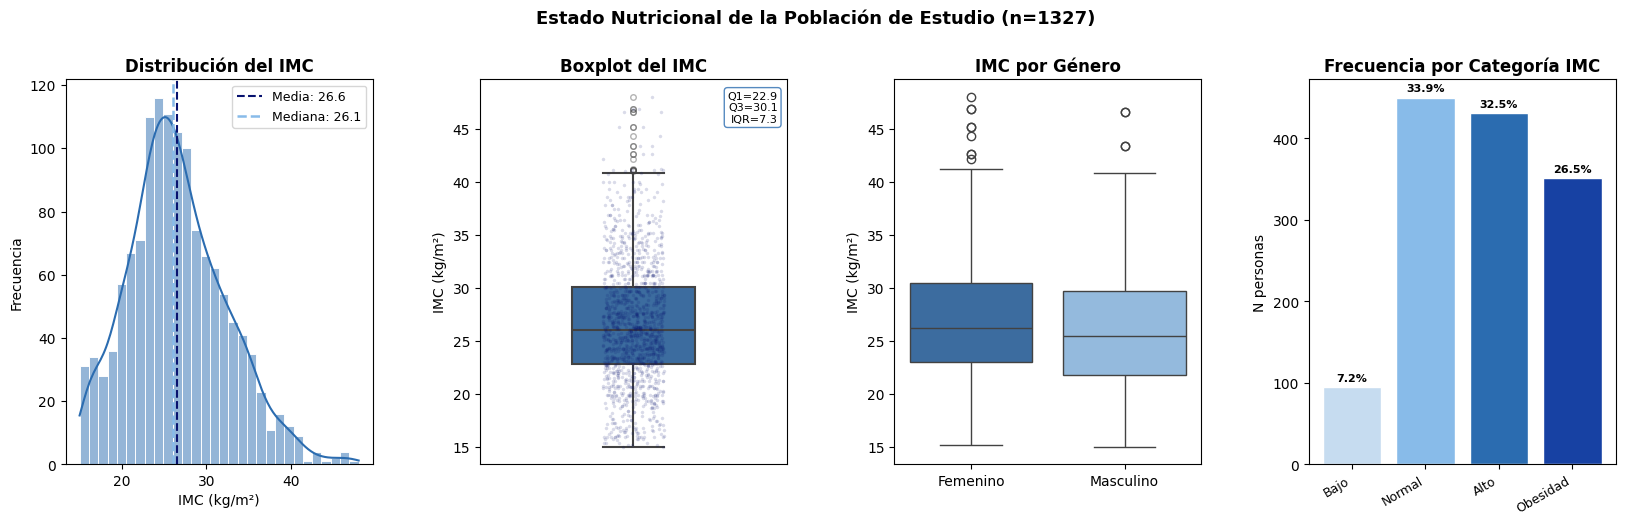

In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

orden = ['Bajo', 'Normal', 'Alto', 'Obesidad']
orden_presente = [c for c in orden if c in df['Categoria_IMC'].unique()]

paleta = {
    'Bajo':     '#C6DCF0',
    'Normal':   '#88BBE9',
    'Alto':     '#2B6CB0',
    'Obesidad': "#1741A3"
}

fig = plt.figure(figsize=(20, 5))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

# ── 1. Histograma con KDE ──
ax1 = fig.add_subplot(gs[0])
sns.histplot(df['IMC'], bins=30, kde=True, color='#2B6CB0', edgecolor='white', ax=ax1)
ax1.axvline(df['IMC'].mean(),   color='#07126F', linestyle='--', linewidth=1.5, label=f"Media: {df['IMC'].mean():.1f}")
ax1.axvline(df['IMC'].median(), color='#88BBE9', linestyle='--', linewidth=1.8, label=f"Mediana: {df['IMC'].median():.1f}")
ax1.set_title('Distribución del IMC', fontweight='bold')
ax1.set_xlabel('IMC (kg/m²)')
ax1.set_ylabel('Frecuencia')
ax1.legend(fontsize=9)

# ── 2. Boxplot univariado IMC ──
ax2 = fig.add_subplot(gs[1])
sns.boxplot(y=df['IMC'], color='#2B6CB0', width=0.4, linewidth=1.5,
            flierprops=dict(marker='o', color='#07126F', alpha=0.4, markersize=4),
            ax=ax2)
sns.stripplot(y=df['IMC'], color='#07126F', alpha=0.15, size=2.5, jitter=True, ax=ax2)
ax2.set_title('Boxplot del IMC', fontweight='bold')
ax2.set_ylabel('IMC (kg/m²)')
ax2.set_xticks([])
q1, q3 = df['IMC'].quantile([0.25, 0.75])
ax2.text(0.97, 0.97, f'Q1={q1:.1f}\nQ3={q3:.1f}\nIQR={q3-q1:.1f}',
         transform=ax2.transAxes, fontsize=8, va='top', ha='right',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#2B6CB0', alpha=0.8))

# ── 3. Boxplot por género ──
ax3 = fig.add_subplot(gs[2])
sns.boxplot(data=df, x='Genero', y='IMC',
            palette={'Masculino': '#88BBE9', 'Femenino': '#2B6CB0'}, ax=ax3)
ax3.set_title('IMC por Género', fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('IMC (kg/m²)')

# ── 4. Barras de Categoria_IMC ──
ax4 = fig.add_subplot(gs[3])
conteos = df['Categoria_IMC'].value_counts().reindex(orden_presente)
colores = [paleta.get(c, '#88BBE9') for c in conteos.index]
bars = ax4.bar(conteos.index, conteos.values, color=colores, edgecolor='white')
ax4.set_title('Frecuencia por Categoría IMC', fontweight='bold')
ax4.set_xlabel('')
ax4.set_ylabel('N personas')
ax4.set_xticklabels(conteos.index, rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars, conteos.values):
    pct = val / len(df) * 100
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Estado Nutricional de la Población de Estudio (n=1327)',
             fontsize=13, fontweight='bold', y=1.02)
plt.show()

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

orden_presente = [c for c in ['Bajo', 'Normal', 'Alto', 'Obesidad']
                  if c in df['Categoria_IMC'].unique()]

paleta_cat = {
    'Bajo':     '#C6DCF0',
    'Normal':   '#88BBE9',
    'Alto':     '#2B6CB0',
    'Obesidad': '#07126F'
}
colores_cat = [paleta_cat[c] for c in orden_presente]
blues_hue   = ['#C6DCF0', '#07126F']  

## **IMC vs Varaibles numéricas**

C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\952392221.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Categoria_IMC', y=var,
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\952392221.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Categoria_IMC', y=var,
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\952392221.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Categoria_IMC', y=var,


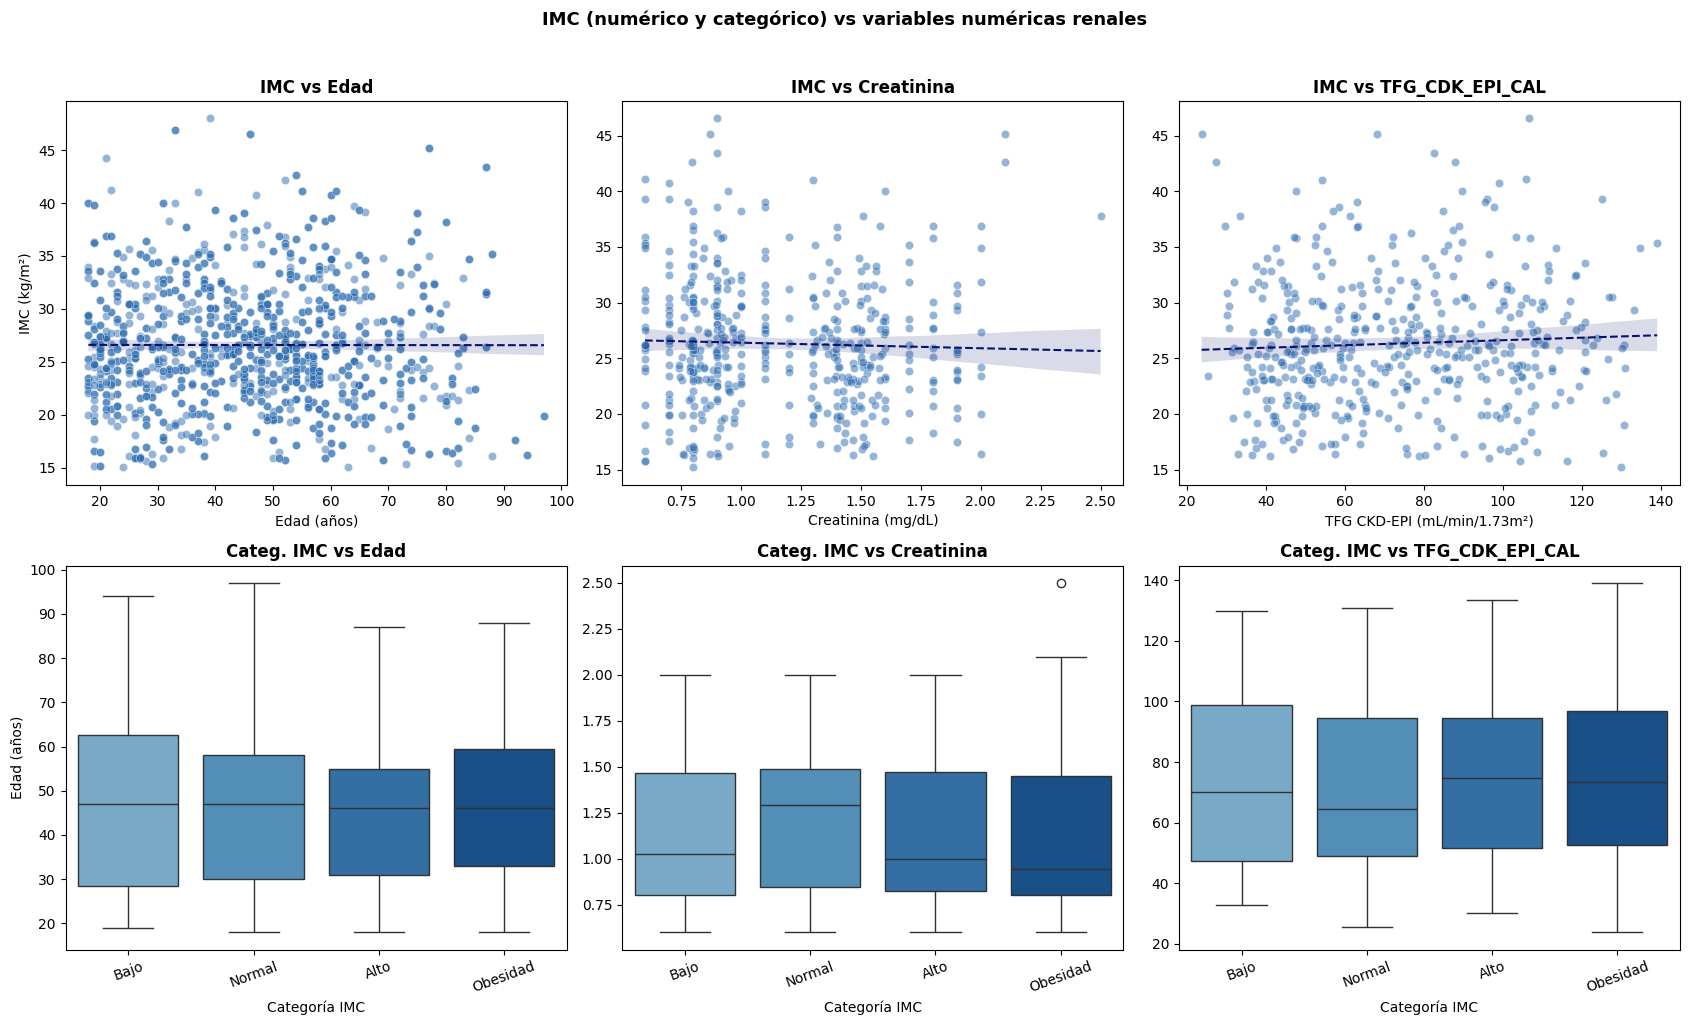

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

num_vars = [
    ('Edad',            'Edad (años)'),
    ('Creatinina',      'Creatinina (mg/dL)'),
    ('TFG_CDK_EPI_CAL', 'TFG CKD-EPI (mL/min/1.73m²)')
]

for j, (var, xlabel) in enumerate(num_vars):
    sns.scatterplot(data=df, x=var, y='IMC',
                    color='#2B6CB0', alpha=0.5, ax=axes[0, j])
    sns.regplot(data=df, x=var, y='IMC', scatter=False, color='#07126F',
                line_kws={'linestyle': '--', 'linewidth': 1.5}, ax=axes[0, j])
    axes[0, j].set_title(f'IMC vs {var}', fontweight='bold')
    axes[0, j].set_xlabel(xlabel)
    axes[0, j].set_ylabel('IMC (kg/m²)' if j == 0 else '')

for j, (var, ylabel) in enumerate(num_vars):
    pal = sns.color_palette("Blues", len(orden_presente) + 3)[3:]
    sns.boxplot(data=df, x='Categoria_IMC', y=var,
                order=orden_presente, palette=pal, ax=axes[1, j])
    axes[1, j].set_title(f'Categ. IMC vs {var}', fontweight='bold')
    axes[1, j].set_xlabel('Categoría IMC')
    axes[1, j].set_ylabel(ylabel if j == 0 else '')
    axes[1, j].tick_params(axis='x', rotation=20)

plt.suptitle('IMC (numérico y categórico) vs variables numéricas renales',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **IMC vs Variables categóricas**

C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2698458596.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='IMC',
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2698458596.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='IMC',
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2698458596.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='IMC',
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2698458596.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

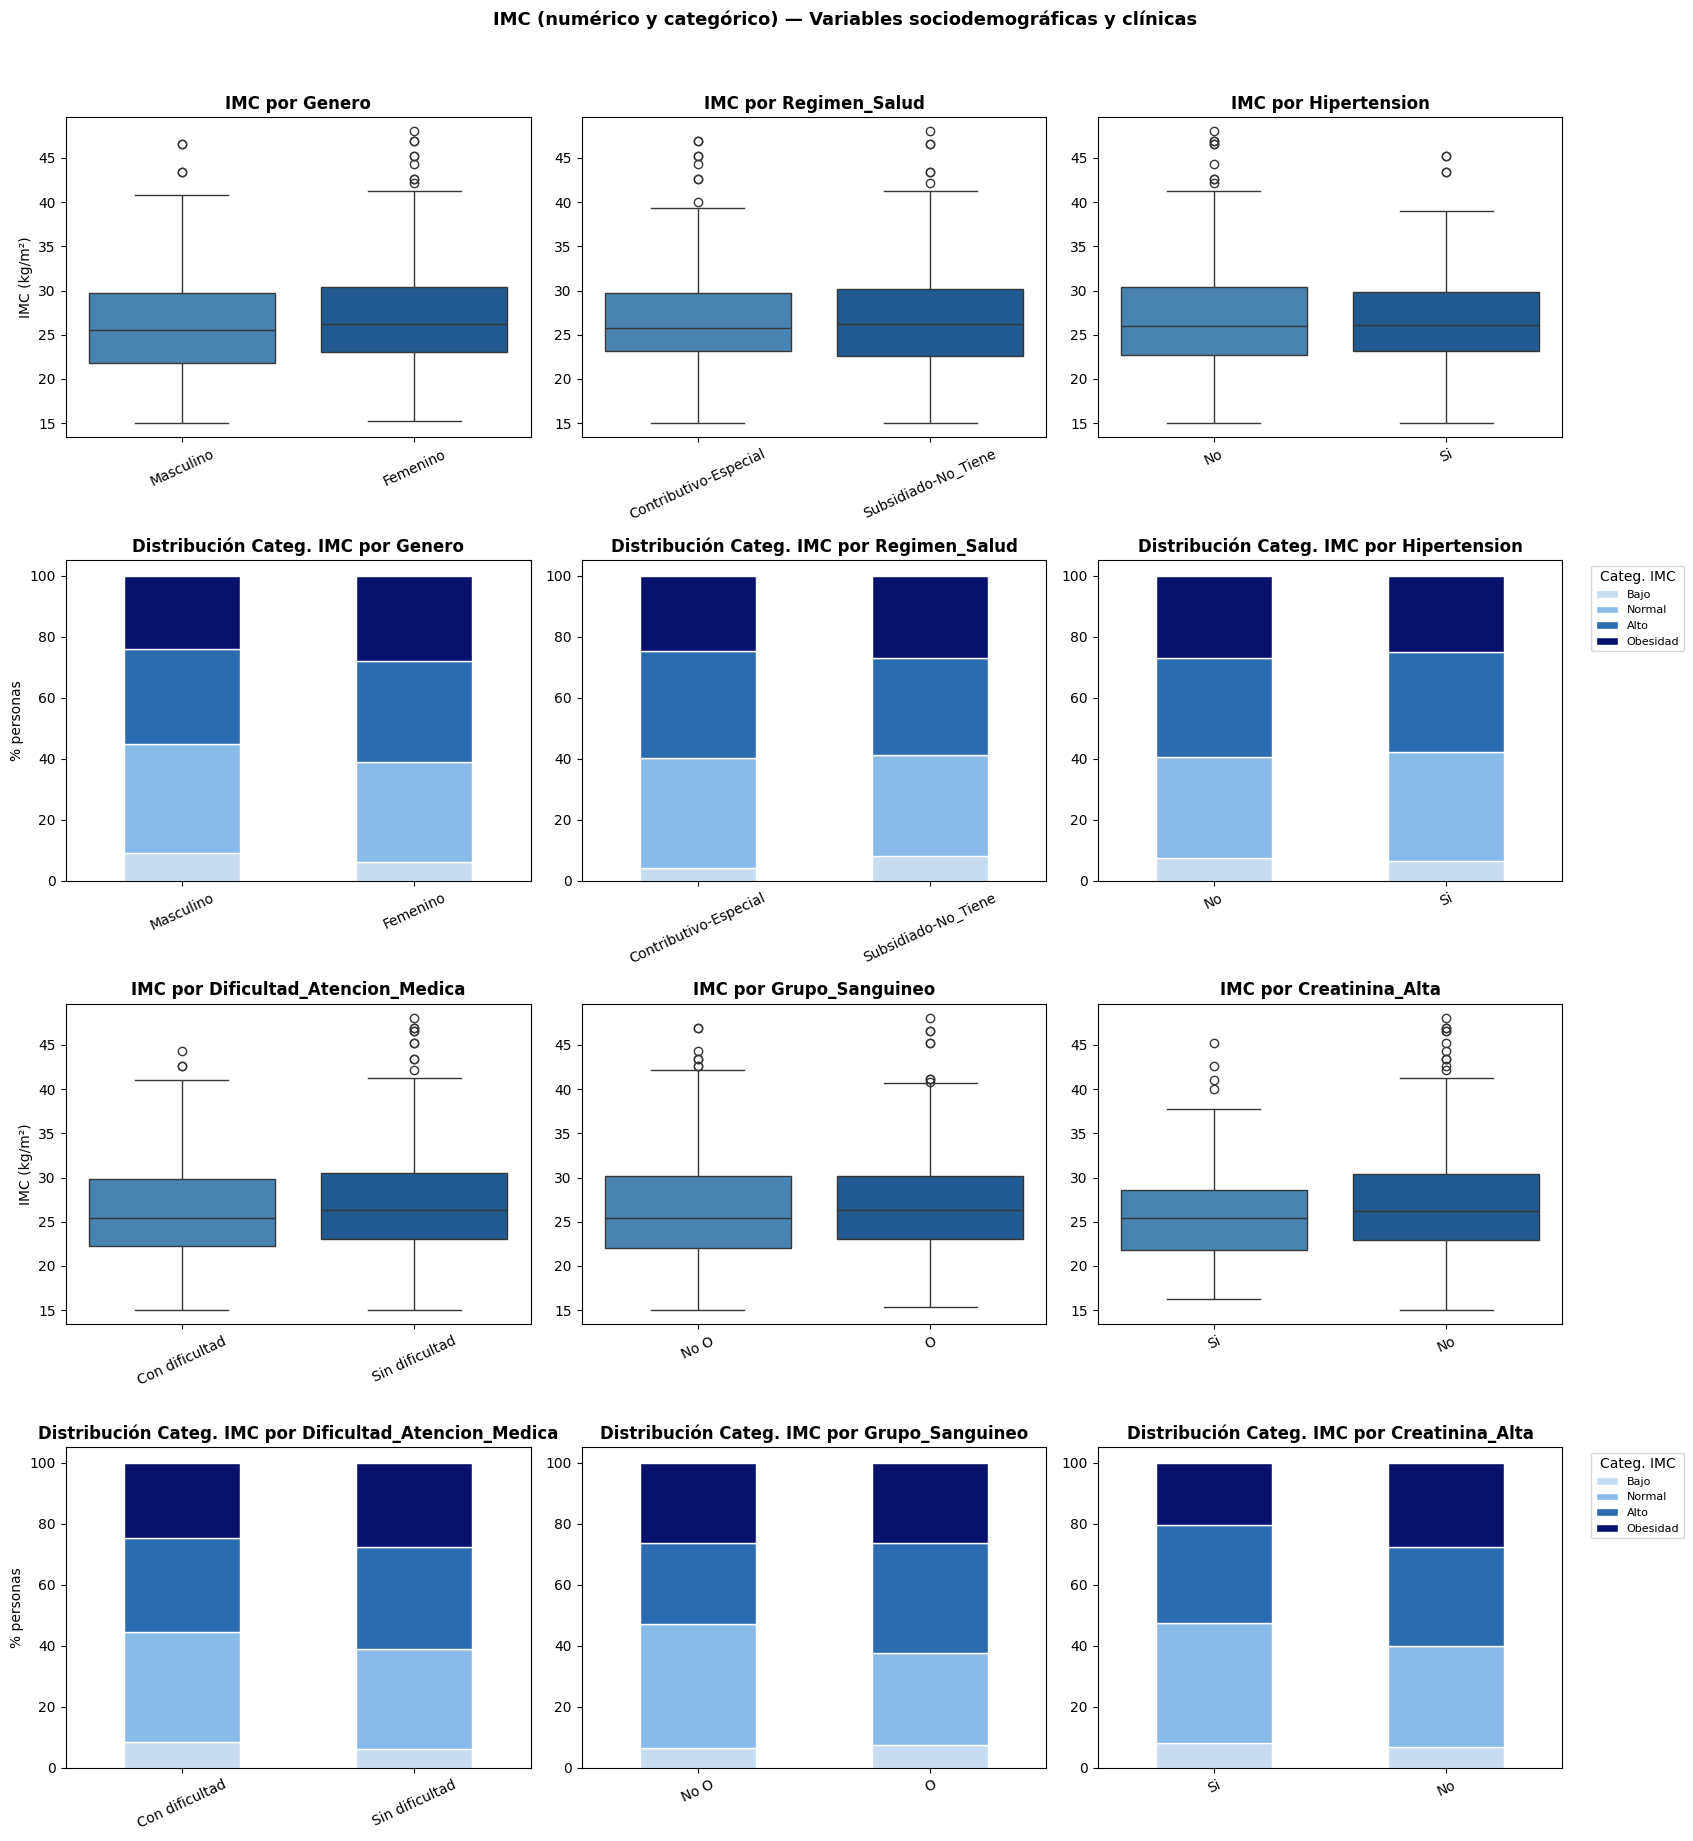

In [15]:
cat_g1 = ['Genero', 'Regimen_Salud', 'Hipertension',
          'Dificultad_Atencion_Medica', 'Grupo_Sanguineo', 'Creatinina_Alta']

fig, axes = plt.subplots(4, 3, figsize=(17, 18))

for j, var in enumerate(cat_g1):
    col     = j % 3          # columna: 0,1,2 | 0,1,2
    fila_box = (j // 3) * 2  # boxplot:  0    |  2
    fila_bar = fila_box + 1  # stacked:  1    |  3

    orden_var = df.groupby(var)['IMC'].median().sort_values().index.tolist()
    pal = sns.color_palette("Blues", len(orden_var) + 3)[3:]

    # Boxplot IMC numérico
    sns.boxplot(data=df, x=var, y='IMC',
                order=orden_var, palette=pal, ax=axes[fila_box, col])
    axes[fila_box, col].set_title(f'IMC por {var}', fontweight='bold')
    axes[fila_box, col].set_xlabel('')
    axes[fila_box, col].set_ylabel('IMC (kg/m²)' if col == 0 else '')
    axes[fila_box, col].tick_params(axis='x', rotation=25)

    # Stacked bar Categoria_IMC
    ct = pd.crosstab(df[var], df['Categoria_IMC'], normalize='index') * 100
    ct = ct.reindex(columns=orden_presente)
    ct.reindex(orden_var).plot(kind='bar', stacked=True, color=colores_cat,
                                edgecolor='white', ax=axes[fila_bar, col],
                                legend=(col == 2))
    axes[fila_bar, col].set_title(f'Distribución Categ. IMC por {var}', fontweight='bold')
    axes[fila_bar, col].set_xlabel('')
    axes[fila_bar, col].set_ylabel('% personas' if col == 0 else '')
    axes[fila_bar, col].tick_params(axis='x', rotation=25)
    if col == 2:
        axes[fila_bar, col].legend(title='Categ. IMC',
                                   bbox_to_anchor=(1.05, 1), fontsize=8)

plt.suptitle('IMC (numérico y categórico) — Variables sociodemográficas y clínicas',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **Relación IMC por departamento/municipio**

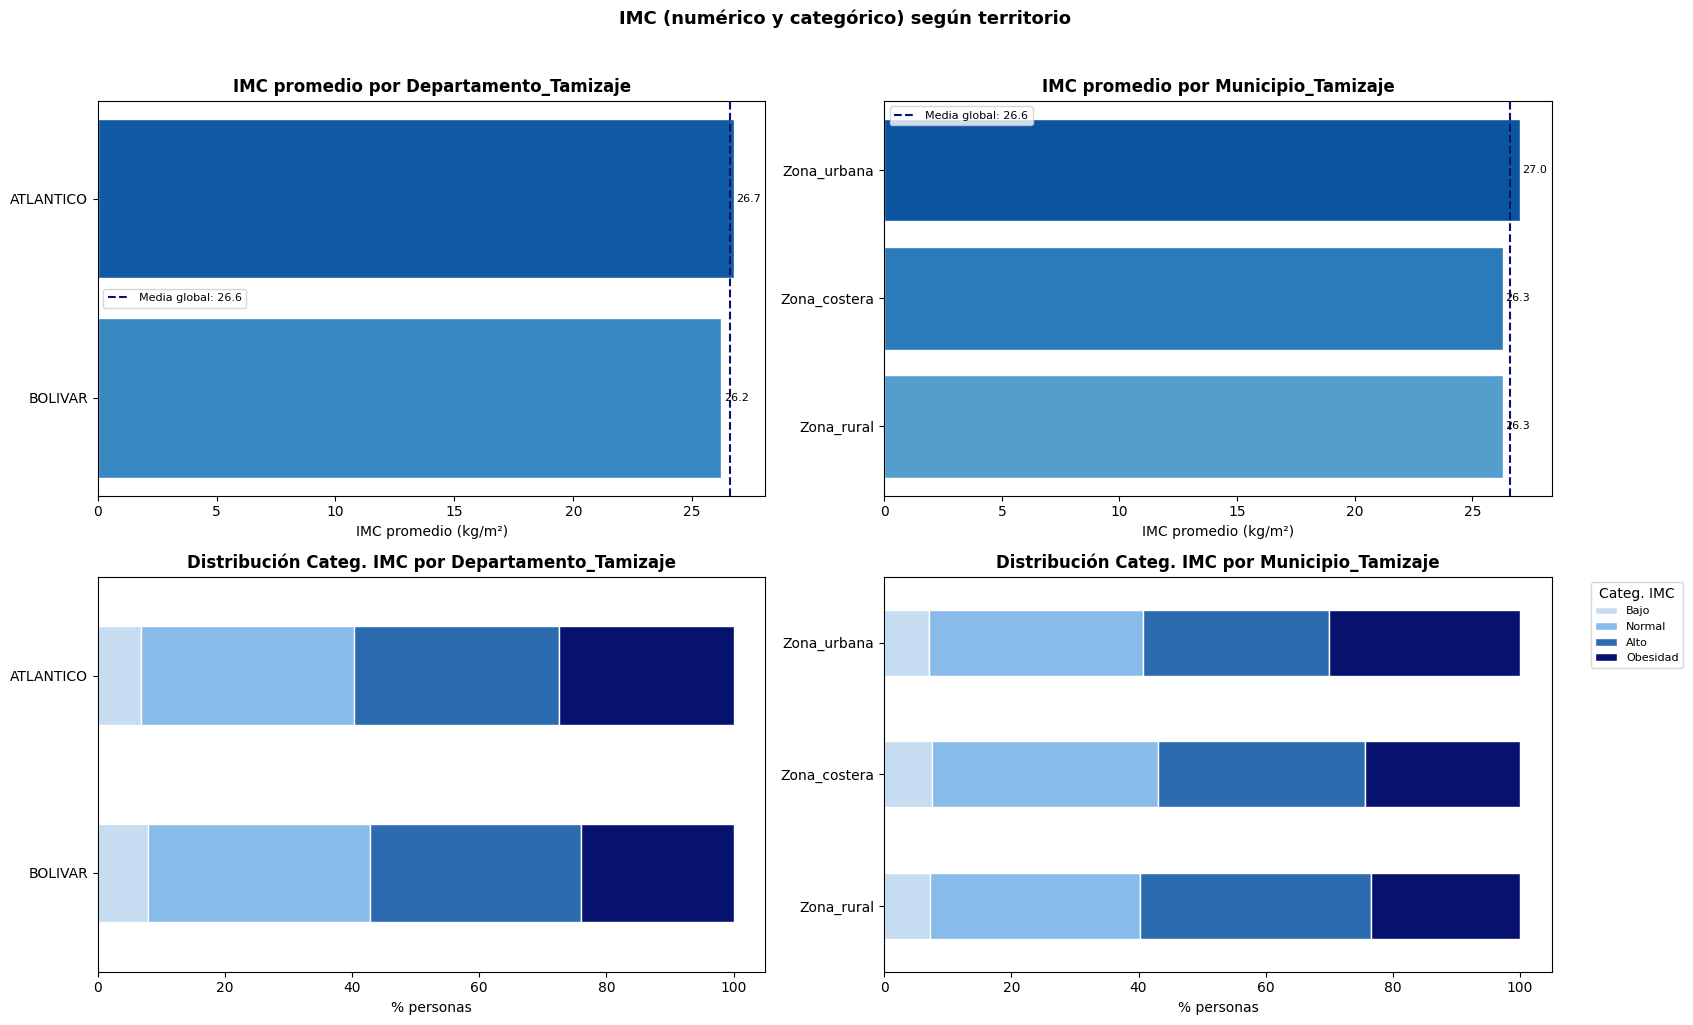

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(17, 10))

top_mun = df['Municipio_Tamizaje'].value_counts().head(10).index

for j, (geo_var, subset) in enumerate([
        ('Departamento_Tamizaje', df),
        ('Municipio_Tamizaje',    df[df['Municipio_Tamizaje'].isin(top_mun)])]):

    orden_geo = subset.groupby(geo_var)['IMC'].mean().sort_values().index.tolist()
    pal = sns.color_palette("Blues", len(orden_geo) + 3)[3:]

    # Fila 1: IMC promedio (barh horizontal)
    imc_mean = subset.groupby(geo_var)['IMC'].mean().reindex(orden_geo)
    axes[0, j].barh(imc_mean.index, imc_mean.values, color=pal, edgecolor='white')
    axes[0, j].axvline(df['IMC'].mean(), color='#07126F', linestyle='--',
                       linewidth=1.5, label=f'Media global: {df["IMC"].mean():.1f}')
    axes[0, j].set_title(f'IMC promedio por {geo_var}', fontweight='bold')
    axes[0, j].set_xlabel('IMC promedio (kg/m²)')
    axes[0, j].legend(fontsize=8)
    for i, val in enumerate(imc_mean.values):
        axes[0, j].text(val + 0.1, i, f'{val:.1f}', va='center', fontsize=8)

    # Fila 2: distribución Categoria_IMC (%)
    ct = pd.crosstab(subset[geo_var], subset['Categoria_IMC'], normalize='index') * 100
    ct = ct.reindex(columns=orden_presente)
    ct.reindex(orden_geo).plot(kind='barh', stacked=True, color=colores_cat,
                                edgecolor='white', ax=axes[1, j], legend=(j == 1))
    axes[1, j].set_title(f'Distribución Categ. IMC por {geo_var}', fontweight='bold')
    axes[1, j].set_xlabel('% personas')
    axes[1, j].set_ylabel('')
    if j == 1:
        axes[1, j].legend(title='Categ. IMC', bbox_to_anchor=(1.05, 1), fontsize=8)

plt.suptitle('IMC (numérico y categórico) según territorio',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\4232462634.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x='TFG_CDK_EPI_CAL', y='IMC', palette=blues_hue,
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\4232462634.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend(title='ERC Binaria', fontsize=8)
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\4232462634.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Estadio_ERC_CAL', y='IMC',
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\4232462634.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` varia

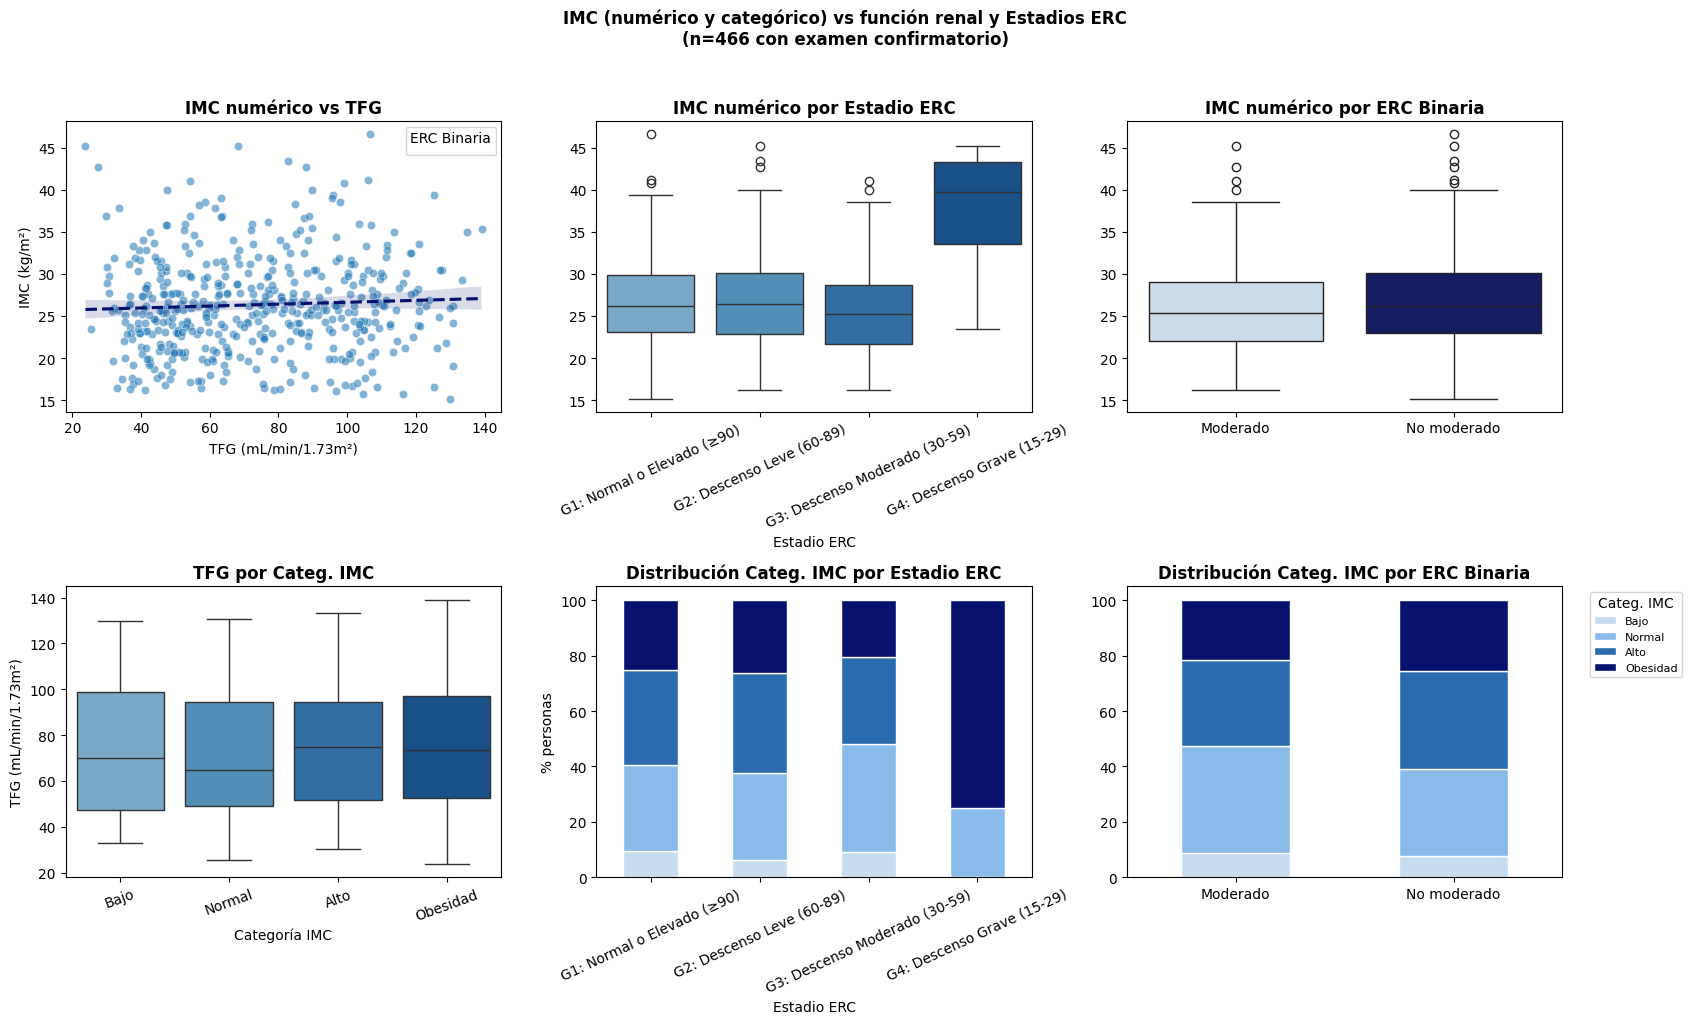

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

orden_estadio = sorted(df['Estadio_ERC_CAL'].dropna().unique())
orden_bin     = sorted(df['Estadio_ERC_Binaria'].dropna().unique())
pal_estadio   = sns.color_palette("Blues", len(orden_estadio) + 3)[3:]

# ── Fila 1: IMC numérico ──
# scatter IMC vs TFG | hue: ERC Binaria
sns.scatterplot(data=df, x='TFG_CDK_EPI_CAL', y='IMC', palette=blues_hue,
                alpha=0.55, ax=axes[0, 0])
sns.regplot(data=df, x='TFG_CDK_EPI_CAL', y='IMC', scatter=False,
            color='#07126F', line_kws={'linestyle': '--'}, ax=axes[0, 0])
axes[0, 0].set_title('IMC numérico vs TFG', fontweight='bold')
axes[0, 0].set_xlabel('TFG (mL/min/1.73m²)')
axes[0, 0].set_ylabel('IMC (kg/m²)')
axes[0, 0].legend(title='ERC Binaria', fontsize=8)

# boxplot IMC by Estadio_ERC_CAL
sns.boxplot(data=df, x='Estadio_ERC_CAL', y='IMC',
            order=orden_estadio, palette=pal_estadio, ax=axes[0, 1])
axes[0, 1].set_title('IMC numérico por Estadio ERC', fontweight='bold')
axes[0, 1].set_xlabel('Estadio ERC')
axes[0, 1].set_ylabel('')
axes[0, 1].tick_params(axis='x', rotation=25)

# boxplot IMC by ERC Binaria
sns.boxplot(data=df, x='Estadio_ERC_Binaria', y='IMC',
            order=orden_bin, palette=blues_hue, ax=axes[0, 2])
axes[0, 2].set_title('IMC numérico por ERC Binaria', fontweight='bold')
axes[0, 2].set_xlabel('')
axes[0, 2].set_ylabel('')

# ── Fila 2: Categoria_IMC ──
# boxplot TFG by Categoria_IMC
pal_n = sns.color_palette("Blues", len(orden_presente) + 3)[3:]
sns.boxplot(data=df, x='Categoria_IMC', y='TFG_CDK_EPI_CAL',
            order=orden_presente, palette=pal_n, ax=axes[1, 0])
axes[1, 0].set_title('TFG por Categ. IMC', fontweight='bold')
axes[1, 0].set_xlabel('Categoría IMC')
axes[1, 0].set_ylabel('TFG (mL/min/1.73m²)')
axes[1, 0].tick_params(axis='x', rotation=20)

# stacked bar Categoria_IMC by Estadio_ERC_CAL
ct_est = pd.crosstab(df['Estadio_ERC_CAL'], df['Categoria_IMC'], normalize='index') * 100
ct_est = ct_est.reindex(columns=orden_presente)
ct_est.reindex(orden_estadio).plot(kind='bar', stacked=True, color=colores_cat,
                                    edgecolor='white', ax=axes[1, 1], legend=False)
axes[1, 1].set_title('Distribución Categ. IMC por Estadio ERC', fontweight='bold')
axes[1, 1].set_xlabel('Estadio ERC')
axes[1, 1].set_ylabel('% personas')
axes[1, 1].tick_params(axis='x', rotation=25)

# stacked bar Categoria_IMC by ERC Binaria
ct_bin = pd.crosstab(df['Estadio_ERC_Binaria'], df['Categoria_IMC'], normalize='index') * 100
ct_bin = ct_bin.reindex(columns=orden_presente)
ct_bin.reindex(orden_bin).plot(kind='bar', stacked=True, color=colores_cat,
                                edgecolor='white', ax=axes[1, 2], legend=True)
axes[1, 2].set_title('Distribución Categ. IMC por ERC Binaria', fontweight='bold')
axes[1, 2].set_xlabel('')
axes[1, 2].set_ylabel('')
axes[1, 2].tick_params(axis='x', rotation=0)
axes[1, 2].legend(title='Categ. IMC', bbox_to_anchor=(1.05, 1), fontsize=8)

plt.suptitle('IMC (numérico y categórico) vs función renal y Estadios ERC\n(n=466 con examen confirmatorio)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **Datos completos según `TFG_EPI_CAL`**

### **Base de datos**

In [18]:
df_tfg = df.dropna(subset=['TFG_CDK_EPI_CAL'])

In [19]:
df_tfg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 466 entries, 0 to 1326
Data columns (total 58 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Departamento_Tamizaje         466 non-null    object 
 1   Municipio_Tamizaje            466 non-null    object 
 2   Edad                          466 non-null    int64  
 3   Genero                        466 non-null    object 
 4   Escolaridad                   466 non-null    object 
 5   Regimen_Salud                 466 non-null    object 
 6   Medicacion_Diabetes           466 non-null    object 
 7   Diabetes_Embarazo             466 non-null    object 
 8   Hipertension                  466 non-null    object 
 9   Medicacion_Hipertension       466 non-null    object 
 10  Colesterol_Alto               466 non-null    object 
 11  Medicacion_Colesterol         466 non-null    object 
 12  Insuficiencia_Renal           466 non-null    object 
 13  Dialisis 

In [20]:
df_tfg.head()

,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,...,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC,IMC_CAL,TFG_CDK_EPI_CAL,Estadio_ERC_CAL,Estadio_ERC_Binaria
0,BOLIVAR,Zona_costera,57,Femenino,No_escolarizado-Primaria,Subsidiado-No_Tiene,Si,No,Si,Si,...,No,1,0,1.61-1.70,61-80,Normal,22.86,74.565522,G2: Descenso Leve (60-89),No moderado
1,ATLANTICO,Zona_urbana,28,Femenino,Secundaria-Bachiller,Subsidiado-No_Tiene,No,Sí,No,No,...,No,0,0,1.61-1.70,61-80,Alto,28.23,120.737073,G1: Normal o Elevado (≥90),No moderado
9,BOLIVAR,Zona_costera,56,Femenino,No_escolarizado-Primaria,Subsidiado-No_Tiene,Si,No,Si,Si,...,No,1,1,1.61-1.70,41-60,Normal,23.15,86.421559,G2: Descenso Leve (60-89),No moderado
10,BOLIVAR,Zona_costera,69,Femenino,No_escolarizado-Primaria,Subsidiado-No_Tiene,No,No aplica,No,No,...,No,0,0,1.61-1.70,41-60,Normal,20.96,60.984151,G2: Descenso Leve (60-89),No moderado
11,ATLANTICO,Zona_urbana,56,Masculino,Secundaria-Bachiller,Subsidiado-No_Tiene,No,No aplica,No,No,...,No,1,0,1.50-1.60,61-80,Alto,25.48,100.237891,G1: Normal o Elevado (≥90),No moderado


### **Resumen general**

In [21]:
resumen_numerico(df_tfg)

,tipo,n_valores,n_nulos,%_nulos,media,mediana,desv_std,min,max,asimetria,curtosis,n_unicos
Edad,int64,466,0,0.00,47.67,48.00,17.29,18.00,97.00,0.26,-0.45,71
Peso,int64,466,0,0.00,71.03,70.00,14.05,39.00,120.00,0.15,-0.14,62
Talla,float64,466,0,0.00,1.65,1.65,0.08,1.44,1.96,0.20,0.34,36
IMC,float64,466,0,0.00,26.32,25.77,5.77,15.19,46.56,0.60,0.43,256
Creatinina,float64,466,0,0.00,1.16,1.00,0.39,0.60,2.50,0.47,-0.76,188
TFG_CDK_EPI,float64,466,0,0.00,81.20,78.79,31.34,22.14,168.19,0.32,-0.75,431
TFG_Edad,float64,466,0,0.00,82.33,82.00,17.29,33.00,112.00,-0.26,-0.45,71
Presion_Sistolica,float64,454,12,2.58,124.68,120.00,16.49,97.00,200.00,1.41,2.83,64
Presion_Diastolica,float64,454,12,2.58,81.78,80.00,54.27,45.00,880.00,14.11,206.38,46
Presion_Sistolica\t> 130,int64,466,0,0.00,0.21,0.00,0.41,0.00,1.00,1.43,0.03,2


In [22]:
resumen_categorico(df_tfg)

,n_valores,n_nulos,%_nulos,n_categorias,categoria_mas_frecuente,frecuencia_moda,%_moda
variable,,,,,,,
Departamento_Tamizaje,466,0,0.0,2,ATLANTICO,361,77.47
Municipio_Tamizaje,466,0,0.0,3,Zona_urbana,224,48.07
Genero,466,0,0.0,2,Femenino,286,61.37
Escolaridad,466,0,0.0,3,Secundaria-Bachiller,177,37.98
Regimen_Salud,466,0,0.0,2,Subsidiado-No_Tiene,341,73.18
Medicacion_Diabetes,466,0,0.0,2,No,433,92.92
Diabetes_Embarazo,466,0,0.0,3,No,266,57.08
Hipertension,466,0,0.0,2,No,268,57.51
Medicacion_Hipertension,466,0,0.0,2,No,275,59.01


### **Resumen Estado nutricional**

#### **IMC**

In [23]:
resumen_numerico(df_tfg[['Peso', 'Talla', 'IMC']])

,tipo,n_valores,n_nulos,%_nulos,media,mediana,desv_std,min,max,asimetria,curtosis,n_unicos
Peso,int64,466,0,0.0,71.03,70.00,14.05,39.00,120.00,0.15,-0.14,62
Talla,float64,466,0,0.0,1.65,1.65,0.08,1.44,1.96,0.20,0.34,36
IMC,float64,466,0,0.0,26.32,25.77,5.77,15.19,46.56,0.60,0.43,256


In [24]:
cat_imc = df_tfg['Categoria_IMC'].value_counts().reset_index()
cat_imc.columns = ['Categoria', 'Frecuencia']
cat_imc['Porcentaje'] = (cat_imc['Frecuencia'] / len(df_tfg) * 100).round(2)
cat_imc

,Categoria,Frecuencia,Porcentaje
0,Normal,159,34.12
1,Alto,157,33.69
2,Obesidad,112,24.03
3,Bajo,38,8.15


C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\4284628536.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tfg, x='Genero', y='IMC',
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\4284628536.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(conteos.index, rotation=30, ha='right', fontsize=9)


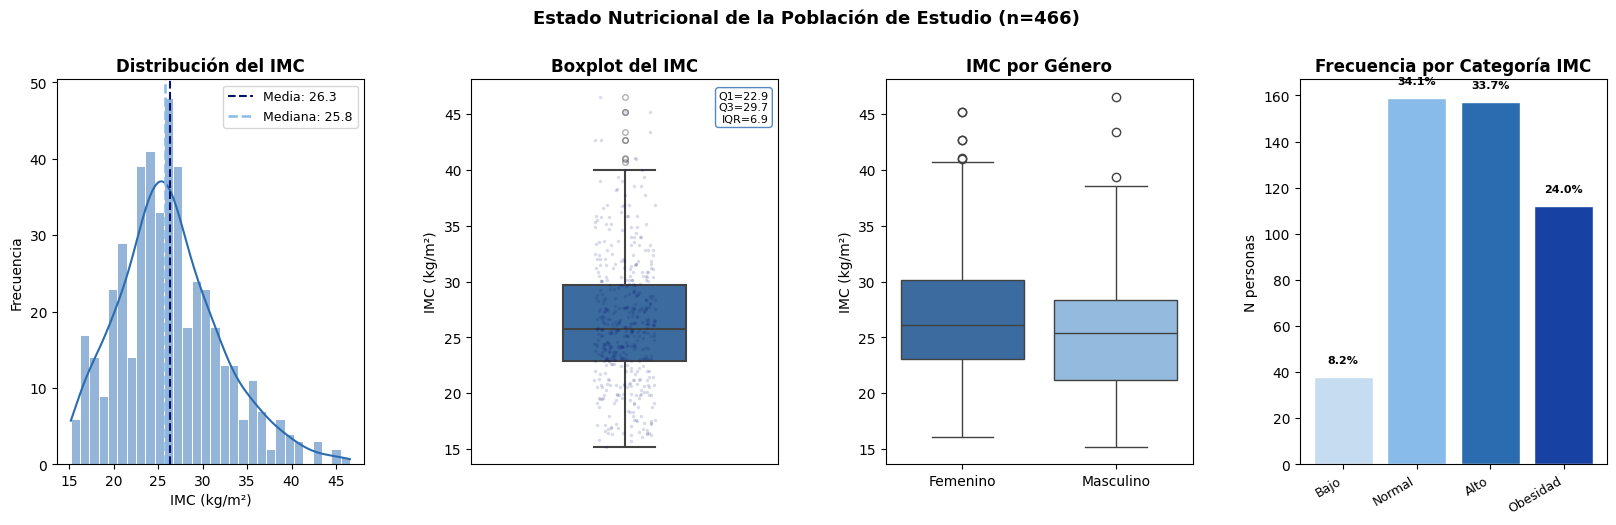

In [25]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

orden = ['Bajo', 'Normal', 'Alto', 'Obesidad']
orden_presente = [c for c in orden if c in df_tfg['Categoria_IMC'].unique()]

paleta = {
    'Bajo':     '#C6DCF0',
    'Normal':   '#88BBE9',
    'Alto':     '#2B6CB0',
    'Obesidad': "#1741A3"
}

fig = plt.figure(figsize=(20, 5))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
sns.histplot(df_tfg['IMC'], bins=30, kde=True, color='#2B6CB0', edgecolor='white', ax=ax1)
ax1.axvline(df_tfg['IMC'].mean(),   color='#07126F', linestyle='--', linewidth=1.5, label=f"Media: {df_tfg['IMC'].mean():.1f}")
ax1.axvline(df_tfg['IMC'].median(), color='#88BBE9', linestyle='--', linewidth=1.8, label=f"Mediana: {df_tfg['IMC'].median():.1f}")
ax1.set_title('Distribución del IMC', fontweight='bold')
ax1.set_xlabel('IMC (kg/m²)')
ax1.set_ylabel('Frecuencia')
ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[1])
sns.boxplot(y=df_tfg['IMC'], color='#2B6CB0', width=0.4, linewidth=1.5,
            flierprops=dict(marker='o', color='#07126F', alpha=0.4, markersize=4),
            ax=ax2)
sns.stripplot(y=df_tfg['IMC'], color='#07126F', alpha=0.15, size=2.5, jitter=True, ax=ax2)
ax2.set_title('Boxplot del IMC', fontweight='bold')
ax2.set_ylabel('IMC (kg/m²)')
ax2.set_xticks([])
q1, q3 = df_tfg['IMC'].quantile([0.25, 0.75])
ax2.text(0.97, 0.97, f'Q1={q1:.1f}\nQ3={q3:.1f}\nIQR={q3-q1:.1f}',
         transform=ax2.transAxes, fontsize=8, va='top', ha='right',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#2B6CB0', alpha=0.8))

ax3 = fig.add_subplot(gs[2])
sns.boxplot(data=df_tfg, x='Genero', y='IMC',
            palette={'Masculino': '#88BBE9', 'Femenino': '#2B6CB0'}, ax=ax3)
ax3.set_title('IMC por Género', fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('IMC (kg/m²)')

ax4 = fig.add_subplot(gs[3])
conteos = df_tfg['Categoria_IMC'].value_counts().reindex(orden_presente)
colores = [paleta.get(c, '#88BBE9') for c in conteos.index]
bars = ax4.bar(conteos.index, conteos.values, color=colores, edgecolor='white')
ax4.set_title('Frecuencia por Categoría IMC', fontweight='bold')
ax4.set_xlabel('')
ax4.set_ylabel('N personas')
ax4.set_xticklabels(conteos.index, rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars, conteos.values):
    pct = val / len(df_tfg) * 100
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Estado Nutricional de la Población de Estudio (n=466)',
             fontsize=13, fontweight='bold', y=1.02)
plt.show()

#### **Visualización IMC con respecto a otras variables** 

##### **IMC vs variables numéricas**

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

orden_presente = [c for c in ['Bajo', 'Normal', 'Alto', 'Obesidad']
                  if c in df_tfg['Categoria_IMC'].unique()]

paleta_cat = {
    'Bajo':     '#C6DCF0',
    'Normal':   '#88BBE9',
    'Alto':     '#2B6CB0',
    'Obesidad': '#07126F'
}
colores_cat = [paleta_cat[c] for c in orden_presente]
blues_hue   = ['#C6DCF0', '#07126F']  

C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\1908000226.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tfg, x='Categoria_IMC', y=var,
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\1908000226.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tfg, x='Categoria_IMC', y=var,
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\1908000226.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tfg, x='Categoria_IMC', y=var,


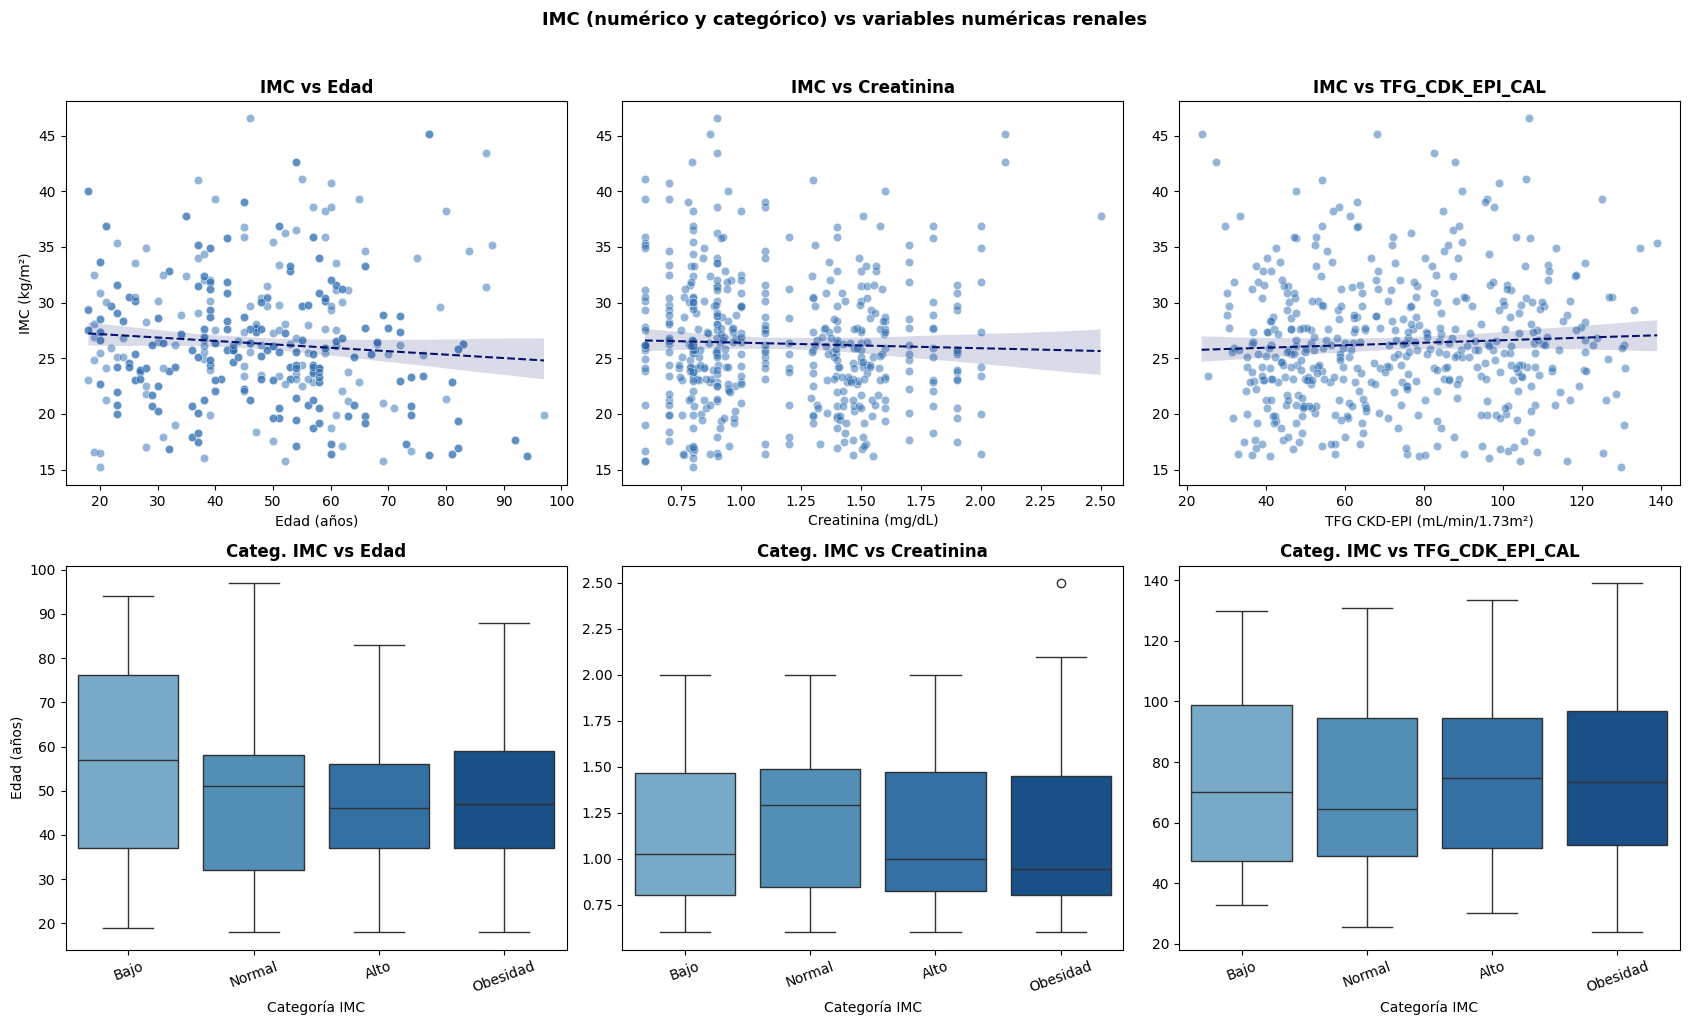

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

num_vars = [
    ('Edad',            'Edad (años)'),
    ('Creatinina',      'Creatinina (mg/dL)'),
    ('TFG_CDK_EPI_CAL', 'TFG CKD-EPI (mL/min/1.73m²)')
]

for j, (var, xlabel) in enumerate(num_vars):
    sns.scatterplot(data=df_tfg, x=var, y='IMC',
                    color='#2B6CB0', alpha=0.5, ax=axes[0, j])
    sns.regplot(data=df_tfg, x=var, y='IMC', scatter=False, color='#07126F',
                line_kws={'linestyle': '--', 'linewidth': 1.5}, ax=axes[0, j])
    axes[0, j].set_title(f'IMC vs {var}', fontweight='bold')
    axes[0, j].set_xlabel(xlabel)
    axes[0, j].set_ylabel('IMC (kg/m²)' if j == 0 else '')

for j, (var, ylabel) in enumerate(num_vars):
    pal = sns.color_palette("Blues", len(orden_presente) + 3)[3:]
    sns.boxplot(data=df_tfg, x='Categoria_IMC', y=var,
                order=orden_presente, palette=pal, ax=axes[1, j])
    axes[1, j].set_title(f'Categ. IMC vs {var}', fontweight='bold')
    axes[1, j].set_xlabel('Categoría IMC')
    axes[1, j].set_ylabel(ylabel if j == 0 else '')
    axes[1, j].tick_params(axis='x', rotation=20)

plt.suptitle('IMC (numérico y categórico) vs variables numéricas renales',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### **IMC vs variables categóricas**

C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2219992732.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tfg, x=var, y='IMC',
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2219992732.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tfg, x=var, y='IMC',
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2219992732.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tfg, x=var, y='IMC',
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2219992732.py:14: FutureWarning: 

Passing `palette` without assigning `hue`

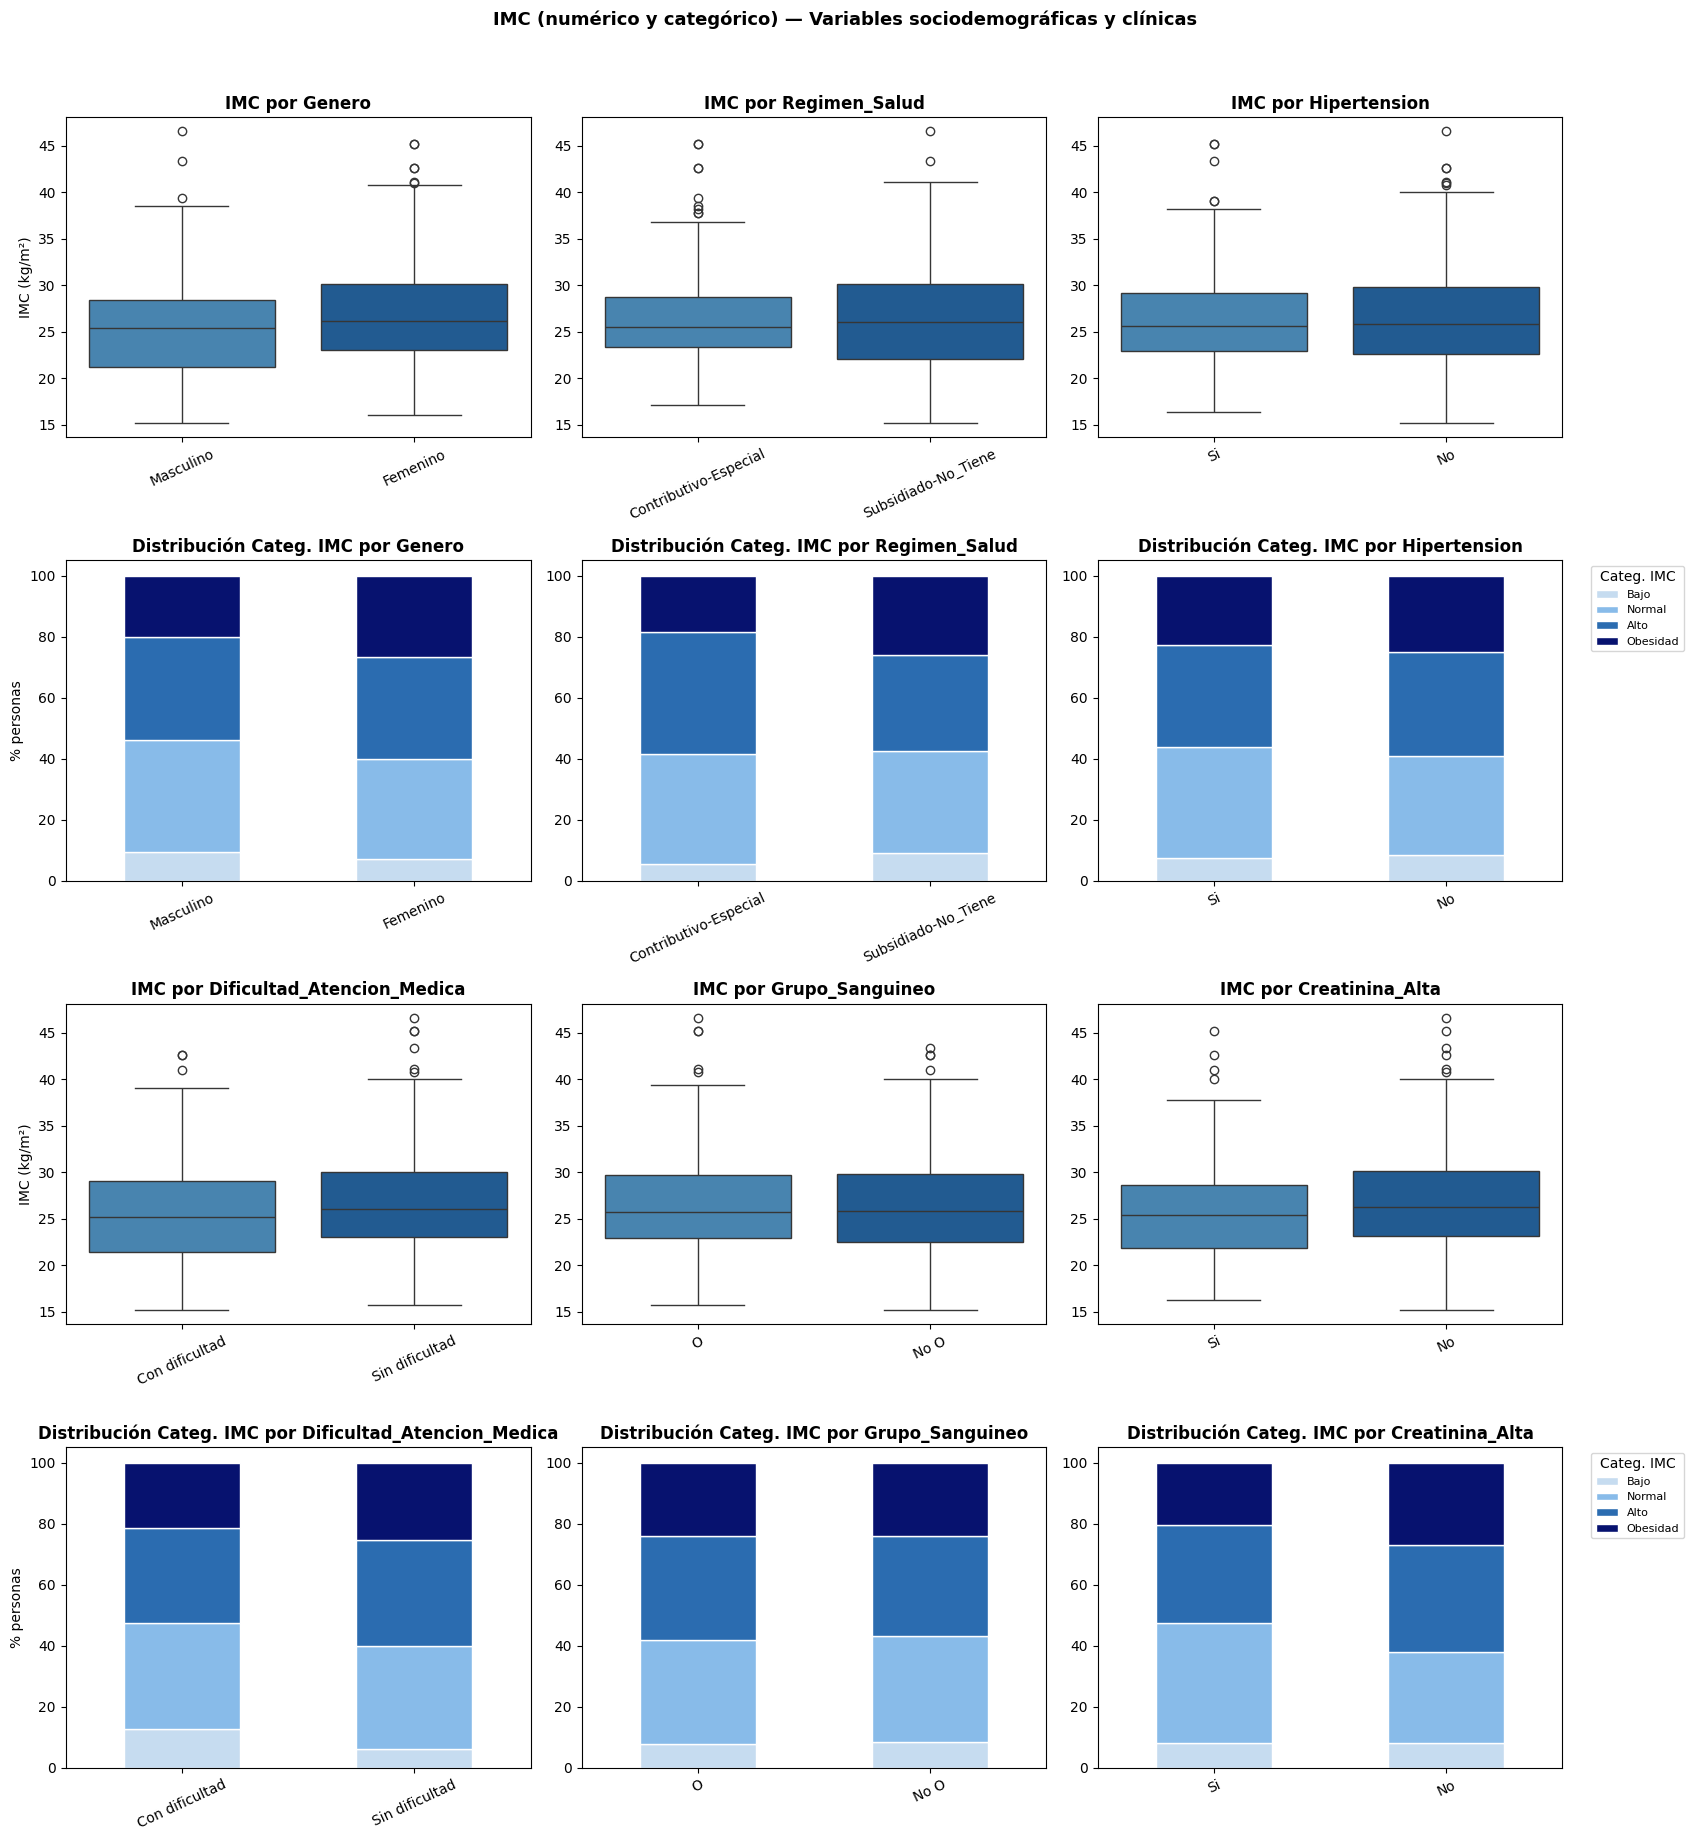

In [28]:
cat_g1 = ['Genero', 'Regimen_Salud', 'Hipertension',
          'Dificultad_Atencion_Medica', 'Grupo_Sanguineo', 'Creatinina_Alta']

fig, axes = plt.subplots(4, 3, figsize=(17, 18))

for j, var in enumerate(cat_g1):
    col     = j % 3         
    fila_box = (j // 3) * 2  
    fila_bar = fila_box + 1  

    orden_var = df_tfg.groupby(var)['IMC'].median().sort_values().index.tolist()
    pal = sns.color_palette("Blues", len(orden_var) + 3)[3:]

    sns.boxplot(data=df_tfg, x=var, y='IMC',
                order=orden_var, palette=pal, ax=axes[fila_box, col])
    axes[fila_box, col].set_title(f'IMC por {var}', fontweight='bold')
    axes[fila_box, col].set_xlabel('')
    axes[fila_box, col].set_ylabel('IMC (kg/m²)' if col == 0 else '')
    axes[fila_box, col].tick_params(axis='x', rotation=25)

    ct = pd.crosstab(df_tfg[var], df_tfg['Categoria_IMC'], normalize='index') * 100
    ct = ct.reindex(columns=orden_presente)
    ct.reindex(orden_var).plot(kind='bar', stacked=True, color=colores_cat,
                                edgecolor='white', ax=axes[fila_bar, col],
                                legend=(col == 2))
    axes[fila_bar, col].set_title(f'Distribución Categ. IMC por {var}', fontweight='bold')
    axes[fila_bar, col].set_xlabel('')
    axes[fila_bar, col].set_ylabel('% personas' if col == 0 else '')
    axes[fila_bar, col].tick_params(axis='x', rotation=25)
    if col == 2:
        axes[fila_bar, col].legend(title='Categ. IMC',
                                   bbox_to_anchor=(1.05, 1), fontsize=8)

plt.suptitle('IMC (numérico y categórico) — Variables sociodemográficas y clínicas',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### **IMC por departamneto/municipio**

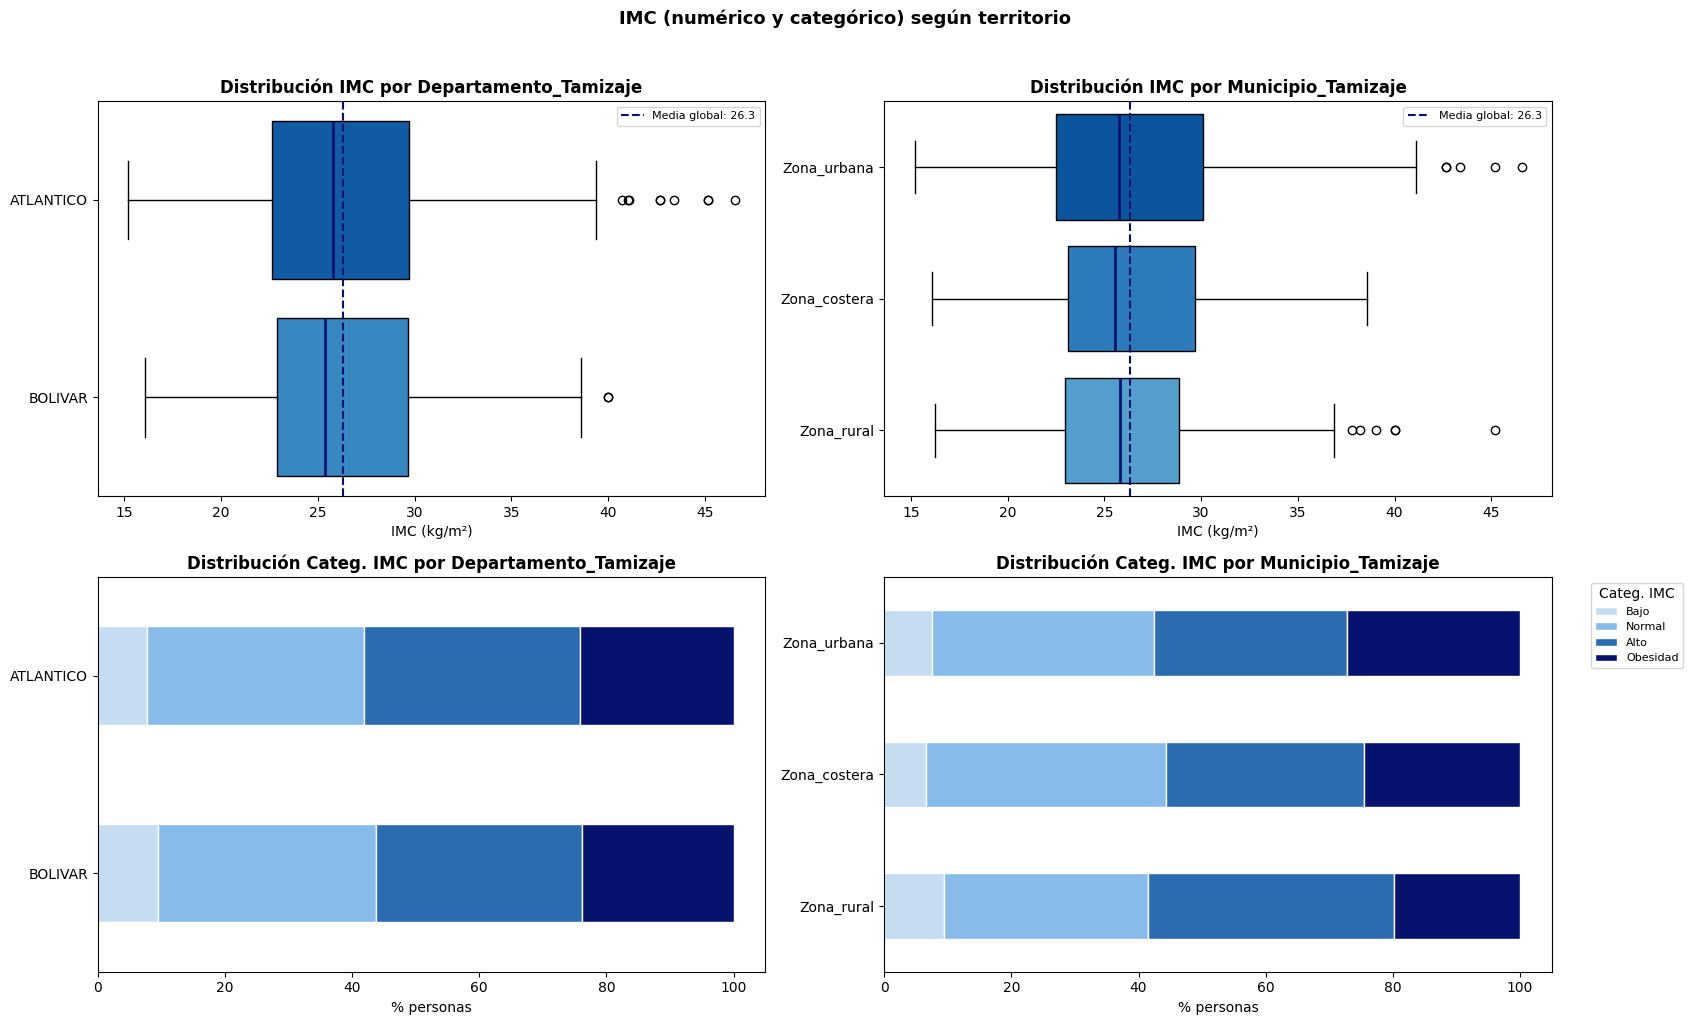

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(17, 10))

top_mun = df_tfg['Municipio_Tamizaje'].value_counts().head(10).index

for j, (geo_var, subset) in enumerate([
        ('Departamento_Tamizaje', df_tfg),
        ('Municipio_Tamizaje',    df_tfg[df_tfg['Municipio_Tamizaje'].isin(top_mun)])]):

    orden_geo = subset.groupby(geo_var)['IMC'].mean().sort_values().index.tolist()
    pal = sns.color_palette("Blues", len(orden_geo) + 3)[3:]

    # Fila 1: Boxplot de IMC (horizontal)
    data_box = [subset[subset[geo_var] == cat]['IMC'].dropna().values for cat in orden_geo]
    bp = axes[0, j].boxplot(data_box, vert=False, patch_artist=True, widths=0.8,
                             medianprops=dict(color='#07126F', linewidth=2))
    for patch, color in zip(bp['boxes'], pal):
        patch.set_facecolor(color)
    axes[0, j].set_yticks(range(1, len(orden_geo) + 1))
    axes[0, j].set_yticklabels(orden_geo)
    axes[0, j].axvline(df_tfg['IMC'].mean(), color='#07126F', linestyle='--',
                       linewidth=1.5, label=f'Media global: {df_tfg["IMC"].mean():.1f}')
    axes[0, j].set_title(f'Distribución IMC por {geo_var}', fontweight='bold')
    axes[0, j].set_xlabel('IMC (kg/m²)')
    axes[0, j].legend(fontsize=8)

    # Fila 2: distribución Categoria_IMC (%)
    ct = pd.crosstab(subset[geo_var], subset['Categoria_IMC'], normalize='index') * 100
    ct = ct.reindex(columns=orden_presente)
    ct.reindex(orden_geo).plot(kind='barh', stacked=True, color=colores_cat,
                                edgecolor='white', ax=axes[1, j], legend=(j == 1))
    axes[1, j].set_title(f'Distribución Categ. IMC por {geo_var}', fontweight='bold')
    axes[1, j].set_xlabel('% personas')
    axes[1, j].set_ylabel('')
    if j == 1:
        axes[1, j].legend(title='Categ. IMC', bbox_to_anchor=(1.05, 1), fontsize=8)

plt.suptitle('IMC (numérico y categórico) según territorio',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### **IMC vs función renal**

C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2471367956.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df_tfg, x='TFG_CDK_EPI_CAL', y='IMC', palette=blues_hue,
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2471367956.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend(title='ERC Binaria', fontsize=8)
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2471367956.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tfg, x='Estadio_ERC_CAL', y='IMC',
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2471367956.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

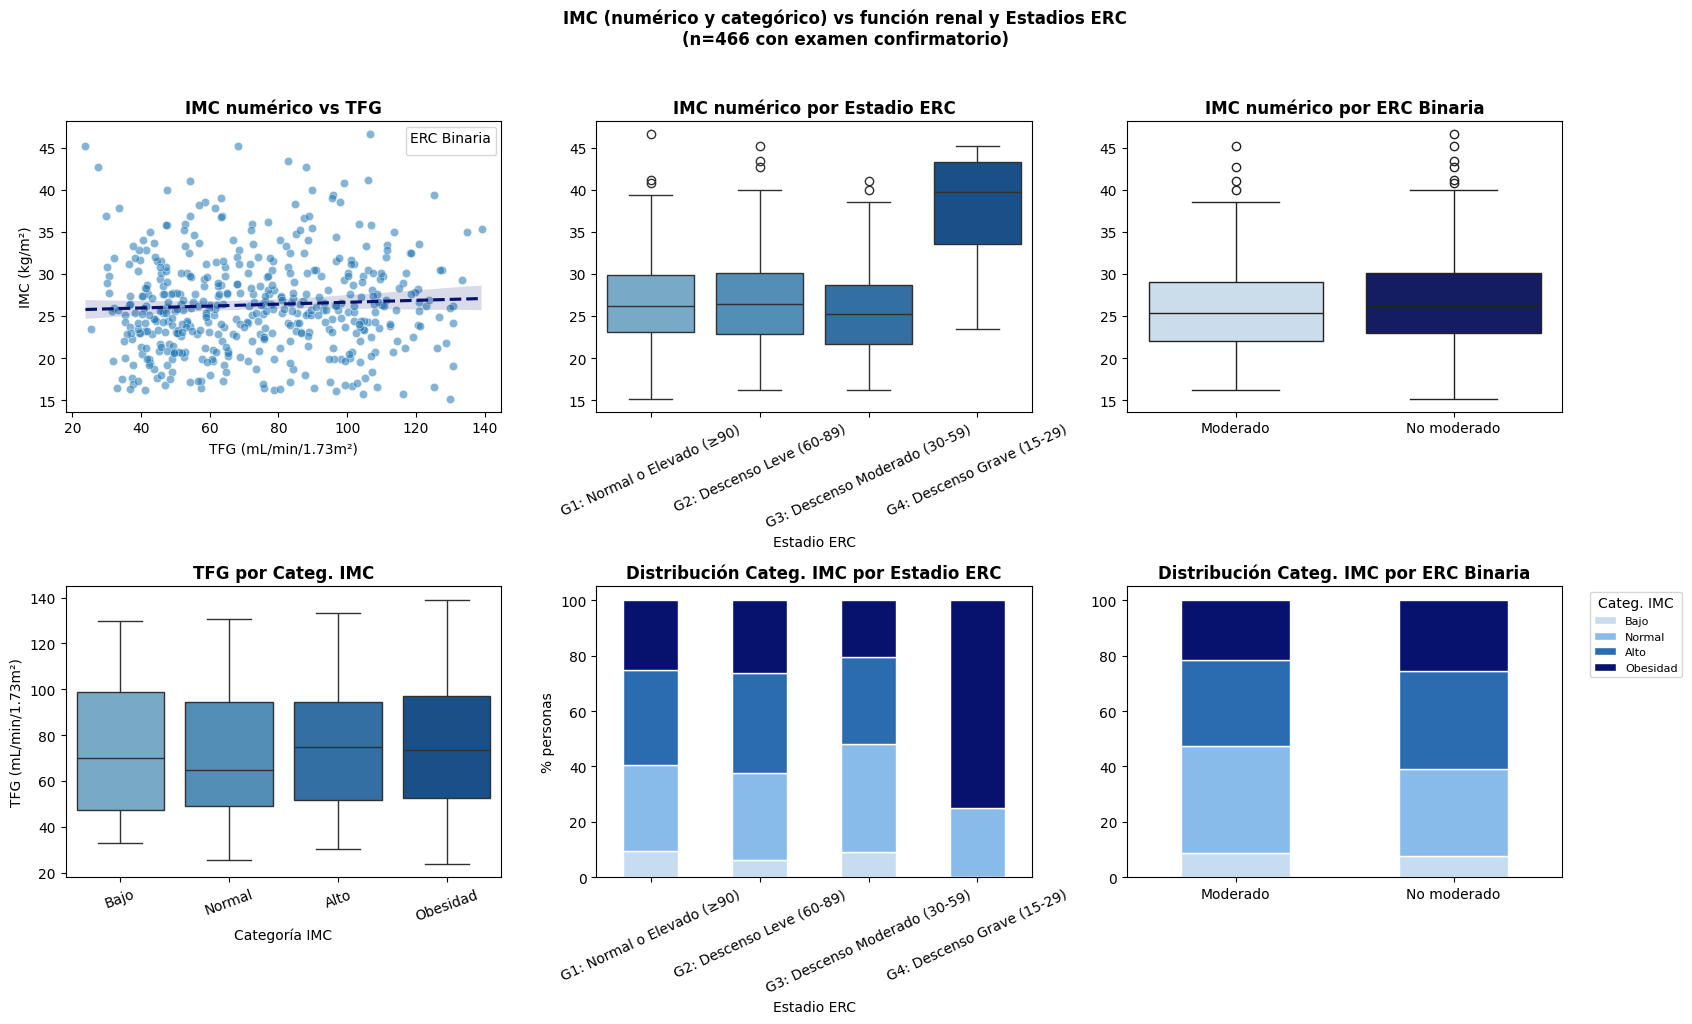

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

orden_estadio = sorted(df_tfg['Estadio_ERC_CAL'].dropna().unique())
orden_bin     = sorted(df_tfg['Estadio_ERC_Binaria'].dropna().unique())
pal_estadio   = sns.color_palette("Blues", len(orden_estadio) + 3)[3:]

sns.scatterplot(data=df_tfg, x='TFG_CDK_EPI_CAL', y='IMC', palette=blues_hue,
                alpha=0.55, ax=axes[0, 0])
sns.regplot(data=df_tfg, x='TFG_CDK_EPI_CAL', y='IMC', scatter=False,
            color='#07126F', line_kws={'linestyle': '--'}, ax=axes[0, 0])
axes[0, 0].set_title('IMC numérico vs TFG', fontweight='bold')
axes[0, 0].set_xlabel('TFG (mL/min/1.73m²)')
axes[0, 0].set_ylabel('IMC (kg/m²)')
axes[0, 0].legend(title='ERC Binaria', fontsize=8)

sns.boxplot(data=df_tfg, x='Estadio_ERC_CAL', y='IMC',
            order=orden_estadio, palette=pal_estadio, ax=axes[0, 1])
axes[0, 1].set_title('IMC numérico por Estadio ERC', fontweight='bold')
axes[0, 1].set_xlabel('Estadio ERC')
axes[0, 1].set_ylabel('')
axes[0, 1].tick_params(axis='x', rotation=25)

sns.boxplot(data=df_tfg, x='Estadio_ERC_Binaria', y='IMC',
            order=orden_bin, palette=blues_hue, ax=axes[0, 2])
axes[0, 2].set_title('IMC numérico por ERC Binaria', fontweight='bold')
axes[0, 2].set_xlabel('')
axes[0, 2].set_ylabel('')

pal_n = sns.color_palette("Blues", len(orden_presente) + 3)[3:]
sns.boxplot(data=df_tfg, x='Categoria_IMC', y='TFG_CDK_EPI_CAL',
            order=orden_presente, palette=pal_n, ax=axes[1, 0])
axes[1, 0].set_title('TFG por Categ. IMC', fontweight='bold')
axes[1, 0].set_xlabel('Categoría IMC')
axes[1, 0].set_ylabel('TFG (mL/min/1.73m²)')
axes[1, 0].tick_params(axis='x', rotation=20)

ct_est = pd.crosstab(df_tfg['Estadio_ERC_CAL'], df_tfg['Categoria_IMC'], normalize='index') * 100
ct_est = ct_est.reindex(columns=orden_presente)
ct_est.reindex(orden_estadio).plot(kind='bar', stacked=True, color=colores_cat,
                                    edgecolor='white', ax=axes[1, 1], legend=False)
axes[1, 1].set_title('Distribución Categ. IMC por Estadio ERC', fontweight='bold')
axes[1, 1].set_xlabel('Estadio ERC')
axes[1, 1].set_ylabel('% personas')
axes[1, 1].tick_params(axis='x', rotation=25)

ct_bin = pd.crosstab(df_tfg['Estadio_ERC_Binaria'], df_tfg['Categoria_IMC'], normalize='index') * 100
ct_bin = ct_bin.reindex(columns=orden_presente)
ct_bin.reindex(orden_bin).plot(kind='bar', stacked=True, color=colores_cat,
                                edgecolor='white', ax=axes[1, 2], legend=True)
axes[1, 2].set_title('Distribución Categ. IMC por ERC Binaria', fontweight='bold')
axes[1, 2].set_xlabel('')
axes[1, 2].set_ylabel('')
axes[1, 2].tick_params(axis='x', rotation=0)
axes[1, 2].legend(title='Categ. IMC', bbox_to_anchor=(1.05, 1), fontsize=8)

plt.suptitle('IMC (numérico y categórico) vs función renal y Estadios ERC\n(n=466 con examen confirmatorio)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **Correlación entre variables**

### **Relación IMC cuantitativa**

In [31]:
vars_numericas = [
    'Edad',
    'Creatinina',
    'TFG_CDK_EPI_CAL',
    'Presion_Sistolica',
    'Presion_Diastolica'
]

vars_categoricas = [
    'Departamento_Tamizaje',
    'Municipio_Tamizaje',
    'Genero',
    'Regimen_Salud',
    'Medicacion_Diabetes',
    'Hipertension',
    'Medicacion_Hipertension',
    'Colesterol_Alto',
    'Medicacion_Colesterol',
    'Insuficiencia_Renal',
    'Dialisis',
    'Proteina_Sangre_Orina',
    'Consumo_Tabaco',
    'Consumo_Alcohol',
    'Consumo_Drogas',
    'Trabajo_Cultivo',
    'Uso_Insecticidas',
    'Uso_Fungicidas',
    'Uso_Fertilizantes',
    'Ultima_Consulta_Medica',
    'Dificultad_Atencion_Medica',
    'Ultimo_Profesional_Salud',
    'Medico_Cabecera',
    'Grupo_Sanguineo',
    'Uso_AINES',
    'Tirilla_Reactiva',
    'Creatinina_Alta',
    'Estadio_ERC_CAL',
    'Estadio_ERC_Binaria'
]

#### **IMC (cuantitativo) vs variables numéricas**

In [32]:
from scipy import stats
import pandas as pd

resultados_supuestos = []

for var in vars_numericas:
    datos_par = df_tfg[['IMC', var]].dropna()
    n = len(datos_par)

    # Normalidad de IMC (Shapiro-Wilk)
    stat_imc, p_imc = stats.shapiro(datos_par['IMC'])

    # Normalidad de la variable (Shapiro-Wilk)
    stat_var, p_var = stats.shapiro(datos_par[var])

    # Ambas deben ser normales (p > 0.05) para que Pearson sea válido
    normal_imc = p_imc > 0.05
    normal_var = p_var > 0.05
    cumple_normalidad = normal_imc and normal_var

    resultados_supuestos.append({
        'Variable':              var,
        'N':                     n,
        'p Shapiro (IMC)':       p_imc,   # sin round, se conserva el valor real
        'Normal IMC':            '✓' if normal_imc else '✗',
        'p Shapiro (Var)':       p_var,   # sin round, se conserva el valor real
        'Normal Var':            '✓' if normal_var else '✗',
        'Cumple supuestos':      '✓ Pearson' if cumple_normalidad else '✗ Usar Spearman',
    })

tabla_supuestos = pd.DataFrame(resultados_supuestos).set_index('Variable')


display(tabla_supuestos.style
        .format({'p Shapiro (IMC)': '{:.4e}', 'p Shapiro (Var)': '{:.4e}'})
        .set_caption('Tabla 1 — Verificación de supuestos de normalidad (Shapiro-Wilk, α=0.05)'))

,N,p Shapiro (IMC),Normal IMC,p Shapiro (Var),Normal Var,Cumple supuestos
Variable,,,,,,
Edad,466,3.8698e-07,✗,3.4963e-06,✗,✗ Usar Spearman
Creatinina,466,3.8698e-07,✗,1.3785e-13,✗,✗ Usar Spearman
TFG_CDK_EPI_CAL,466,3.8698e-07,✗,9.7865e-10,✗,✗ Usar Spearman
Presion_Sistolica,454,6.5081e-07,✗,1.7862e-17,✗,✗ Usar Spearman
Presion_Diastolica,454,6.5081e-07,✗,6.7586e-41,✗,✗ Usar Spearman


In [33]:
resultados_corr = []

for var in vars_numericas:
    datos_par = df_tfg[['IMC', var]].dropna()
    n = len(datos_par)

    fila_supuestos = tabla_supuestos.loc[var]
    cumple_normalidad = fila_supuestos['Cumple supuestos'] == '✓ Pearson'

    if cumple_normalidad:
        r, p = stats.pearsonr(datos_par['IMC'], datos_par[var])
        metodo = 'Pearson'
    else:
        r, p = stats.spearmanr(datos_par['IMC'], datos_par[var])
        metodo = 'Spearman'

    resultados_corr.append({
        'Variable':       var,
        'N':              n,
        'Método usado':   metodo,
        'Coeficiente':    round(r, 3),
        'p-valor':        round(p, 4),
        'Significativo':  '✓' if p < 0.05 else '✗',
    })

tabla_corr = pd.DataFrame(resultados_corr).set_index('Variable')

display(tabla_corr.style
        .format({'p-valor': '{:.4f}', 'Coeficiente': '{:.3f}'})
        .set_caption('Tabla 2 — Correlación IMC vs Variables Numéricas'))

,N,Método usado,Coeficiente,p-valor,Significativo
Variable,,,,,
Edad,466,Spearman,-0.108,0.0197,✓
Creatinina,466,Spearman,-0.053,0.2520,✗
TFG_CDK_EPI_CAL,466,Spearman,0.071,0.1278,✗
Presion_Sistolica,454,Spearman,-0.082,0.0800,✗
Presion_Diastolica,454,Spearman,-0.045,0.3372,✗


In [34]:
IMC_NUM_VAR_NUM_SIG = tabla_corr[tabla_corr['Significativo'] == '✓'].index.tolist()

print(IMC_NUM_VAR_NUM_SIG)

['Edad']


#### **IMC (cuantitativo) vs variables categóricas**

In [35]:
from scipy import stats
import pandas as pd

resultados_supuestos_cat = []

for var in vars_categoricas:
    datos_par = df_tfg[['IMC', var]].dropna()
    grupos_nombres = datos_par[var].unique()
    n_grupos = len(grupos_nombres)
    n_total = len(datos_par)

    grupos_datos = [datos_par.loc[datos_par[var] == g, 'IMC'] for g in grupos_nombres]

    # Normalidad por grupo (Shapiro-Wilk)
    p_normalidad = []
    for g_datos in grupos_datos:
        if len(g_datos) >= 3:  # Shapiro requiere al menos 3 datos
            _, p_g = stats.shapiro(g_datos)
        else:
            p_g = None
        p_normalidad.append(p_g)

    normalidad_ok = all((p is not None and p > 0.05) for p in p_normalidad)
    p_normalidad_min = min([p for p in p_normalidad if p is not None], default=None)

    # Homogeneidad de varianzas (Levene)
    stat_levene, p_levene = stats.levene(*grupos_datos)
    homocedasticidad_ok = p_levene > 0.05

    cumple_supuestos = normalidad_ok and homocedasticidad_ok

    if n_grupos == 2:
        prueba_recomendada = 'T-test' if cumple_supuestos else 'Mann-Whitney U'
    else:
        prueba_recomendada = 'ANOVA' if cumple_supuestos else 'Kruskal-Wallis'

    resultados_supuestos_cat.append({
        'Variable':              var,
        'N grupos':              n_grupos,
        'N total':               n_total,
        'p Shapiro (mín. grupo)':p_normalidad_min,
        'Normalidad':            '✓' if normalidad_ok else '✗',
        'p Levene':              p_levene,
        'Homocedasticidad':      '✓' if homocedasticidad_ok else '✗',
        'Prueba a usar':         prueba_recomendada,
    })

tabla_supuestos_cat = pd.DataFrame(resultados_supuestos_cat).set_index('Variable')

display(tabla_supuestos_cat.style
        .format({'p Shapiro (mín. grupo)': '{:.4e}', 'p Levene': '{:.4e}'})
        .set_caption('Tabla 1 — Verificación de supuestos: Normalidad (Shapiro-Wilk) y Homocedasticidad (Levene), α=0.05'))

,N grupos,N total,p Shapiro (mín. grupo),Normalidad,p Levene,Homocedasticidad,Prueba a usar
Variable,,,,,,,
Departamento_Tamizaje,2,466,2.2963e-06,✗,6.4965e-01,✓,Mann-Whitney U
Municipio_Tamizaje,3,466,6.0359e-05,✗,1.3682e-01,✓,Kruskal-Wallis
Genero,2,466,5.8353e-05,✗,9.1353e-01,✓,Mann-Whitney U
Regimen_Salud,2,466,6.0603e-07,✗,9.1178e-02,✓,Mann-Whitney U
Medicacion_Diabetes,2,466,6.5679e-06,✗,2.7498e-01,✓,Mann-Whitney U
Hipertension,2,466,9.3849e-05,✗,4.0936e-01,✓,Mann-Whitney U
Medicacion_Hipertension,2,466,8.2596e-05,✗,6.2233e-01,✓,Mann-Whitney U
Colesterol_Alto,2,466,3.6129e-05,✗,3.4021e-01,✓,Mann-Whitney U
Medicacion_Colesterol,2,466,4.4542e-06,✗,7.6677e-01,✓,Mann-Whitney U


In [36]:
import numpy as np

def welch_anova(grupos):
    k = len(grupos)
    n_i = np.array([len(g) for g in grupos])
    media_i = np.array([g.mean() for g in grupos])
    var_i = np.array([g.var(ddof=1) for g in grupos])

    w_i = n_i / var_i
    suma_w = w_i.sum()
    media_ponderada = (w_i * media_i).sum() / suma_w

    numerador = (w_i * (media_i - media_ponderada) ** 2).sum() / (k - 1)
    denom_term = ((1 - w_i / suma_w) ** 2 / (n_i - 1)).sum()
    denominador = 1 + (2 * (k - 2) / (k ** 2 - 1)) * denom_term

    f_stat = numerador / denominador

    df1 = k - 1
    df2 = (k ** 2 - 1) / (3 * denom_term)

    p_valor = stats.f.sf(f_stat, df1, df2)
    return f_stat, p_valor


resultados_cat = []

for var in vars_categoricas:
    datos_par = df_tfg[['IMC', var]].dropna()
    grupos_nombres = datos_par[var].unique()
    n_grupos = len(grupos_nombres)
    n_total = len(datos_par)

    grupos_datos = [datos_par.loc[datos_par[var] == g, 'IMC'] for g in grupos_nombres]

    prueba_a_usar = tabla_supuestos_cat.loc[var, 'Prueba a usar']

    if prueba_a_usar == 'T-test clásico':
        stat, p = stats.ttest_ind(*grupos_datos, equal_var=True)
    elif prueba_a_usar == 'T-test Welch':
        stat, p = stats.ttest_ind(*grupos_datos, equal_var=False)
    elif prueba_a_usar == 'Mann-Whitney U':
        stat, p = stats.mannwhitneyu(*grupos_datos)
    elif prueba_a_usar == 'ANOVA clásico':
        stat, p = stats.f_oneway(*grupos_datos)
    elif prueba_a_usar == 'Welch ANOVA':
        stat, p = welch_anova(grupos_datos)
    else:  # Kruskal-Wallis
        stat, p = stats.kruskal(*grupos_datos)

    resultados_cat.append({
        'Variable':       var,
        'N grupos':       n_grupos,
        'N total':        n_total,
        'Prueba usada':   prueba_a_usar,
        'Estadístico':    stat,
        'p-valor':        p,
        'Significativo':  '✓' if p < 0.05 else '✗',
    })

tabla_resultados_cat = pd.DataFrame(resultados_cat).set_index('Variable')

display(tabla_resultados_cat.style
        .format({'Estadístico': '{:.4f}', 'p-valor': '{:.4e}'})
        .set_caption('Tabla 2 — Resultado de la prueba (T-test/Welch/ANOVA/Mann-Whitney/Kruskal-Wallis según supuestos)'))

,N grupos,N total,Prueba usada,Estadístico,p-valor,Significativo
Variable,,,,,,
Departamento_Tamizaje,2,466,Mann-Whitney U,18707.0000,8.4013e-01,✗
Municipio_Tamizaje,3,466,Kruskal-Wallis,0.5793,7.4853e-01,✗
Genero,2,466,Mann-Whitney U,28557.5000,4.6565e-02,✓
Regimen_Salud,2,466,Mann-Whitney U,21235.0000,9.5233e-01,✗
Medicacion_Diabetes,2,466,Mann-Whitney U,7877.0000,3.2628e-01,✗
Hipertension,2,466,Mann-Whitney U,25540.5000,4.9043e-01,✗
Medicacion_Hipertension,2,466,Mann-Whitney U,25457.5000,5.7364e-01,✗
Colesterol_Alto,2,466,Mann-Whitney U,15004.5000,7.9635e-01,✗
Medicacion_Colesterol,2,466,Mann-Whitney U,9648.0000,5.2414e-01,✗


In [37]:
IMC_NUM_VAR_CAT_SIG = tabla_resultados_cat[tabla_resultados_cat['Significativo'] == '✓'].index.tolist()

print(IMC_NUM_VAR_CAT_SIG)

['Genero', 'Consumo_Tabaco', 'Medico_Cabecera', 'Tirilla_Reactiva', 'Creatinina_Alta', 'Estadio_ERC_CAL']


### **Relación IMC categórico**

In [38]:
vars_cat_nom = [
    'Departamento_Tamizaje',
    'Municipio_Tamizaje',
    'Genero',
    'Regimen_Salud',
    'Medicacion_Diabetes',
    'Hipertension',
    'Medicacion_Hipertension',
    'Colesterol_Alto',
    'Medicacion_Colesterol',
    'Insuficiencia_Renal',
    'Dialisis',
    'Proteina_Sangre_Orina',
    'Consumo_Tabaco',
    'Consumo_Alcohol',
    'Consumo_Drogas',
    'Trabajo_Cultivo',
    'Uso_Insecticidas',
    'Uso_Fungicidas',
    'Uso_Fertilizantes',
    'Ultima_Consulta_Medica',
    'Dificultad_Atencion_Medica',
    'Ultimo_Profesional_Salud',
    'Medico_Cabecera',
    'Grupo_Sanguineo',
    'Uso_AINES',
    'Tirilla_Reactiva',
    'Creatinina_Alta',
]

vars_cat_ord = [
    'Estadio_ERC_CAL',
    'Estadio_ERC_Binaria'
]

#### **IMC (cualitativo) vs variables numéricas**

In [39]:
from scipy import stats
import pandas as pd

resultados_supuestos = []

for var in vars_numericas:
    datos_par = df_tfg[['Categoria_IMC', var]].dropna()
    grupos_nombres = datos_par['Categoria_IMC'].unique()
    n_grupos = len(grupos_nombres)
    n_total = len(datos_par)

    grupos_datos = [datos_par.loc[datos_par['Categoria_IMC'] == g, var] for g in grupos_nombres]

    # Normalidad por grupo (Shapiro-Wilk)
    p_normalidad = []
    for g_datos in grupos_datos:
        if len(g_datos) >= 3:  # Shapiro requiere al menos 3 datos
            _, p_g = stats.shapiro(g_datos)
        else:
            p_g = None
        p_normalidad.append(p_g)

    normalidad_ok = all((p is not None and p > 0.05) for p in p_normalidad)
    p_normalidad_min = min([p for p in p_normalidad if p is not None], default=None)

    # Homogeneidad de varianzas (Levene)
    stat_levene, p_levene = stats.levene(*grupos_datos)
    homocedasticidad_ok = p_levene > 0.05

    # Decisión de prueba (4 grupos -> rama de 3+ grupos)
    if normalidad_ok and homocedasticidad_ok:
        prueba_recomendada = 'ANOVA clásico'
    elif normalidad_ok and not homocedasticidad_ok:
        prueba_recomendada = 'Welch ANOVA'
    else:
        prueba_recomendada = 'Kruskal-Wallis'

    resultados_supuestos.append({
        'Variable':               var,
        'N grupos':               n_grupos,
        'N total':                n_total,
        'p Shapiro (mín. grupo)': p_normalidad_min,
        'Normalidad':             '✓' if normalidad_ok else '✗',
        'p Levene':               p_levene,
        'Homocedasticidad':       '✓' if homocedasticidad_ok else '✗',
        'Prueba a usar':          prueba_recomendada,
    })

tabla_supuestos = pd.DataFrame(resultados_supuestos).set_index('Variable')

display(tabla_supuestos.style
        .format({'p Shapiro (mín. grupo)': '{:.4e}', 'p Levene': '{:.4e}'})
        .set_caption('Tabla 1 — Verificación de supuestos: Normalidad (Shapiro-Wilk) y Homocedasticidad (Levene) por Categoria_IMC, α=0.05'))

,N grupos,N total,p Shapiro (mín. grupo),Normalidad,p Levene,Homocedasticidad,Prueba a usar
Variable,,,,,,,
Edad,4,466,4.5258e-04,✗,2.3097e-03,✗,Kruskal-Wallis
Creatinina,4,466,3.7873e-07,✗,8.8345e-01,✓,Kruskal-Wallis
TFG_CDK_EPI_CAL,4,466,2.3130e-06,✗,6.2132e-01,✓,Kruskal-Wallis
Presion_Sistolica,4,454,2.7721e-10,✗,2.3294e-01,✓,Kruskal-Wallis
Presion_Diastolica,4,454,5.2762e-26,✗,3.0357e-01,✓,Kruskal-Wallis


In [40]:
import numpy as np

def welch_anova(grupos):
    k = len(grupos)
    n_i = np.array([len(g) for g in grupos])
    media_i = np.array([g.mean() for g in grupos])
    var_i = np.array([g.var(ddof=1) for g in grupos])

    w_i = n_i / var_i
    suma_w = w_i.sum()
    media_ponderada = (w_i * media_i).sum() / suma_w

    numerador = (w_i * (media_i - media_ponderada) ** 2).sum() / (k - 1)
    denom_term = ((1 - w_i / suma_w) ** 2 / (n_i - 1)).sum()
    denominador = 1 + (2 * (k - 2) / (k ** 2 - 1)) * denom_term

    f_stat = numerador / denominador

    df1 = k - 1
    df2 = (k ** 2 - 1) / (3 * denom_term)

    p_valor = stats.f.sf(f_stat, df1, df2)
    return f_stat, p_valor


resultados_corr = []

for var in vars_numericas:
    datos_par = df_tfg[['Categoria_IMC', var]].dropna()
    grupos_nombres = datos_par['Categoria_IMC'].unique()
    n_grupos = len(grupos_nombres)
    n_total = len(datos_par)

    grupos_datos = [datos_par.loc[datos_par['Categoria_IMC'] == g, var] for g in grupos_nombres]

    prueba_a_usar = tabla_supuestos.loc[var, 'Prueba a usar']

    if prueba_a_usar == 'ANOVA clásico':
        stat, p = stats.f_oneway(*grupos_datos)
    elif prueba_a_usar == 'Welch ANOVA':
        stat, p = welch_anova(grupos_datos)
    else:  # Kruskal-Wallis
        stat, p = stats.kruskal(*grupos_datos)

    resultados_corr.append({
        'Variable':       var,
        'N grupos':       n_grupos,
        'N total':        n_total,
        'Prueba usada':   prueba_a_usar,
        'Estadístico':    stat,
        'p-valor':        p,
        'Significativo':  '✓' if p < 0.05 else '✗',
    })

tabla_corr = pd.DataFrame(resultados_corr).set_index('Variable')

display(tabla_corr.style
        .format({'Estadístico': '{:.4f}', 'p-valor': '{:.4e}'})
        .set_caption('Tabla 2 — Resultado de la prueba: Categoria_IMC vs Variables Numéricas (ANOVA/Welch/Kruskal-Wallis según supuestos)'))

,N grupos,N total,Prueba usada,Estadístico,p-valor,Significativo
Variable,,,,,,
Edad,4,466,Kruskal-Wallis,6.3130,9.7335e-02,✗
Creatinina,4,466,Kruskal-Wallis,3.6946,2.9639e-01,✗
TFG_CDK_EPI_CAL,4,466,Kruskal-Wallis,2.7993,4.2361e-01,✗
Presion_Sistolica,4,454,Kruskal-Wallis,6.7583,8.0014e-02,✗
Presion_Diastolica,4,454,Kruskal-Wallis,9.3051,2.5497e-02,✓


In [41]:
IMC_CAT_VAR_NUM_SIG = tabla_corr[tabla_corr['Significativo'] == '✓'].index.tolist()

print(IMC_CAT_VAR_NUM_SIG)

['Presion_Diastolica']


#### **IMC (cualitativo) vs variables categóricas**

In [42]:
resultados_chi = []

for var in vars_cat_nom:
    print(f"\n{'═'*60}")
    print(f"  Categoria_IMC  ×  {var}")
    print(f"{'═'*60}")
    
    # Frecuencias absolutas
    ct = pd.crosstab(df_tfg['Categoria_IMC'], df_tfg[var],
                     margins=True, margins_name='Total')
    print("\nFrecuencias absolutas:")
    print(ct.to_string())
    
    # Frecuencias relativas por fila (% dentro de cada categoría IMC)
    ct_pct = pd.crosstab(df_tfg['Categoria_IMC'], df_tfg[var],
                          normalize='index').round(3) * 100
    print("\n% por fila (dentro de cada Categ. IMC):")
    print(ct_pct.to_string())
    
    # Chi-cuadrado
    ct_chi = pd.crosstab(df_tfg['Categoria_IMC'], df_tfg[var])
    chi2, p, dof, expected = stats.chi2_contingency(ct_chi)
    sig = '✓ Significativo' if p < 0.05 else '✗ No significativo'
    print(f"\nChi² = {chi2:.4f}  |  gl = {dof}  |  p = {p:.4f}  →  {sig}")

    resultados_chi.append({
        'Variable':       var,
        'Chi2':           chi2,
        'gl':             dof,
        'p-valor':        p,
        'Significativo':  '✓' if p < 0.05 else '✗',
    })

tabla_chi = pd.DataFrame(resultados_chi).set_index('Variable')

IMC_CAT_VAR_CAT_NOM_SIG = tabla_chi[tabla_chi['Significativo'] == '✓'].index.tolist()

print(f"\n{'═'*60}")
print(f"Variables significativas: {IMC_CAT_VAR_CAT_NOM_SIG}")


════════════════════════════════════════════════════════════
  Categoria_IMC  ×  Departamento_Tamizaje
════════════════════════════════════════════════════════════

Frecuencias absolutas:
Departamento_Tamizaje  ATLANTICO  BOLIVAR  Total
Categoria_IMC                                   
Alto                         123       34    157
Bajo                          28       10     38
Normal                       123       36    159
Obesidad                      87       25    112
Total                        361      105    466

% por fila (dentro de cada Categ. IMC):
Departamento_Tamizaje  ATLANTICO  BOLIVAR
Categoria_IMC                            
Alto                        78.3     21.7
Bajo                        73.7     26.3
Normal                      77.4     22.6
Obesidad                    77.7     22.3

Chi² = 0.3846  |  gl = 3  |  p = 0.9434  →  ✗ No significativo

════════════════════════════════════════════════════════════
  Categoria_IMC  ×  Municipio_Tamizaje
══════════

In [43]:
print(f"Variables significativas: {IMC_CAT_VAR_CAT_NOM_SIG}")

Variables significativas: ['Consumo_Tabaco', 'Consumo_Alcohol', 'Trabajo_Cultivo', 'Uso_Fertilizantes', 'Ultimo_Profesional_Salud', 'Tirilla_Reactiva']


In [44]:
orden_categorias = {
    'Categoria_IMC': {'Bajo': 1, 'Normal': 2, 'Alto': 3, 'Obesidad': 4},
    'Estadio_ERC_CAL': {'G1: Normal o Elevado (≥90)': 1, 'G2: Descenso Leve (60-89)': 2, 'G3: Descenso Moderado (30-59)': 3, 'G4: Descenso Grave (15-29)': 4},
    'Estadio_ERC_Binaria': {'No moderado': 1, 'Moderado': 2}
}

In [45]:
from scipy import stats

resultados_ord = []

for var in vars_cat_ord:

    datos_par = df_tfg[['Categoria_IMC', var]].dropna()
    imc_codificado = datos_par['Categoria_IMC'].map(orden_categorias['Categoria_IMC'])
    var_codificada = datos_par[var].map(orden_categorias[var])

    rho, p = stats.spearmanr(imc_codificado, var_codificada)

    resultados_ord.append({
        'Variable':       var,
        'N':              len(datos_par),
        'ρ Spearman':     round(rho, 3),
        'p-valor':        p,
        'Significativo':  '✓' if p < 0.05 else '✗',
    })

tabla_corr_ord = pd.DataFrame(resultados_ord).set_index('Variable')

display(tabla_corr_ord.style
        .format({'p-valor': '{:.4e}', 'ρ Spearman': '{:.3f}'})
        .set_caption('Tabla 2 — Correlación de Spearman: Categoria_IMC vs Variables Ordinales'))

,N,ρ Spearman,p-valor,Significativo
Variable,,,,
Estadio_ERC_CAL,466,-0.050,2.7979e-01,✗
Estadio_ERC_Binaria,466,-0.076,9.9179e-02,✗


In [46]:
print("VARIABLES SIGNIFICATIVAS — IMC NUMÉRICO")
print("="*60)
print(f"IMC (numérico) vs Variables Numéricas   : {IMC_NUM_VAR_NUM_SIG}")
print(f"IMC (numérico) vs Variables Categóricas : {IMC_NUM_VAR_CAT_SIG}")

print("\nVARIABLES SIGNIFICATIVAS — IMC CATEGÓRICO")
print("="*60)
print(f"Categoria_IMC vs Variables Numéricas        : {IMC_CAT_VAR_NUM_SIG}")
print(f"Categoria_IMC vs Variables Categóricas    : {IMC_CAT_VAR_CAT_NOM_SIG}")

VARIABLES SIGNIFICATIVAS — IMC NUMÉRICO
IMC (numérico) vs Variables Numéricas   : ['Edad']
IMC (numérico) vs Variables Categóricas : ['Genero', 'Consumo_Tabaco', 'Medico_Cabecera', 'Tirilla_Reactiva', 'Creatinina_Alta', 'Estadio_ERC_CAL']

VARIABLES SIGNIFICATIVAS — IMC CATEGÓRICO
Categoria_IMC vs Variables Numéricas        : ['Presion_Diastolica']
Categoria_IMC vs Variables Categóricas    : ['Consumo_Tabaco', 'Consumo_Alcohol', 'Trabajo_Cultivo', 'Uso_Fertilizantes', 'Ultimo_Profesional_Salud', 'Tirilla_Reactiva']


## **Análisis de correlacción: Estado nutricional vs función renal**

### **Estado nutricional vs TFG**

#### ***1. Calcular la relación de los valores de estado nutricional (IMC cuantitativa) con TFG_CDK_EPI_CAL (Cuantitativa).***

Se sugiere regresión lineal y correlación (verificar supuestos)

In [47]:
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.stattools import durbin_watson
from statsmodels.nonparametric.smoothers_lowess import lowess

datos = df_tfg[['IMC', 'TFG_CDK_EPI_CAL']].dropna()
print(f"N disponible para el análisis: {len(datos)}\n")
print(datos.describe().round(3))

N disponible para el análisis: 466

           IMC  TFG_CDK_EPI_CAL
count  466.000          466.000
mean    26.323           73.286
std      5.774           26.906
min     15.191           23.820
25%     22.858           49.430
50%     25.770           71.104
75%     29.723           95.955
max     46.563          139.106


##### **Supuesto de normalidad**

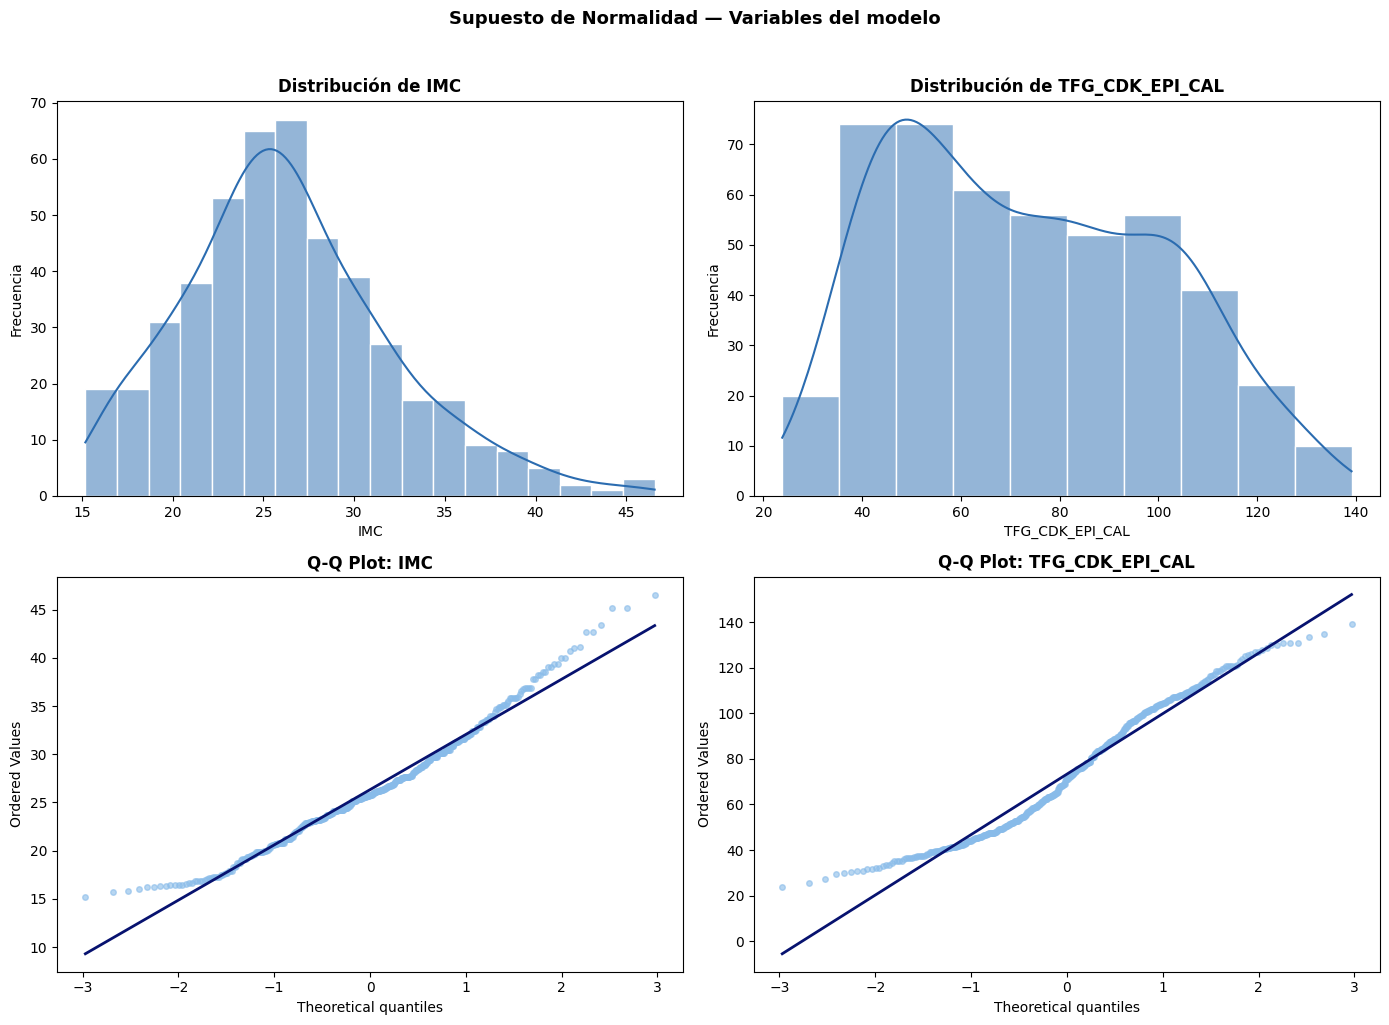

── Shapiro-Wilk ─────────────────────────────
IMC                  W=0.9751  p=0.0000003870  →  La dsitribución NO se ajusta a una distribución normal
TFG_CDK_EPI_CAL      W=0.9612  p=0.0000000010  →  La dsitribución NO se ajusta a una distribución normal


In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, var in enumerate(['IMC', 'TFG_CDK_EPI_CAL']):

    sns.histplot(datos[var], kde=True, color='#2B6CB0',
                 edgecolor='white', ax=axes[0, i])
    axes[0, i].set_title(f'Distribución de {var}', fontweight='bold')
    axes[0, i].set_xlabel(var)
    axes[0, i].set_ylabel('Frecuencia')

    stats.probplot(datos[var], dist="norm", plot=axes[1, i])
    axes[1, i].set_title(f'Q-Q Plot: {var}', fontweight='bold')
    axes[1, i].get_lines()[0].set(color='#88BBE9', alpha=0.6, markersize=4)
    axes[1, i].get_lines()[1].set(color='#07126F', linewidth=2)

plt.suptitle('Supuesto de Normalidad — Variables del modelo',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("── Shapiro-Wilk ─────────────────────────────")
for var in ['IMC', 'TFG_CDK_EPI_CAL']:
    W, p = stats.shapiro(datos[var])
    resultado = '✓ Normal' if p > 0.05 else 'La dsitribución NO se ajusta a una distribución normal'
    print(f"{var:<20} W={W:.4f}  p={p:.10f}  →  {resultado}")

##### **Supuesto de linealidad**

C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\692420040.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=datos, x='Cuartil_IMC', y='TFG_CDK_EPI_CAL',


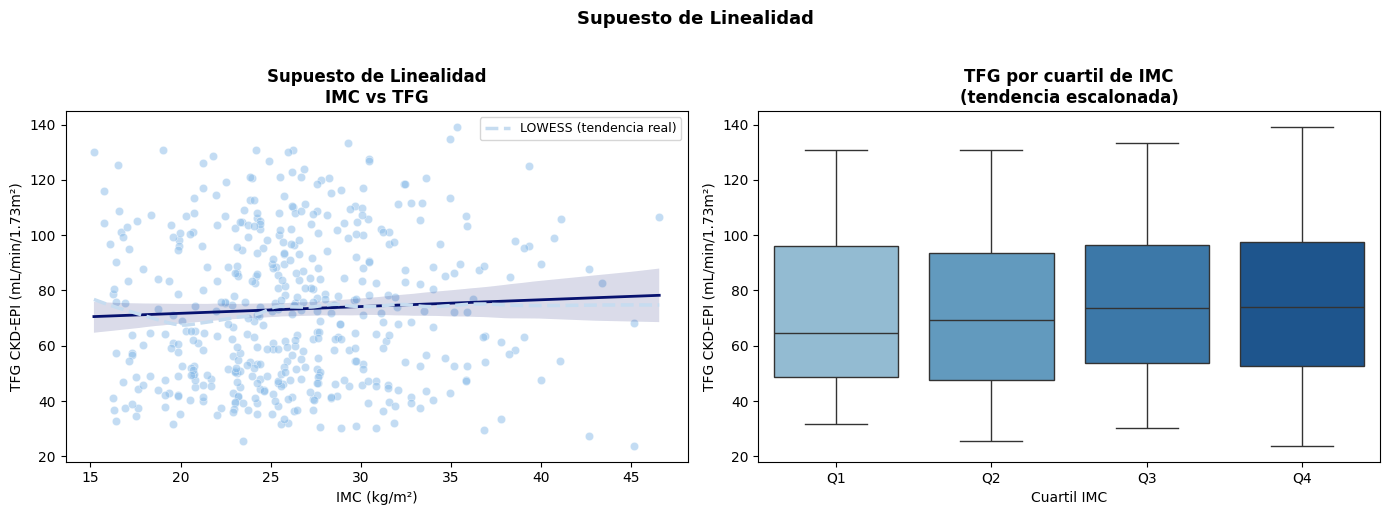

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=datos, x='IMC', y='TFG_CDK_EPI_CAL',
                color='#88BBE9', alpha=0.5, edgecolor='white', ax=axes[0])
sns.regplot(data=datos, x='IMC', y='TFG_CDK_EPI_CAL',
            scatter=False, color='#07126F',
            line_kws={'linewidth': 2, 'label': 'Regresión lineal'}, ax=axes[0])

lw = lowess(datos['TFG_CDK_EPI_CAL'], datos['IMC'], frac=0.4)
axes[0].plot(lw[:, 0], lw[:, 1], color='#C6DCF0', linewidth=2.5,
             linestyle='--', label='LOWESS (tendencia real)')
axes[0].set_title('Supuesto de Linealidad\nIMC vs TFG', fontweight='bold')
axes[0].set_xlabel('IMC (kg/m²)')
axes[0].set_ylabel('TFG CKD-EPI (mL/min/1.73m²)')
axes[0].legend(fontsize=9)

datos['Cuartil_IMC'] = pd.qcut(datos['IMC'], q=4,
                                labels=['Q1', 'Q2', 'Q3', 'Q4'])
pal_q = sns.color_palette("Blues", 6)[2:]
sns.boxplot(data=datos, x='Cuartil_IMC', y='TFG_CDK_EPI_CAL',
            palette=pal_q, ax=axes[1])
axes[1].set_title('TFG por cuartil de IMC\n(tendencia escalonada)',
                  fontweight='bold')
axes[1].set_xlabel('Cuartil IMC')
axes[1].set_ylabel('TFG CKD-EPI (mL/min/1.73m²)')

plt.suptitle('Supuesto de Linealidad', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

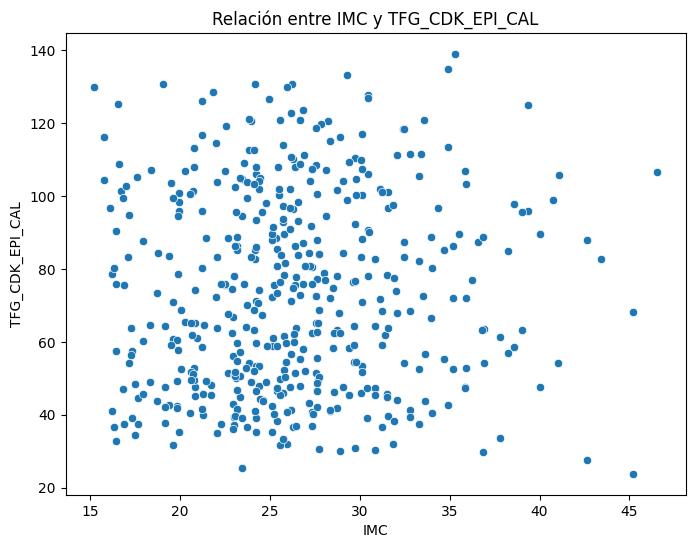

In [50]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='IMC', y='TFG_CDK_EPI_CAL', data=datos)
plt.title('Relación entre IMC y TFG_CDK_EPI_CAL')
plt.xlabel('IMC')
plt.ylabel('TFG_CDK_EPI_CAL')
plt.show()

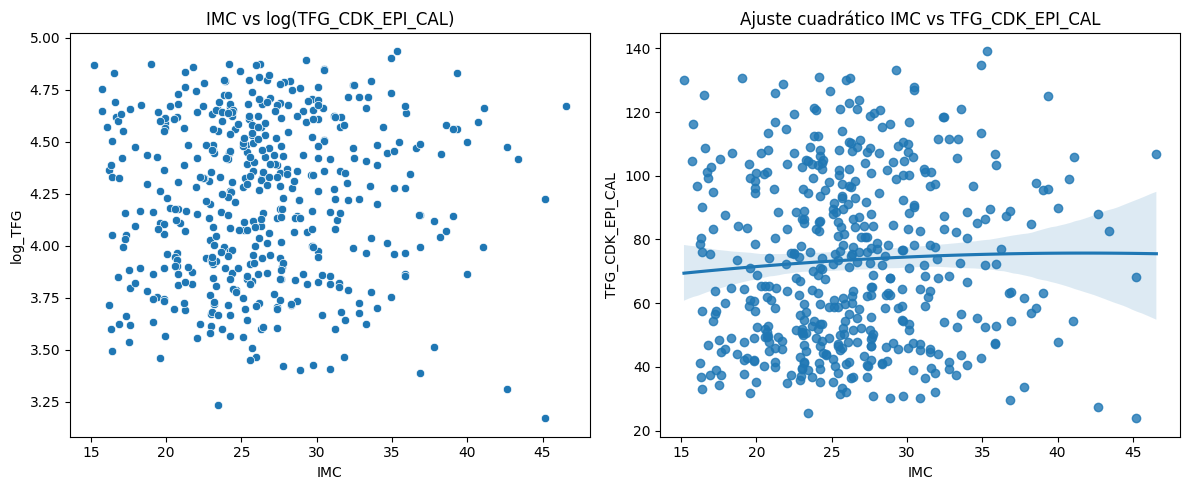

In [51]:
datos['log_TFG'] = np.log(datos['TFG_CDK_EPI_CAL'])
datos['IMC2'] = datos['IMC']**2

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.scatterplot(x='IMC', y='log_TFG', data=datos, ax=axes[0])
axes[0].set_title('IMC vs log(TFG_CDK_EPI_CAL)')

sns.regplot(x='IMC', y='TFG_CDK_EPI_CAL', data=datos, order=2, ax=axes[1])
axes[1].set_title('Ajuste cuadrático IMC vs TFG_CDK_EPI_CAL')

plt.tight_layout()
plt.show()

##### **Correlación**

Correlación de Spearman: rho = 0.0706, p-valor = 0.1278
Interpretación: No significativa (α=0.05)


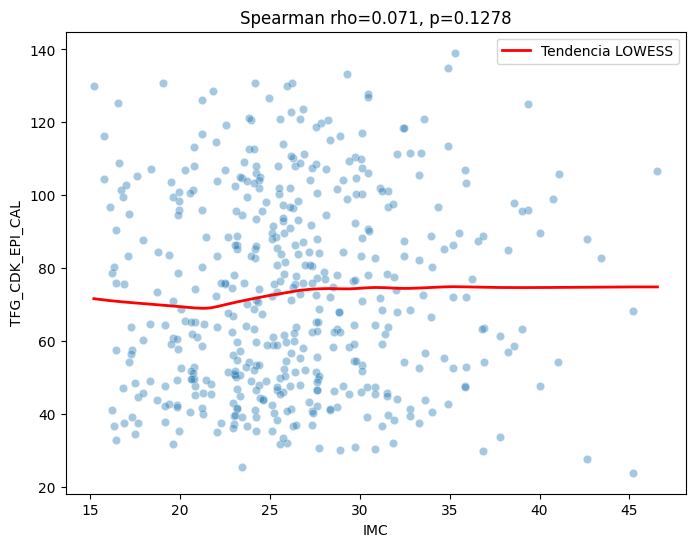

In [52]:
from scipy import stats

var1 = 'IMC'
var2 = 'TFG_CDK_EPI_CAL'

datos = df_tfg[[var1, var2]].dropna()

rho, p_valor = stats.spearmanr(datos[var1], datos[var2])

print(f"Correlación de Spearman: rho = {rho:.4f}, p-valor = {p_valor:.4f}")
print(f"Interpretación: {'Significativa' if p_valor < 0.05 else 'No significativa'} (α=0.05)")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=var1, y=var2, data=datos, alpha=0.4)
sns.regplot(x=var1, y=var2, data=datos, scatter=False,
            lowess=True, line_kws=dict(color='red', linewidth=2), label='Tendencia LOWESS')
plt.title(f'Spearman rho={rho:.3f}, p={p_valor:.4f}')
plt.xlabel(var1)
plt.ylabel(var2)
plt.legend()
plt.show()

##### **Modelo de regresión**

In [53]:
X = sm.add_constant(datos['IMC'])
y = datos['TFG_CDK_EPI_CAL']

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:        TFG_CDK_EPI_CAL   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.289
Date:                Thu, 18 Jun 2026   Prob (F-statistic):              0.257
Time:                        17:40:07   Log-Likelihood:                -2194.3
No. Observations:                 466   AIC:                             4393.
Df Residuals:                     464   BIC:                             4401.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         66.8307      5.821     11.481      0.0

#### ***2. Calcular la relación de valores de IMC (Cuantitativa) con TTFG_CDK_EPI_CAL (cuantitativa) ajustado por los valores de confusión.***

Se sugiere regresión lineal múltiple, correlación. Verificar supuestos.

**Nota:** Se necesita apoyo para selección de variables y orden de entrada según importancia clínica.

In [54]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
variable_dependiente = 'TFG_CDK_EPI_CAL'

VAR_PRED_NUM = ['Edad']
VAR_PRED_CAT = [
    'Municipio_Tamizaje',
    'Genero',
    'Regimen_Salud',
    'Consumo_Tabaco',
    'Consumo_Alcohol',
    'Consumo_Drogas',
    'Trabajo_Cultivo',
    'Uso_Insecticidas',
    'Uso_Fungicidas',
    'Uso_Fertilizantes',
    'Grupo_Sanguineo'
]

todas_las_columnas = ['IMC', variable_dependiente] + VAR_PRED_NUM + VAR_PRED_CAT
datos_modelo = df_tfg[todas_las_columnas].dropna()

for var in VAR_PRED_CAT:
    print(f"{var}: {datos_modelo[var].nunique()} categorías")

Municipio_Tamizaje: 3 categorías
Genero: 2 categorías
Regimen_Salud: 2 categorías
Consumo_Tabaco: 2 categorías
Consumo_Alcohol: 2 categorías
Consumo_Drogas: 2 categorías
Trabajo_Cultivo: 2 categorías
Uso_Insecticidas: 2 categorías
Uso_Fungicidas: 2 categorías
Uso_Fertilizantes: 2 categorías
Grupo_Sanguineo: 2 categorías


In [56]:
def construir_formula(vars_incluidas, num_vars, cat_vars):
    terminos = []
    for v in vars_incluidas:
        if v in cat_vars:
            terminos.append(f"C({v})")
        else:
            terminos.append(v)
    return f"{variable_dependiente} ~ " + " + ".join(terminos)

def ajustar_modelo(vars_incluidas, num_vars, cat_vars, data):
    formula = construir_formula(vars_incluidas, num_vars, cat_vars)
    return smf.ols(formula, data=data).fit(), formula

In [57]:
orden_entrada = ['IMC', 'Edad', 'Genero', 'Regimen_Salud', 'Municipio_Tamizaje',
                  'Consumo_Tabaco', 'Consumo_Alcohol', 'Consumo_Drogas',
                  'Trabajo_Cultivo', 'Uso_Insecticidas', 'Uso_Fungicidas',
                  'Uso_Fertilizantes', 'Grupo_Sanguineo']

vars_actuales = []
modelo_anterior = None
log_resultados = []

for var in orden_entrada:
    vars_nuevas = vars_actuales + [var]
    modelo_nuevo, formula_nueva = ajustar_modelo(vars_nuevas, VAR_PRED_NUM, VAR_PRED_CAT, datos_modelo)

    if modelo_anterior is None:
        log_resultados.append({
            'variable_agregada': var,
            'formula': formula_nueva,
            'AIC': modelo_nuevo.aic,
            'BIC': modelo_nuevo.bic,
            'R2_ajustado': modelo_nuevo.rsquared_adj,
            'p_valor_F_vs_anterior': np.nan,
            'mejora_significativa': 'N/A (modelo base)'
        })
        vars_actuales = vars_nuevas
        modelo_anterior = modelo_nuevo
    else:
        comparacion = sm.stats.anova_lm(modelo_anterior, modelo_nuevo)
        p_valor_f = comparacion['Pr(>F)'].iloc[1]

        mejora = p_valor_f < 0.05
        log_resultados.append({
            'variable_agregada': var,
            'formula': formula_nueva,
            'AIC': modelo_nuevo.aic,
            'BIC': modelo_nuevo.bic,
            'R2_ajustado': modelo_nuevo.rsquared_adj,
            'p_valor_F_vs_anterior': p_valor_f,
            'mejora_significativa': 'Sí' if mejora else 'No'
        })

        if mejora:
            vars_actuales = vars_nuevas
            modelo_anterior = modelo_nuevo

tabla_log = pd.DataFrame(log_resultados)
print(tabla_log.to_string(index=False))
print(f"\nVariables finales en el modelo: {vars_actuales}")

 variable_agregada                                                                                                      formula         AIC         BIC  R2_ajustado  p_valor_F_vs_anterior mejora_significativa
               IMC                                                                                        TFG_CDK_EPI_CAL ~ IMC 4392.619861 4400.908232     0.000620                    NaN    N/A (modelo base)
              Edad                                                                                 TFG_CDK_EPI_CAL ~ IMC + Edad 4366.504788 4378.937345     0.057101           1.274810e-07                   Sí
            Genero                                                                     TFG_CDK_EPI_CAL ~ IMC + Edad + C(Genero) 4348.009781 4364.586523     0.095718           6.629799e-06                   Sí
     Regimen_Salud                                                  TFG_CDK_EPI_CAL ~ IMC + Edad + C(Genero) + C(Regimen_Salud) 4348.424577 4369.145505     0.096834

In [58]:
modelo_final, formula_final = ajustar_modelo(vars_actuales, VAR_PRED_NUM, VAR_PRED_CAT, datos_modelo)
print(f"Fórmula final: {formula_final}\n")
print(modelo_final.summary())

Fórmula final: TFG_CDK_EPI_CAL ~ IMC + Edad + C(Genero) + C(Municipio_Tamizaje) + C(Consumo_Alcohol)

                            OLS Regression Results                            
Dep. Variable:        TFG_CDK_EPI_CAL   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     11.76
Date:                Thu, 18 Jun 2026   Prob (F-statistic):           2.82e-12
Time:                        17:40:08   Log-Likelihood:                -2161.6
No. Observations:                 466   AIC:                             4337.
Df Residuals:                     459   BIC:                             4366.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
---

##### ***Verificación de supuestos***

In [59]:
residuos = modelo_final.resid
predichos = modelo_final.fittedvalues

***Linealidad (residuos vs predictores numéricos del modelo final)***

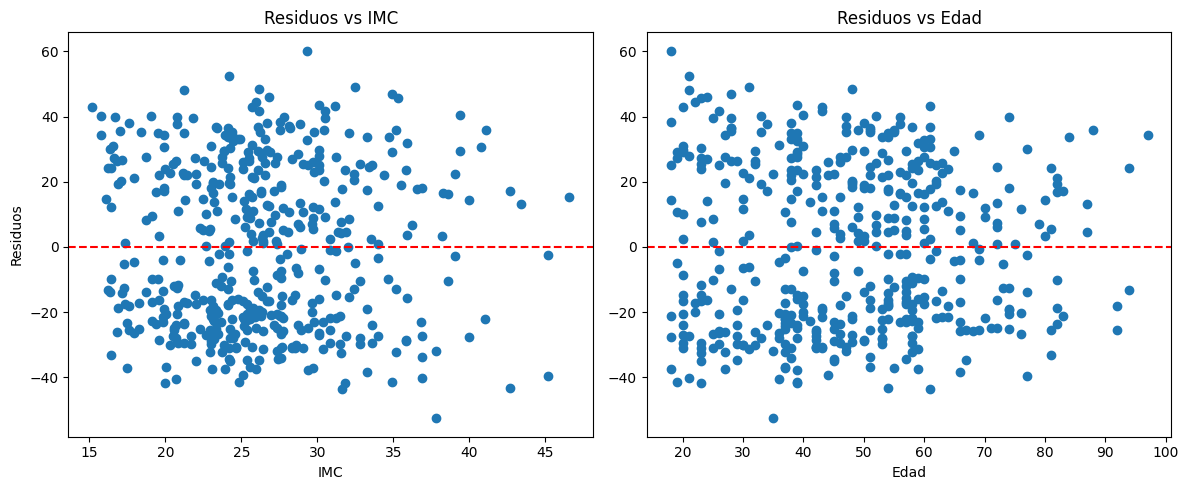

In [60]:
predictores_numericos_finales = [v for v in vars_actuales if v in VAR_PRED_NUM]

fig, axes = plt.subplots(1, len(predictores_numericos_finales) + 1, 
                           figsize=(6*(len(predictores_numericos_finales)+1), 5))
if len(predictores_numericos_finales) == 0:
    axes = [axes]

ax_idx = 0
axes[ax_idx].scatter(datos_modelo['IMC'], residuos)
axes[ax_idx].axhline(0, color='red', linestyle='--')
axes[ax_idx].set_xlabel('IMC')
axes[ax_idx].set_ylabel('Residuos')
axes[ax_idx].set_title('Residuos vs IMC')
ax_idx += 1

for var in predictores_numericos_finales:
    axes[ax_idx].scatter(datos_modelo[var], residuos)
    axes[ax_idx].axhline(0, color='red', linestyle='--')
    axes[ax_idx].set_xlabel(var)
    axes[ax_idx].set_title(f'Residuos vs {var}')
    ax_idx += 1

plt.tight_layout()
plt.show()

***Homocedasticidad***

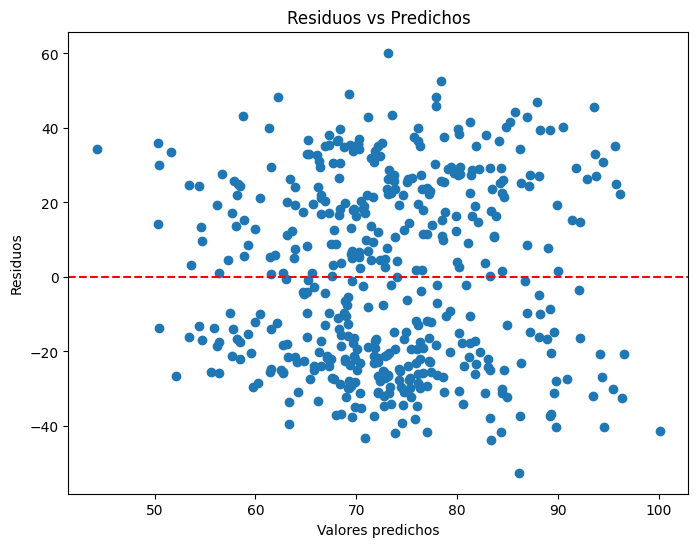

{'LM stat': 32.165444257706305, 'LM p-valor': 1.5168141424338001e-05, 'F stat': 5.671877569790016, 'F p-valor': 1.062255803801712e-05}


In [61]:
plt.figure(figsize=(8,6))
plt.scatter(predichos, residuos)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.title('Residuos vs Predichos')
plt.show()

X_modelo = modelo_final.model.exog
bp_test = het_breuschpagan(residuos, X_modelo)
print(dict(zip(['LM stat', 'LM p-valor', 'F stat', 'F p-valor'], bp_test)))

***Normalidad de residuos***

Shapiro-Wilk: estadístico=0.94651373, p-valor=0.000000000006307


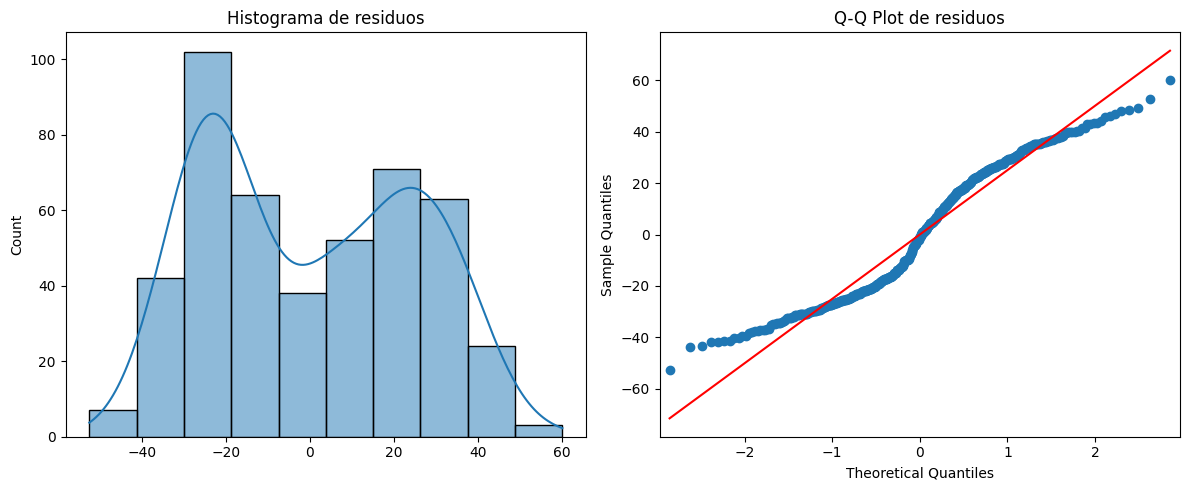

In [62]:
shapiro_resid = stats.shapiro(residuos)
print(f"Shapiro-Wilk: estadístico={shapiro_resid[0]:.8f}, p-valor={shapiro_resid[1]:.15f}")

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(residuos, kde=True, ax=axes[0])
axes[0].set_title('Histograma de residuos')
sm.qqplot(residuos, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot de residuos')
plt.tight_layout()
plt.show()

***Independencia (Durbin-Watson)***

In [63]:
dw = durbin_watson(residuos)
print(f"Durbin-Watson: {dw:.4f}")

Durbin-Watson: 2.0602


***Multicolinealidad***

In [64]:
vars_vif = ['IMC'] + predictores_numericos_finales
X_vif = sm.add_constant(datos_modelo[vars_vif])
vif_data = pd.DataFrame()
vif_data["variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

  variable        VIF
0    const  32.025741
1      IMC   1.008554
2     Edad   1.008554


***Outliers (Distancia de Cook)***

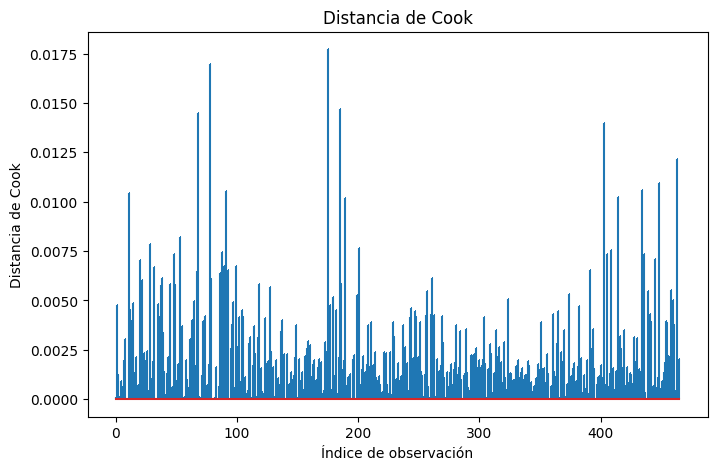

Umbral: 0.0086 | Observaciones que lo superan: 12


In [65]:
influence = modelo_final.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(8,5))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.xlabel('Índice de observación')
plt.ylabel('Distancia de Cook')
plt.title('Distancia de Cook')
plt.show()

umbral = 4 / len(datos_modelo)
print(f"Umbral: {umbral:.4f} | Observaciones que lo superan: {sum(cooks_d > umbral)}")

***Modelo de regresión múltiple con errores robustos***

Esto debido a que no se cumple el supuesto de normalidad y homocedasticidad.

In [66]:
modelo_final_robusto = smf.ols(formula_final, data=datos_modelo).fit(cov_type='HC3')
print(modelo_final_robusto.summary())

                            OLS Regression Results                            
Dep. Variable:        TFG_CDK_EPI_CAL   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     10.88
Date:                Thu, 18 Jun 2026   Prob (F-statistic):           2.43e-11
Time:                        17:40:09   Log-Likelihood:                -2161.6
No. Observations:                 466   AIC:                             4337.
Df Residuals:                     459   BIC:                             4366.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


#### ***3. Valorar la relación de valores de TFG_CDK_EPI_CAL (Cuantitativa) de acuerdo con la clasificación del estado nutricional (cualitativa)***

Se sugiere Anova mixto.

In [67]:
datos_anova = df_tfg[['TFG_CDK_EPI_CAL', 'Categoria_IMC']].dropna()

print("N por categoría:")
print(datos_anova['Categoria_IMC'].value_counts())

N por categoría:
Categoria_IMC
Normal      159
Alto        157
Obesidad    112
Bajo         38
Name: count, dtype: int64


In [68]:
desc = datos_anova.groupby('Categoria_IMC')['TFG_CDK_EPI_CAL'].agg(
    N='count', Media='mean', DE='std', Mediana='median',
    Q1=lambda x: x.quantile(0.25), Q3=lambda x: x.quantile(0.75)
).round(2)
print(desc)

                 N  Media     DE  Mediana     Q1     Q3
Categoria_IMC                                          
Alto           157  74.75  26.58    74.86  51.58  94.44
Bajo            38  72.96  28.68    70.08  47.35  98.74
Normal         159  70.52  26.22    64.63  49.00  94.58
Obesidad       112  75.26  27.73    73.34  52.64  96.93


C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\3002095193.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Categoria_IMC', y='TFG_CDK_EPI_CAL', data=datos_anova,


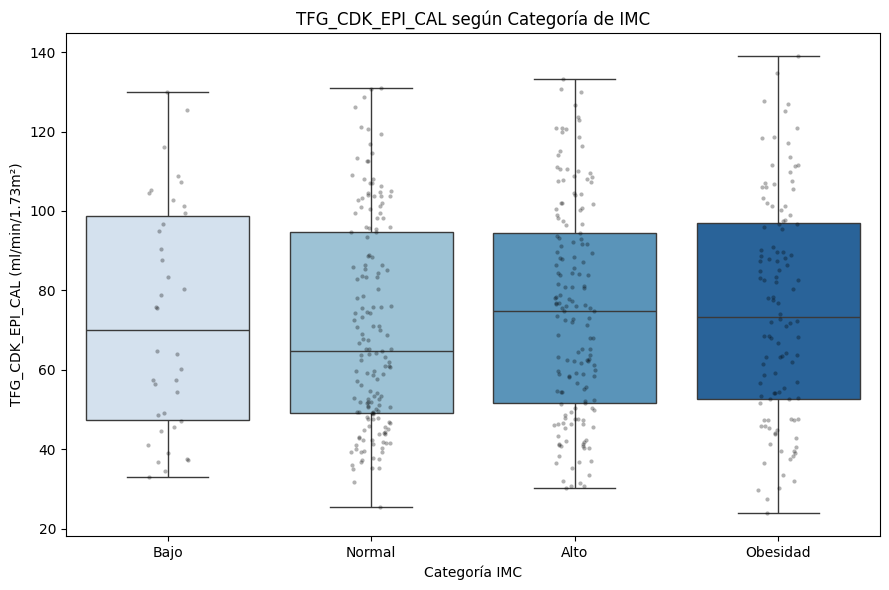

In [69]:
orden_cat = ['Bajo', 'Normal', 'Alto', 'Obesidad'] 
orden_cat = [c for c in orden_cat if c in datos_anova['Categoria_IMC'].unique()]

plt.figure(figsize=(9, 6))
sns.boxplot(x='Categoria_IMC', y='TFG_CDK_EPI_CAL', data=datos_anova,
            order=orden_cat, palette='Blues')
sns.stripplot(x='Categoria_IMC', y='TFG_CDK_EPI_CAL', data=datos_anova,
              order=orden_cat, color='black', alpha=0.3, size=3)
plt.title('TFG_CDK_EPI_CAL según Categoría de IMC')
plt.xlabel('Categoría IMC')
plt.ylabel('TFG_CDK_EPI_CAL (ml/min/1.73m²)')
plt.tight_layout()
plt.show()

##### **Supuestos**

***Normalidad por grupo (Shapiro-Wilk)***

In [70]:
print("=" * 55)
print("SUPUESTO DE NORMALIDAD — Shapiro-Wilk por grupo")
print("=" * 55)
normalidad_ok = True
for cat in orden_cat:
    grupo = datos_anova[datos_anova['Categoria_IMC'] == cat]['TFG_CDK_EPI_CAL']
    stat, p = stats.shapiro(grupo)
    cumple = p > 0.05
    if not cumple:
        normalidad_ok = False
    print(f"{cat:15s} n={len(grupo):3d}  W={stat:.4f}  p={p:.4f}  {'✓ Normal' if cumple else ' No se ajusta a una distribución normal'}")

SUPUESTO DE NORMALIDAD — Shapiro-Wilk por grupo
Bajo            n= 38  W=0.9359  p=0.0308   No se ajusta a una distribución normal
Normal          n=159  W=0.9387  p=0.0000   No se ajusta a una distribución normal
Alto            n=157  W=0.9671  p=0.0008   No se ajusta a una distribución normal
Obesidad        n=112  W=0.9744  p=0.0299   No se ajusta a una distribución normal


***Homogeneidad de varianzas (Levene)***

In [71]:
grupos = [datos_anova[datos_anova['Categoria_IMC'] == cat]['TFG_CDK_EPI_CAL']
          for cat in orden_cat]

stat_lev, p_lev = stats.levene(*grupos)
homogeneidad_ok = p_lev > 0.05
print("=" * 55)
print("SUPUESTO DE HOMOGENEIDAD DE VARIANZAS — Levene")
print("=" * 55)
print(f"Estadístico = {stat_lev:.4f}  p-valor = {p_lev:.4f}")
print(f"→ Homogeneidad: {'CUMPLE' if homogeneidad_ok else 'NO CUMPLE'}")

SUPUESTO DE HOMOGENEIDAD DE VARIANZAS — Levene
Estadístico = 0.5908  p-valor = 0.6213
→ Homogeneidad: CUMPLE


In [72]:
print("\n" + "=" * 55)
print("DECISIÓN Y PRUEBA SELECCIONADA")
print("=" * 55)

if normalidad_ok and homogeneidad_ok:
    print("→ Se cumplen ambos supuestos: ANOVA clásico de un factor")
    resultado = pg.anova(data=datos_anova, dv='TFG_CDK_EPI_CAL',
                         between='Categoria_IMC', detailed=True)
    print(resultado)
    prueba_usada = 'anova_clasico'

else:
    print("→ No se cumple normalidad: Kruskal-Wallis (no paramétrico)")
    stat_kw, p_kw = stats.kruskal(*grupos)
    print(f"Kruskal-Wallis: H = {stat_kw:.4f}, p-valor = {p_kw:.4f}")
    prueba_usada = 'kruskal'


DECISIÓN Y PRUEBA SELECCIONADA
→ No se cumple normalidad: Kruskal-Wallis (no paramétrico)
Kruskal-Wallis: H = 2.7993, p-valor = 0.4236


In [73]:
# Celda 7: POST-HOC según la prueba usada (solo si el resultado global fue significativo)
print("=" * 55)
print("COMPARACIONES POST-HOC POR PARES")
print("=" * 55)

if prueba_usada == 'anova_clasico':
    # Tukey HSD — asume varianzas iguales
    posthoc = pg.pairwise_tukey(data=datos_anova, dv='TFG_CDK_EPI_CAL',
                                 between='Categoria_IMC')
    print("Post-hoc: Tukey HSD")

elif prueba_usada == 'welch':
    # Games-Howell — no asume varianzas iguales, par natural del ANOVA Welch
    posthoc = pg.pairwise_gameshowell(data=datos_anova, dv='TFG_CDK_EPI_CAL',
                                       between='Categoria_IMC')
    print("Post-hoc: Games-Howell")

else:
    # Dunn con corrección Bonferroni — par natural de Kruskal-Wallis
    posthoc = pg.pairwise_tests(data=datos_anova, dv='TFG_CDK_EPI_CAL',
                                 between='Categoria_IMC', parametric=False,
                                 padjust='bonferroni')
    print("Post-hoc: Dunn con corrección Bonferroni")

print(posthoc.to_string(index=False))

COMPARACIONES POST-HOC POR PARES
Post-hoc: Dunn con corrección Bonferroni
     Contrast      A        B  Paired  Parametric   U-val alternative    p-unc   p-corr   p-adjust    hedges
Categoria_IMC   Alto     Bajo   False       False  3129.0   two-sided 0.641140 1.000000 bonferroni  0.066034
Categoria_IMC   Alto   Normal   False       False 13676.0   two-sided 0.141470 0.848821 bonferroni  0.159803
Categoria_IMC   Alto Obesidad   False       False  8718.5   two-sided 0.907607 1.000000 bonferroni -0.018514
Categoria_IMC   Bajo   Normal   False       False  3116.5   two-sided 0.763507 1.000000 bonferroni  0.090997
Categoria_IMC   Bajo Obesidad   False       False  2021.0   two-sided 0.645368 1.000000 bonferroni -0.081535
Categoria_IMC Normal Obesidad   False       False  8019.0   two-sided 0.163867 0.983200 bonferroni -0.175703


***Distribuciones de los grupos tienen forma similar***

C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2545765012.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Categoria_IMC', y='TFG_CDK_EPI_CAL', data=datos_anova,


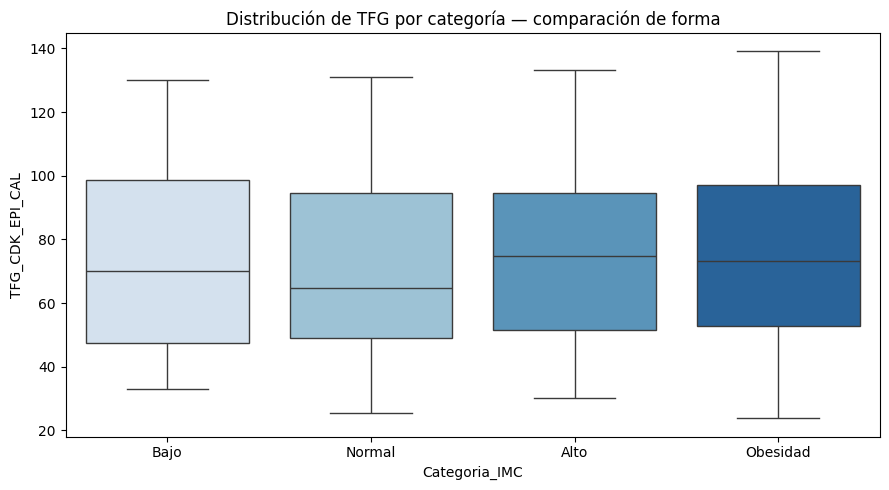

In [74]:
# Complementar con boxplot comparativo para ver asimetría y dispersión
plt.figure(figsize=(9, 5))
sns.boxplot(x='Categoria_IMC', y='TFG_CDK_EPI_CAL', data=datos_anova,
            order=orden_cat, palette='Blues')
plt.title('Distribución de TFG por categoría — comparación de forma')
plt.tight_layout()
plt.show()

## **Relación estado nutricional (Cualitativa) vs estadios de ERC**

#### ***4. Valorar la relación de valores de estado nutricional (cualitativa) con Estadios de ERC. Primero sin estratificar y luego estratificado por presencia de HTA y en otra DM.***

##### ***Chi-cuadrado***

In [75]:
VAR_ESTADO_NUT = 'Categoria_IMC'
VAR_ERC = 'Estadio_ERC_CAL'      
VAR_HTA = 'Hipertension'
VAR_DM  = 'Medicacion_Diabetes'   

cols = [VAR_ESTADO_NUT, VAR_ERC, VAR_HTA, VAR_DM]
datos_chi = df_tfg[cols].dropna()

print(f"Observaciones disponibles: {len(datos_chi)}")
print(f"\nCategorías de {VAR_ESTADO_NUT}:\n{datos_chi[VAR_ESTADO_NUT].value_counts()}")
print(f"\nCategorías de {VAR_ERC}:\n{datos_chi[VAR_ERC].value_counts()}")
print(f"\nCategorías de {VAR_HTA}:\n{datos_chi[VAR_HTA].value_counts()}")
print(f"\nCategorías de {VAR_DM}:\n{datos_chi[VAR_DM].value_counts()}")

Observaciones disponibles: 466

Categorías de Categoria_IMC:
Categoria_IMC
Normal      159
Alto        157
Obesidad    112
Bajo         38
Name: count, dtype: int64

Categorías de Estadio_ERC_CAL:
Estadio_ERC_CAL
G3: Descenso Moderado (30-59)    177
G2: Descenso Leve (60-89)        149
G1: Normal o Elevado (≥90)       136
G4: Descenso Grave (15-29)         4
Name: count, dtype: int64

Categorías de Hipertension:
Hipertension
No    268
Si    198
Name: count, dtype: int64

Categorías de Medicacion_Diabetes:
Medicacion_Diabetes
No    433
Si     33
Name: count, dtype: int64


In [76]:
def ajustar_logistico_ordinal(data, formula_vars, var_dep, titulo=''):
    X = pd.get_dummies(data[formula_vars], drop_first=True).astype(float)
    y = data[var_dep]

    modelo = OrderedModel(y, X, distr='logit')
    resultado = modelo.fit(method='bfgs', disp=False)

    print(f"\n{'='*65}")
    print(f"  {titulo}")
    print(f"  n = {len(data)}")
    print(f"{'='*65}")
    print(resultado.summary())

    params = resultado.params
    conf = resultado.conf_int()
    or_table = pd.DataFrame({
        'OR': np.exp(params),
        'IC_2.5%': np.exp(conf[0]),
        'IC_97.5%': np.exp(conf[1]),
        'p_valor': resultado.pvalues
    })
    or_table = or_table[~or_table.index.str.contains('/')]
    print(f"\nOdds Ratios:")
    print(or_table.round(4))

    return resultado, or_table

In [77]:
# Chi-cuadrado con verificación de supuesto (frecuencias esperadas)
def chi_cuadrado_completo(data, var_fila, var_col, titulo=''):
    tabla = pd.crosstab(data[var_fila], data[var_col])
    tabla_pct = pd.crosstab(data[var_fila], data[var_col], normalize='index') * 100

    chi2, p, dof, esperadas = stats.chi2_contingency(tabla)

    # Verificar supuesto: frecuencias esperadas >= 5 en al menos 80% de las celdas
    pct_celdas_ok = (esperadas >= 5).sum() / esperadas.size
    supuesto_ok = pct_celdas_ok >= 0.80

    print(f"\n{'='*60}")
    print(f"  {titulo}")
    print(f"{'='*60}")
    print(f"\nTabla de contingencia (n):")
    print(tabla)
    print(f"\nTabla de contingencia (% por fila):")
    print(tabla_pct.round(1))
    print(f"\nFrecuencias esperadas:")
    print(pd.DataFrame(esperadas.round(1), index=tabla.index, columns=tabla.columns))
    print(f"\n→ Supuesto frecuencias esperadas ≥ 5: {'✓ CUMPLE' if supuesto_ok else '✗ NO CUMPLE — usar Fisher'} ({pct_celdas_ok*100:.0f}% celdas ok)")

    if supuesto_ok:
        print(f"\nChi-cuadrado: χ²={chi2:.4f}, gl={dof}, p-valor={p:.4f}")
        print(f"→ {'Asociación significativa' if p < 0.05 else 'Sin asociación significativa'} (α=0.05)")
    else:
        if tabla.shape == (2, 2):
            odds, p_fisher = stats.fisher_exact(tabla)
            print(f"\nFisher exacto: OR={odds:.4f}, p-valor={p_fisher:.4f}")
            print(f"→ {'Asociación significativa' if p_fisher < 0.05 else 'Sin asociación significativa'} (α=0.05)")
        else:
            print(f"\nTabla > 2x2, se reporta Chi-cuadrado con advertencia de frecuencias bajas:")
            print(f"Chi-cuadrado: χ²={chi2:.4f}, gl={dof}, p-valor={p:.4f}")
            print(f"→ {'Asociación significativa' if p < 0.05 else 'Sin asociación significativa'} (α=0.05) ⚠️ interpretar con cautela")

    return tabla, chi2, p

In [78]:
def plot_contingencia(data, var_fila, var_col, titulo=''):
    n = pd.crosstab(data[var_fila], data[var_col], margins=True, margins_name='Total')
    pct = pd.crosstab(data[var_fila], data[var_col], normalize='index') * 100

    # Combinar n y % en una sola tabla: "n (xx.x%)"
    tabla_combinada = pd.DataFrame(index=n.index, columns=n.columns)
    for col in n.columns:
        for fila in n.index:
            if fila == 'Total' or col == 'Total':
                tabla_combinada.loc[fila, col] = str(n.loc[fila, col])
            else:
                tabla_combinada.loc[fila, col] = f"{n.loc[fila, col]} ({pct.loc[fila, col]:.1f}%)"

    fig, ax = plt.subplots(figsize=(12, len(n) * 0.7 + 1.5))
    ax.axis('off')

    tabla_plot = ax.table(
        cellText=tabla_combinada.values,
        rowLabels=tabla_combinada.index,
        colLabels=tabla_combinada.columns,
        cellLoc='center',
        loc='center'
    )

    tabla_plot.auto_set_font_size(False)
    tabla_plot.set_fontsize(10)
    tabla_plot.scale(1.2, 1.8)

    n_cols = len(tabla_combinada.columns)
    n_filas = len(tabla_combinada.index)

    for (fila, col), celda in tabla_plot.get_celld().items():
        celda.set_edgecolor('#cccccc')
        if fila == 0:  # encabezado columnas
            celda.set_facecolor('#07126F')
            celda.set_text_props(color='white', fontweight='bold')
        elif col == -1:  # encabezado filas (rowLabels)
            if tabla_combinada.index[fila - 1] == 'Total':
                celda.set_facecolor('#d0d0d0')
                celda.set_text_props(fontweight='bold')
            else:
                celda.set_facecolor('#e8eaf6')
                celda.set_text_props(fontweight='bold')
        elif tabla_combinada.index[fila - 1] == 'Total':
            celda.set_facecolor('#d0d0d0')
            celda.set_text_props(fontweight='bold')
        elif fila % 2 == 0:
            celda.set_facecolor('#f5f5f5')
        else:
            celda.set_facecolor('white')

    plt.title(titulo, fontweight='bold', fontsize=12, pad=15)
    plt.tight_layout()
    plt.show()

***Sin estratificar***


  Estado nutricional vs Estadio ERC — Sin estratificar

Tabla de contingencia (n):
Estadio_ERC_CAL  G1: Normal o Elevado (≥90)  G2: Descenso Leve (60-89)  \
Categoria_IMC                                                            
Alto                                     47                         54   
Bajo                                     13                          9   
Normal                                   42                         47   
Obesidad                                 34                         39   

Estadio_ERC_CAL  G3: Descenso Moderado (30-59)  G4: Descenso Grave (15-29)  
Categoria_IMC                                                               
Alto                                        56                           0  
Bajo                                        16                           0  
Normal                                      69                           1  
Obesidad                                    36                           3  

Tabla de

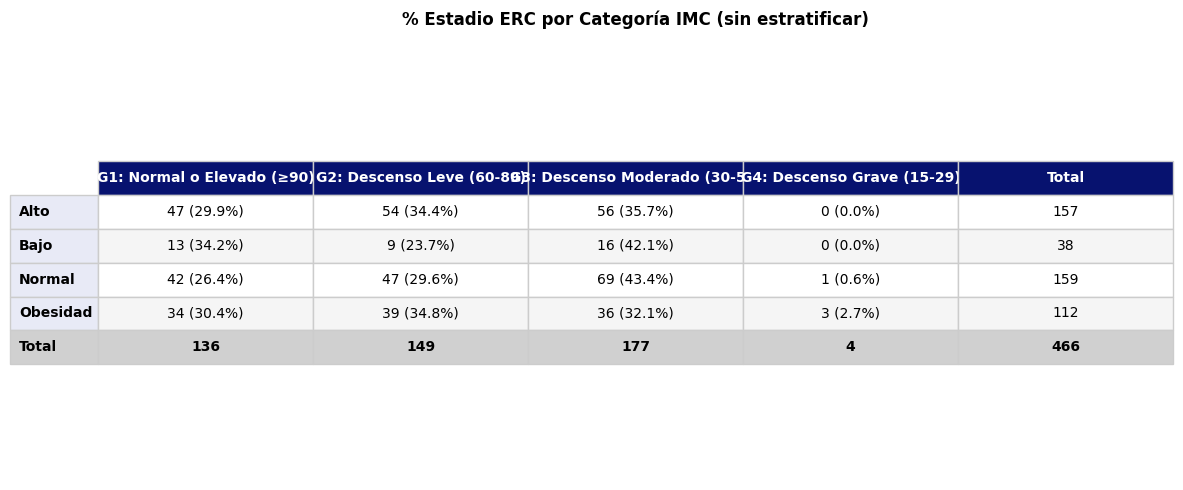

In [79]:
tabla_global, chi2_global, p_global = chi_cuadrado_completo(
    datos_chi, VAR_ESTADO_NUT, VAR_ERC,
    titulo='Estado nutricional vs Estadio ERC — Sin estratificar'
)
plot_contingencia(datos_chi, VAR_ESTADO_NUT, VAR_ERC,
                  titulo='% Estadio ERC por Categoría IMC (sin estratificar)')

***Estratificado por presencia de HTA***


  ESTRATIFICADO POR HIPERTENSIÓN

  Estado nutricional vs Estadio ERC — Hipertension: Si (n=198)

Tabla de contingencia (n):
Estadio_ERC_CAL  G1: Normal o Elevado (≥90)  G2: Descenso Leve (60-89)  \
Categoria_IMC                                                            
Alto                                     15                         29   
Bajo                                      2                          6   
Normal                                   22                         16   
Obesidad                                  9                         16   

Estadio_ERC_CAL  G3: Descenso Moderado (30-59)  G4: Descenso Grave (15-29)  
Categoria_IMC                                                               
Alto                                        22                           0  
Bajo                                         7                           0  
Normal                                      33                           1  
Obesidad                                    

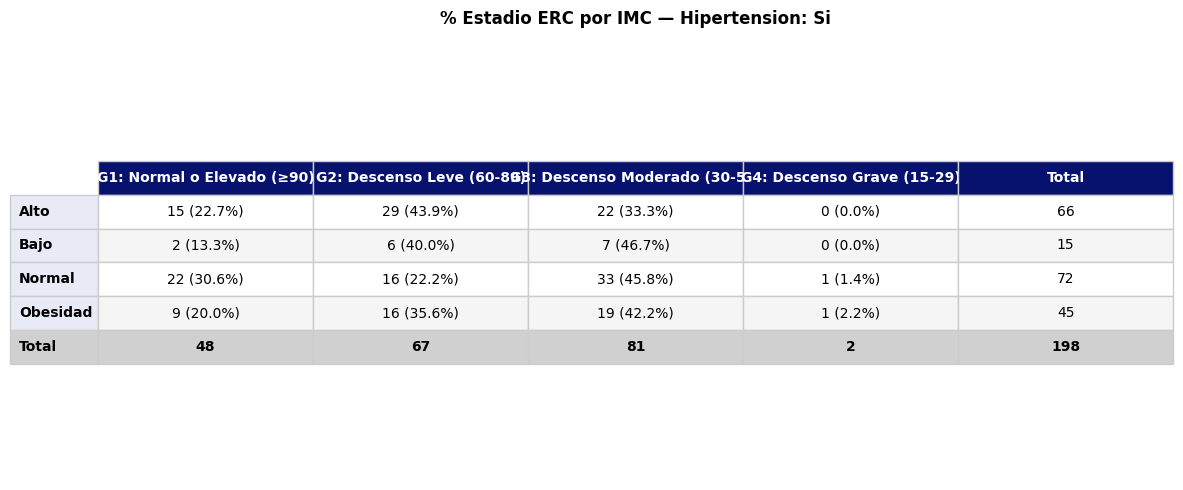


  Estado nutricional vs Estadio ERC — Hipertension: No (n=268)

Tabla de contingencia (n):
Estadio_ERC_CAL  G1: Normal o Elevado (≥90)  G2: Descenso Leve (60-89)  \
Categoria_IMC                                                            
Alto                                     32                         25   
Bajo                                     11                          3   
Normal                                   20                         31   
Obesidad                                 25                         23   

Estadio_ERC_CAL  G3: Descenso Moderado (30-59)  G4: Descenso Grave (15-29)  
Categoria_IMC                                                               
Alto                                        34                           0  
Bajo                                         9                           0  
Normal                                      36                           0  
Obesidad                                    17                           2  



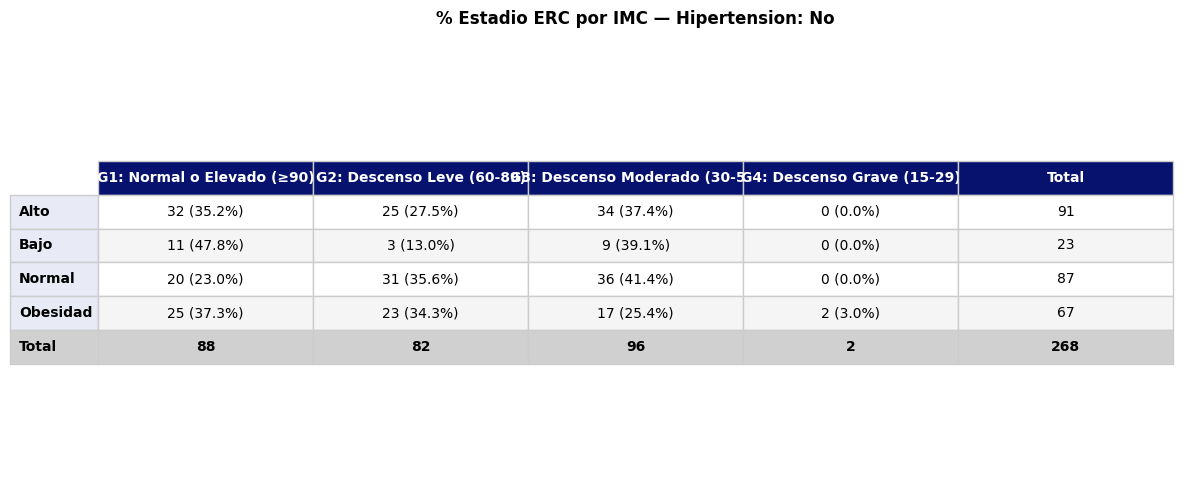

In [80]:
print("\n" + "="*60)
print("  ESTRATIFICADO POR HIPERTENSIÓN")
print("="*60)

for estrato in datos_chi[VAR_HTA].unique():
    subset = datos_chi[datos_chi[VAR_HTA] == estrato]
    chi_cuadrado_completo(
        subset, VAR_ESTADO_NUT, VAR_ERC,
        titulo=f'Estado nutricional vs Estadio ERC — {VAR_HTA}: {estrato} (n={len(subset)})'
    )
    plot_contingencia(
        subset, VAR_ESTADO_NUT, VAR_ERC,
        titulo=f'% Estadio ERC por IMC — {VAR_HTA}: {estrato}'
    )

***Estratificado por DM***


  ESTRATIFICADO POR DIABETES

  Estado nutricional vs Estadio ERC — Medicacion_Diabetes: Si (n=33)

Tabla de contingencia (n):
Estadio_ERC_CAL  G1: Normal o Elevado (≥90)  G2: Descenso Leve (60-89)  \
Categoria_IMC                                                            
Alto                                      1                          5   
Bajo                                      1                          0   
Normal                                    3                          3   
Obesidad                                  2                          5   

Estadio_ERC_CAL  G3: Descenso Moderado (30-59)  G4: Descenso Grave (15-29)  
Categoria_IMC                                                               
Alto                                         3                           0  
Bajo                                         0                           0  
Normal                                       7                           0  
Obesidad                                  

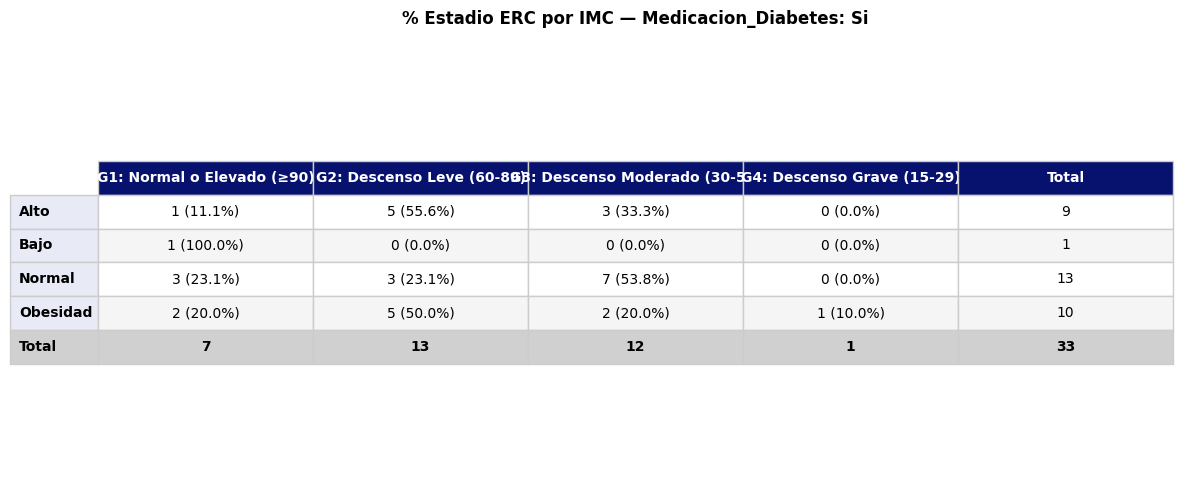


  Estado nutricional vs Estadio ERC — Medicacion_Diabetes: No (n=433)

Tabla de contingencia (n):
Estadio_ERC_CAL  G1: Normal o Elevado (≥90)  G2: Descenso Leve (60-89)  \
Categoria_IMC                                                            
Alto                                     46                         49   
Bajo                                     12                          9   
Normal                                   39                         44   
Obesidad                                 32                         34   

Estadio_ERC_CAL  G3: Descenso Moderado (30-59)  G4: Descenso Grave (15-29)  
Categoria_IMC                                                               
Alto                                        53                           0  
Bajo                                        16                           0  
Normal                                      62                           1  
Obesidad                                    34                         

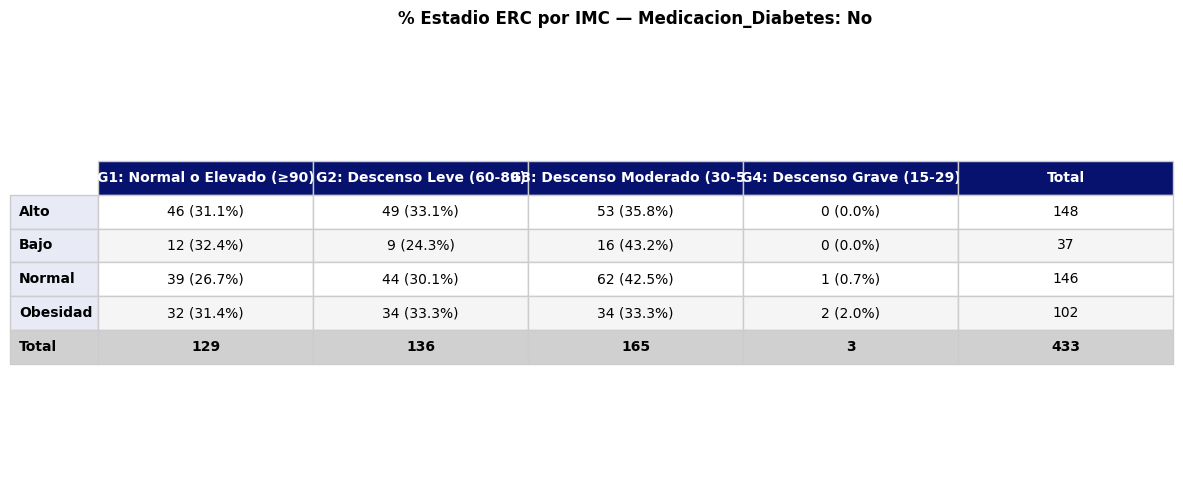

In [81]:
print("\n" + "="*60)
print("  ESTRATIFICADO POR DIABETES")
print("="*60)

for estrato in datos_chi[VAR_DM].unique():
    subset = datos_chi[datos_chi[VAR_DM] == estrato]
    chi_cuadrado_completo(
        subset, VAR_ESTADO_NUT, VAR_ERC,
        titulo=f'Estado nutricional vs Estadio ERC — {VAR_DM}: {estrato} (n={len(subset)})'
    )
    plot_contingencia(
        subset, VAR_ESTADO_NUT, VAR_ERC,
        titulo=f'% Estadio ERC por IMC — {VAR_DM}: {estrato}'
    )

In [82]:
print("\n" + "="*60)
print("  RESUMEN DE RESULTADOS")
print("="*60)
print(f"{'Análisis':<45} {'χ²':>8} {'p-valor':>10} {'Sig':>6}")
print("-"*60)

analisis_list = [('Sin estratificar', datos_chi)]
for estrato in datos_chi[VAR_HTA].unique():
    analisis_list.append((f'HTA: {estrato}', datos_chi[datos_chi[VAR_HTA] == estrato]))
for estrato in datos_chi[VAR_DM].unique():
    analisis_list.append((f'DM: {estrato}', datos_chi[datos_chi[VAR_DM] == estrato]))

for nombre, subset in analisis_list:
    tabla = pd.crosstab(subset[VAR_ESTADO_NUT], subset[VAR_ERC])
    chi2, p, dof, esp = stats.chi2_contingency(tabla)
    sig = '✓' if p < 0.05 else '✗'
    print(f"{nombre:<45} {chi2:>8.3f} {p:>10.4f} {sig:>6}")


  RESUMEN DE RESULTADOS
Análisis                                            χ²    p-valor    Sig
------------------------------------------------------------
Sin estratificar                                11.226     0.2605      ✗
HTA: Si                                         10.454     0.3150      ✗
HTA: No                                         17.258     0.0448      ✓
DM: Si                                          10.058     0.3458      ✗
DM: No                                           7.090     0.6278      ✗


##### ***Chi-cuadrado de Mantel-Haenszel***

El Chi-cuadrado de Mantel-Haenszel es una prueba que evalúa la asociación entre dos variables categóricas mientras controla el efecto de una tercera variable (el estratificador), combinando la información de múltiples tablas de contingencia (una por cada estrato) en un único estadístico ponderado. A diferencia de analizar cada estrato por separado, este método pondera la contribución de cada tabla según su tamaño y variabilidad interna, produciendo una medida resumen de la asociación condicional entre las dos variables principales, es decir, la asociación que persiste después de remover la influencia de la variable de estratificación.

En el contexto clínico, esta prueba es central en estudios epidemiológicos y de investigación en salud porque permite responder preguntas del tipo "¿la asociación entre exposición y desenlace se mantiene después de ajustar por una comorbilidad o factor de riesgo conocido?", sin necesidad de construir un modelo multivariado completo. Es particularmente útil para detectar confusión (cuando el estratificador distorsiona la relación observada) y modificación de efecto (cuando la fuerza de la asociación difiere claramente entre estratos, sugiriendo que el efecto de la exposición no es uniforme en toda la población).

In [83]:
VAR_ESTADO_NUT = 'Categoria_IMC'
VAR_ERC        = 'Estadio_ERC_CAL'
VAR_HTA        = 'Hipertension'
VAR_DM         = 'Medicacion_Diabetes'

cols = [VAR_ESTADO_NUT, VAR_ERC, VAR_HTA, VAR_DM]
datos_mh = df_tfg[cols].dropna()

print(f"Observaciones: {len(datos_mh)}")
print(f"\n{VAR_ESTADO_NUT}:\n{datos_mh[VAR_ESTADO_NUT].value_counts()}")
print(f"\n{VAR_ERC}:\n{datos_mh[VAR_ERC].value_counts()}")
print(f"\n{VAR_HTA}:\n{datos_mh[VAR_HTA].value_counts()}")
print(f"\n{VAR_DM}:\n{datos_mh[VAR_DM].value_counts()}")

Observaciones: 466

Categoria_IMC:
Categoria_IMC
Normal      159
Alto        157
Obesidad    112
Bajo         38
Name: count, dtype: int64

Estadio_ERC_CAL:
Estadio_ERC_CAL
G3: Descenso Moderado (30-59)    177
G2: Descenso Leve (60-89)        149
G1: Normal o Elevado (≥90)       136
G4: Descenso Grave (15-29)         4
Name: count, dtype: int64

Hipertension:
Hipertension
No    268
Si    198
Name: count, dtype: int64

Medicacion_Diabetes:
Medicacion_Diabetes
No    433
Si     33
Name: count, dtype: int64


In [84]:
def mantel_haenszel(data, var_fila, var_col, var_estrato, titulo=''):
    estratos = data[var_estrato].unique()

    print(f"\n{'='*65}")
    print(f"  {titulo}")
    print(f"  Estratificado por: {var_estrato}")
    print(f"{'='*65}")

    chi2_estratos = []
    for estrato in estratos:
        subset = data[data[var_estrato] == estrato]
        tabla = pd.crosstab(subset[var_fila], subset[var_col])
        chi2, p, dof, esp = stats.chi2_contingency(tabla)
        chi2_estratos.append({
            'estrato': estrato,
            'n': len(subset),
            'chi2': chi2,
            'gl': dof,
            'p_valor': p,
            'significativo': '✓' if p < 0.05 else '✗'
        })
        print(f"\n  Estrato [{var_estrato} = {estrato}] — n={len(subset)}")
        print(f"  Chi²={chi2:.4f}, gl={dof}, p={p:.4f} {'✓ Sig.' if p < 0.05 else '✗ No sig.'}")
        print(f"\n  Tabla de contingencia (n):")
        print(tabla.to_string())
        pct = pd.crosstab(subset[var_fila], subset[var_col], normalize='index') * 100
        print(f"\n  Tabla de contingencia (% por fila):")
        print(pct.round(1).to_string())

    # Chi-cuadrado de Mantel-Haenszel global
    # Suma ponderada de chi2 por estrato (estadístico MH)
    # Para tablas RxC se usa la suma de chi2 por estrato como aproximación
    chi2_mh = sum([e['chi2'] for e in chi2_estratos])
    gl_mh   = sum([e['gl']   for e in chi2_estratos])
    p_mh    = 1 - stats.chi2.cdf(chi2_mh, gl_mh)

    print(f"\n{'-'*65}")
    print(f"  ESTADÍSTICO MANTEL-HAENSZEL GLOBAL")
    print(f"  (asociación entre {var_fila} y {var_col} controlando por {var_estrato})")
    print(f"  Chi²-MH = {chi2_mh:.4f}, gl = {gl_mh}, p-valor = {p_mh:.4f}")
    print(f"  → {'Asociación significativa' if p_mh < 0.05 else 'Sin asociación significativa'} controlando por {var_estrato} (α=0.05)")
    print(f"{'-'*65}")

    return pd.DataFrame(chi2_estratos), chi2_mh, p_mh

In [85]:
def plot_estratificado(data, var_fila, var_col, var_estrato, titulo=''):
    estratos = sorted(data[var_estrato].unique())
    n_estratos = len(estratos)

    colores_azules = ['#9ECAE1', '#4292C6', '#08519C', '#08306B']

    fig, axes = plt.subplots(1, n_estratos, figsize=(7 * n_estratos, 5), sharey=True)
    if n_estratos == 1:
        axes = [axes]

    for ax, estrato in zip(axes, estratos):
        subset = data[data[var_estrato] == estrato]
        pct = pd.crosstab(subset[var_fila], subset[var_col], normalize='index') * 100
        n_categorias = pct.shape[1]
        pct.plot(kind='bar', stacked=True, ax=ax,
                  color=colores_azules[:n_categorias], edgecolor='white')
        ax.set_title(f'{var_estrato} = {estrato}\n(n={len(subset)})', fontweight='bold')
        ax.set_xlabel(var_fila)
        ax.set_ylabel('% dentro de categoría IMC')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
        ax.legend(title=var_col, bbox_to_anchor=(1.05, 1), fontsize=8)

    plt.suptitle(titulo, fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()

***Sin estratificar***

In [86]:
print("\n" + "="*65)
print("  ANÁLISIS GLOBAL — SIN ESTRATIFICAR")
print("="*65)
tabla_global = pd.crosstab(datos_mh[VAR_ESTADO_NUT], datos_mh[VAR_ERC])
chi2_g, p_g, dof_g, _ = stats.chi2_contingency(tabla_global)
print(f"\nChi²={chi2_g:.4f}, gl={dof_g}, p-valor={p_g:.4f}")
print(f"→ {'Asociación significativa' if p_g < 0.05 else 'Sin asociación significativa'} (α=0.05)")
print(tabla_global)


  ANÁLISIS GLOBAL — SIN ESTRATIFICAR

Chi²=11.2263, gl=9, p-valor=0.2605
→ Sin asociación significativa (α=0.05)
Estadio_ERC_CAL  G1: Normal o Elevado (≥90)  G2: Descenso Leve (60-89)  \
Categoria_IMC                                                            
Alto                                     47                         54   
Bajo                                     13                          9   
Normal                                   42                         47   
Obesidad                                 34                         39   

Estadio_ERC_CAL  G3: Descenso Moderado (30-59)  G4: Descenso Grave (15-29)  
Categoria_IMC                                                               
Alto                                        56                           0  
Bajo                                        16                           0  
Normal                                      69                           1  
Obesidad                                    36          

***Estratificado por HTA***


  Estado nutricional vs Estadio ERC — Estratificado por HTA
  Estratificado por: Hipertension

  Estrato [Hipertension = Si] — n=198
  Chi²=10.4535, gl=9, p=0.3150 ✗ No sig.

  Tabla de contingencia (n):
Estadio_ERC_CAL  G1: Normal o Elevado (≥90)  G2: Descenso Leve (60-89)  G3: Descenso Moderado (30-59)  G4: Descenso Grave (15-29)
Categoria_IMC                                                                                                                    
Alto                                     15                         29                             22                           0
Bajo                                      2                          6                              7                           0
Normal                                   22                         16                             33                           1
Obesidad                                  9                         16                             19                           1

  Tabla de con

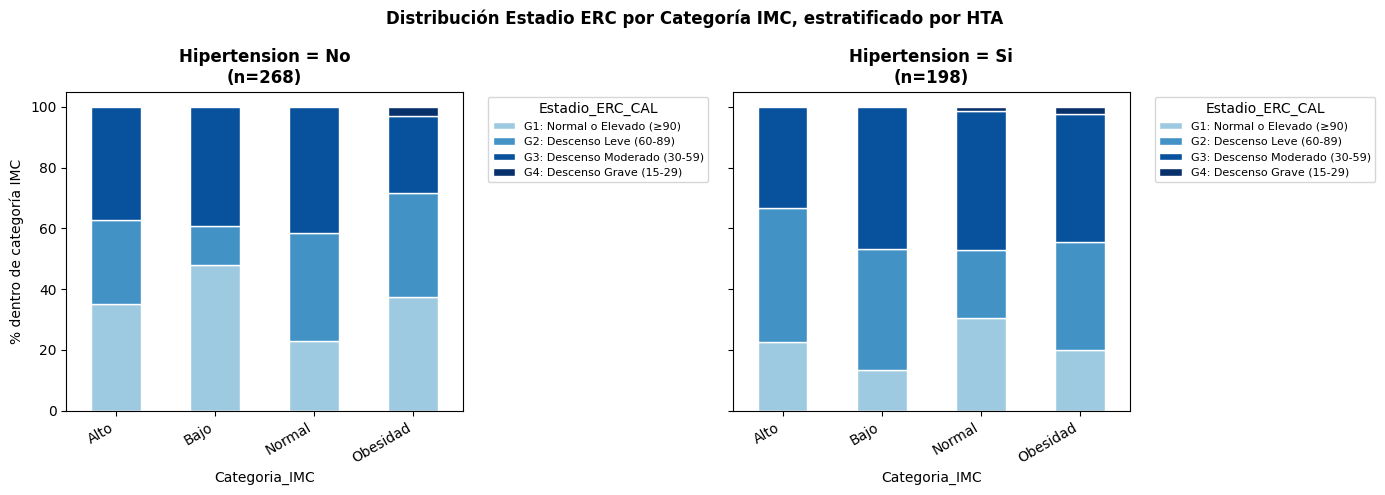

In [87]:
tabla_hta, chi2_hta, p_hta = mantel_haenszel(
    datos_mh, VAR_ESTADO_NUT, VAR_ERC, VAR_HTA,
    titulo='Estado nutricional vs Estadio ERC — Estratificado por HTA'
)
plot_estratificado(
    datos_mh, VAR_ESTADO_NUT, VAR_ERC, VAR_HTA,
    titulo='Distribución Estadio ERC por Categoría IMC, estratificado por HTA'
)

***Estratificado por presencia de DM***


  Estado nutricional vs Estadio ERC — Estratificado por DM
  Estratificado por: Medicacion_Diabetes

  Estrato [Medicacion_Diabetes = Si] — n=33
  Chi²=10.0578, gl=9, p=0.3458 ✗ No sig.

  Tabla de contingencia (n):
Estadio_ERC_CAL  G1: Normal o Elevado (≥90)  G2: Descenso Leve (60-89)  G3: Descenso Moderado (30-59)  G4: Descenso Grave (15-29)
Categoria_IMC                                                                                                                    
Alto                                      1                          5                              3                           0
Bajo                                      1                          0                              0                           0
Normal                                    3                          3                              7                           0
Obesidad                                  2                          5                              2                           1

  

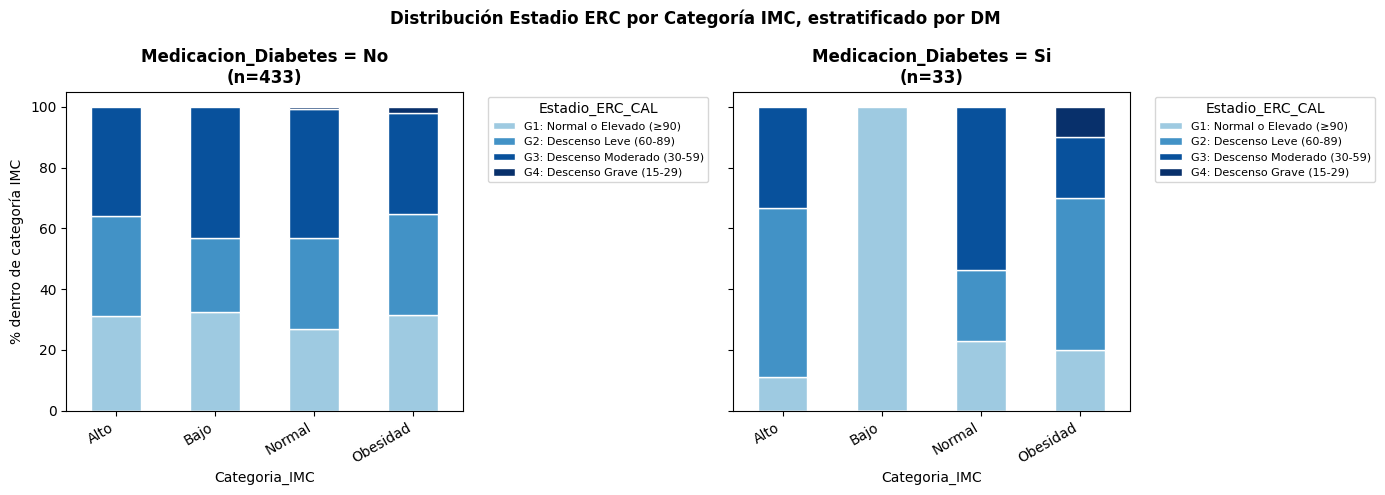

In [88]:
tabla_dm, chi2_dm, p_dm = mantel_haenszel(
    datos_mh, VAR_ESTADO_NUT, VAR_ERC, VAR_DM,
    titulo='Estado nutricional vs Estadio ERC — Estratificado por DM'
)
plot_estratificado(
    datos_mh, VAR_ESTADO_NUT, VAR_ERC, VAR_DM,
    titulo='Distribución Estadio ERC por Categoría IMC, estratificado por DM'
)

#### **Regresión ordinal**

La regresión logística ordinal modela la probabilidad de pertenecer a un estadio de ERC igual o más grave, asumiendo que detrás de las cuatro categorías observadas (G1 a G4) existe una escala continua de severidad renal no observada, sobre la cual el modelo estima puntos de corte que delimitan cada categoría. A diferencia de tratar el estadio de ERC como una variable numérica (que forzaría distancias iguales entre G1-G2 y G3-G4) o como categórica sin orden (que ignoraría que G4 es clínicamente peor que G1), este modelo respeta la progresión de gravedad sin asumir que el salto entre categorías consecutivas sea matemáticamente idéntico. El predictor, en este caso Categoria_IMC, recibe un único coeficiente que representa cuánto desplaza cada categoría de IMC esa severidad latente hacia un estadio más avanzado, bajo el supuesto de que ese efecto se mantiene constante sin importar en qué punto de la escala de gravedad se evalúe (el supuesto de odds proporcionales).

Para evaluar la relación estratificada por HTA y DM, este modelo resulta especialmente útil porque, al ajustarse por separado dentro de cada subgrupo (con y sin hipertensión, con y sin diabetes), permite cuantificar si la fuerza de la asociación entre estado nutricional y severidad de ERC cambia según la presencia de estas comorbilidades, expresando esa diferencia directamente en Odds Ratios comparables entre estratos, con sus intervalos de confianza. Esto va más allá de lo que ofrece un Chi-cuadrado estratificado, que solo indica si existe o no asociación en cada subgrupo: la regresión ordinal estima la magnitud y dirección del efecto de cada categoría de IMC sobre el riesgo de progresión renal dentro de cada estrato, permitiendo identificar con precisión si la hipertensión o la diabetes actúan como factores que amplifican, atenúan o no modifican sustancialmente la relación entre obesidad y deterioro de la función renal.

In [89]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

VAR_ESTADO_NUT = 'Categoria_IMC'
VAR_ERC        = 'Estadio_ERC_CAL'
VAR_HTA        = 'Hipertension'
VAR_DM         = 'Medicacion_Diabetes'

datos_ord = df_tfg[[VAR_ESTADO_NUT, VAR_ERC, VAR_HTA, VAR_DM]].dropna()

orden_erc = ['G1: Normal o Elevado (≥90)', 'G2: Descenso Leve (60-89)',
             'G3: Descenso Moderado (30-59)', 'G4: Descenso Grave (15-29)']

datos_ord[VAR_ERC] = pd.Categorical(datos_ord[VAR_ERC], categories=orden_erc, ordered=True)

print(f"Observaciones: {len(datos_ord)}")
print(datos_ord[VAR_ERC].value_counts().sort_index())

Observaciones: 466
Estadio_ERC_CAL
G1: Normal o Elevado (≥90)       136
G2: Descenso Leve (60-89)        149
G3: Descenso Moderado (30-59)    177
G4: Descenso Grave (15-29)         4
Name: count, dtype: int64


***Sin estratificar***

In [90]:
modelo_global, or_global = ajustar_logistico_ordinal(
    datos_ord, [VAR_ESTADO_NUT], VAR_ERC,
    titulo='Modelo logístico ordinal — Sin estratificar (solo Categoria_IMC)'
)


  Modelo logístico ordinal — Sin estratificar (solo Categoria_IMC)
  n = 466
                             OrderedModel Results                             
Dep. Variable:        Estadio_ERC_CAL   Log-Likelihood:                -526.62
Model:                   OrderedModel   AIC:                             1065.
Method:            Maximum Likelihood   BIC:                             1090.
Date:                Thu, 18 Jun 2026                                         
Time:                        17:40:13                                         
No. Observations:                 466                                         
Df Residuals:                     460                                         
Df Model:                           3                                         
                                                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------

***Estratificado por HTA***

In [91]:
print("\n" + "="*65)
print("  ESTRATIFICADO POR HIPERTENSIÓN")
print("="*65)

resultados_hta = {}
for estrato in datos_ord[VAR_HTA].unique():
    subset = datos_ord[datos_ord[VAR_HTA] == estrato]
    try:
        modelo, or_tabla = ajustar_logistico_ordinal(
            subset, [VAR_ESTADO_NUT], VAR_ERC,
            titulo=f'{VAR_HTA} = {estrato}'
        )
        resultados_hta[estrato] = (modelo, or_tabla)
    except Exception as e:
        print(f"\n⚠️ No se pudo ajustar el modelo para {VAR_HTA}={estrato}: {e}")


  ESTRATIFICADO POR HIPERTENSIÓN

  Hipertension = Si
  n = 198
                             OrderedModel Results                             
Dep. Variable:        Estadio_ERC_CAL   Log-Likelihood:                -221.44
Model:                   OrderedModel   AIC:                             454.9
Method:            Maximum Likelihood   BIC:                             474.6
Date:                Thu, 18 Jun 2026                                         
Time:                        17:40:13                                         
No. Observations:                 198                                         
Df Residuals:                     192                                         
Df Model:                           3                                         
                                                               coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

***Estratificado por DM***

In [92]:
print("\n" + "="*65)
print("  ESTRATIFICADO POR DIABETES")
print("="*65)

resultados_dm = {}
for estrato in datos_ord[VAR_DM].unique():
    subset = datos_ord[datos_ord[VAR_DM] == estrato]
    try:
        modelo, or_tabla = ajustar_logistico_ordinal(
            subset, [VAR_ESTADO_NUT], VAR_ERC,
            titulo=f'{VAR_DM} = {estrato}'
        )
        resultados_dm[estrato] = (modelo, or_tabla)
    except Exception as e:
        print(f"\n⚠️ No se pudo ajustar el modelo para {VAR_DM}={estrato}: {e}")


  ESTRATIFICADO POR DIABETES

  Medicacion_Diabetes = Si
  n = 33
                             OrderedModel Results                             
Dep. Variable:        Estadio_ERC_CAL   Log-Likelihood:                -36.811
Model:                   OrderedModel   AIC:                             85.62
Method:            Maximum Likelihood   BIC:                             94.60
Date:                Thu, 18 Jun 2026                                         
Time:                        17:40:13                                         
No. Observations:                  33                                         
Df Residuals:                      27                                         
Df Model:                           3                                         
                                                               coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

c:\Users\Mari\miniconda3\envs\deepl_venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [93]:
#Resumen consolidado de Odds Ratios — comparación entre estratos
print("\n" + "="*65)
print("  RESUMEN: OR de Categoria_IMC en cada análisis")
print("="*65)

print("\n--- Sin estratificar ---")
print(or_global.round(4))

print("\n--- Por estrato de HTA ---")
for estrato, (modelo, or_tabla) in resultados_hta.items():
    print(f"\n{VAR_HTA} = {estrato}:")
    print(or_tabla.round(4))

print("\n--- Por estrato de DM ---")
for estrato, (modelo, or_tabla) in resultados_dm.items():
    print(f"\n{VAR_DM} = {estrato}:")
    print(or_tabla.round(4))


  RESUMEN: OR de Categoria_IMC en cada análisis

--- Sin estratificar ---
                            OR  IC_2.5%  IC_97.5%  p_valor
Categoria_IMC_Bajo      1.0610   0.5457    2.0632   0.8614
Categoria_IMC_Normal    1.3222   0.8815    1.9832   0.1770
Categoria_IMC_Obesidad  1.0045   0.6452    1.5638   0.9842

--- Por estrato de HTA ---

Hipertension = Si:
                            OR  IC_2.5%  IC_97.5%  p_valor
Categoria_IMC_Bajo      1.6405   0.5957    4.5173   0.3382
Categoria_IMC_Normal    1.2291   0.6613    2.2844   0.5142
Categoria_IMC_Obesidad  1.4260   0.7144    2.8465   0.3143

Hipertension = No:
                            OR  IC_2.5%  IC_97.5%  p_valor
Categoria_IMC_Bajo      0.7617   0.3119    1.8602   0.5502
Categoria_IMC_Normal    1.4043   0.8198    2.4056   0.2163
Categoria_IMC_Obesidad  0.8112   0.4536    1.4510   0.4807

--- Por estrato de DM ---

Medicacion_Diabetes = Si:
                            OR  IC_2.5%  IC_97.5%  p_valor
Categoria_IMC_Bajo      0.0000   0.0

## **Relación estado nutricional (cualitativa) vs estadios de ERC (G1-G2 Y G3-G4)**

##### ***Chi-cuadrado***

In [108]:
VAR_ESTADO_NUT = 'Categoria_IMC'
VAR_ERC = 'Estadio_ERC_Binaria'     
VAR_HTA = 'Hipertension'
VAR_DM  = 'Medicacion_Diabetes'   

cols = [VAR_ESTADO_NUT, VAR_ERC, VAR_HTA, VAR_DM]
datos_chi = df_tfg[cols].dropna()

print(f"Observaciones disponibles: {len(datos_chi)}")
print(f"\nCategorías de {VAR_ESTADO_NUT}:\n{datos_chi[VAR_ESTADO_NUT].value_counts()}")
print(f"\nCategorías de {VAR_ERC}:\n{datos_chi[VAR_ERC].value_counts()}")
print(f"\nCategorías de {VAR_HTA}:\n{datos_chi[VAR_HTA].value_counts()}")
print(f"\nCategorías de {VAR_DM}:\n{datos_chi[VAR_DM].value_counts()}")

Observaciones disponibles: 466

Categorías de Categoria_IMC:
Categoria_IMC
Normal      159
Alto        157
Obesidad    112
Bajo         38
Name: count, dtype: int64

Categorías de Estadio_ERC_Binaria:
Estadio_ERC_Binaria
No moderado    285
Moderado       181
Name: count, dtype: int64

Categorías de Hipertension:
Hipertension
No    268
Si    198
Name: count, dtype: int64

Categorías de Medicacion_Diabetes:
Medicacion_Diabetes
No    433
Si     33
Name: count, dtype: int64


***Sin estratificar***


  Estado nutricional vs Estadio ERC — Sin estratificar

Tabla de contingencia (n):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                       56          101
Bajo                       16           22
Normal                     70           89
Obesidad                   39           73

Tabla de contingencia (% por fila):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     35.7         64.3
Bajo                     42.1         57.9
Normal                   44.0         56.0
Obesidad                 34.8         65.2

Frecuencias esperadas:
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     61.0         96.0
Bajo                     14.8         23.2
Normal                   61.8         97.2
Obesidad                 43.5         68.5

→ Supuesto frecuencias esperadas ≥ 5: ✓ CUMPLE (100% celdas ok)

Chi-cuadrado: χ

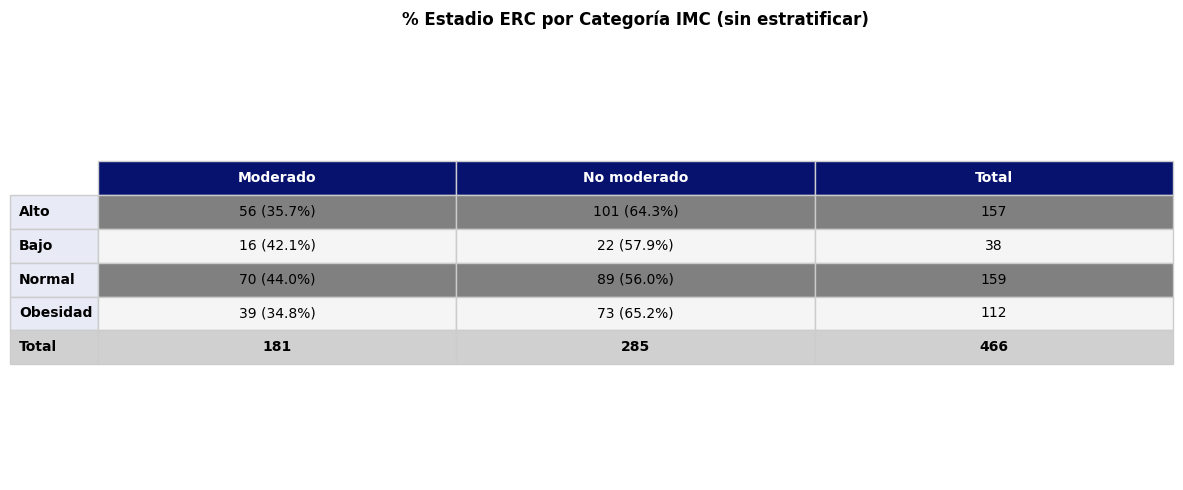

In [109]:
tabla_global, chi2_global, p_global = chi_cuadrado_completo(
    datos_chi, VAR_ESTADO_NUT, VAR_ERC,
    titulo='Estado nutricional vs Estadio ERC — Sin estratificar'
)
plot_contingencia(datos_chi, VAR_ESTADO_NUT, VAR_ERC,
                  titulo='% Estadio ERC por Categoría IMC (sin estratificar)')

***Estratificado por presencia de HTA***


  ESTRATIFICADO POR HIPERTENSIÓN

  Estado nutricional vs Estadio ERC — Hipertension: Si (n=198)

Tabla de contingencia (n):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                       22           44
Bajo                        7            8
Normal                     34           38
Obesidad                   20           25

Tabla de contingencia (% por fila):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     33.3         66.7
Bajo                     46.7         53.3
Normal                   47.2         52.8
Obesidad                 44.4         55.6

Frecuencias esperadas:
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     27.7         38.3
Bajo                      6.3          8.7
Normal                   30.2         41.8
Obesidad                 18.9         26.1

→ Supuesto frecuencias esperadas ≥ 5: 

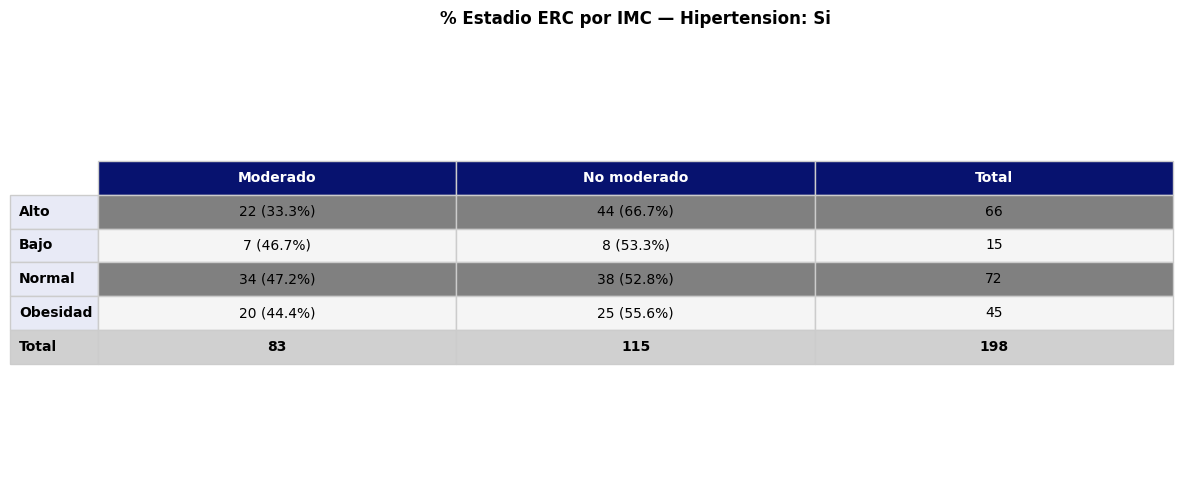


  Estado nutricional vs Estadio ERC — Hipertension: No (n=268)

Tabla de contingencia (n):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                       34           57
Bajo                        9           14
Normal                     36           51
Obesidad                   19           48

Tabla de contingencia (% por fila):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     37.4         62.6
Bajo                     39.1         60.9
Normal                   41.4         58.6
Obesidad                 28.4         71.6

Frecuencias esperadas:
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     33.3         57.7
Bajo                      8.4         14.6
Normal                   31.8         55.2
Obesidad                 24.5         42.5

→ Supuesto frecuencias esperadas ≥ 5: ✓ CUMPLE (100% celdas ok)

Chi-cua

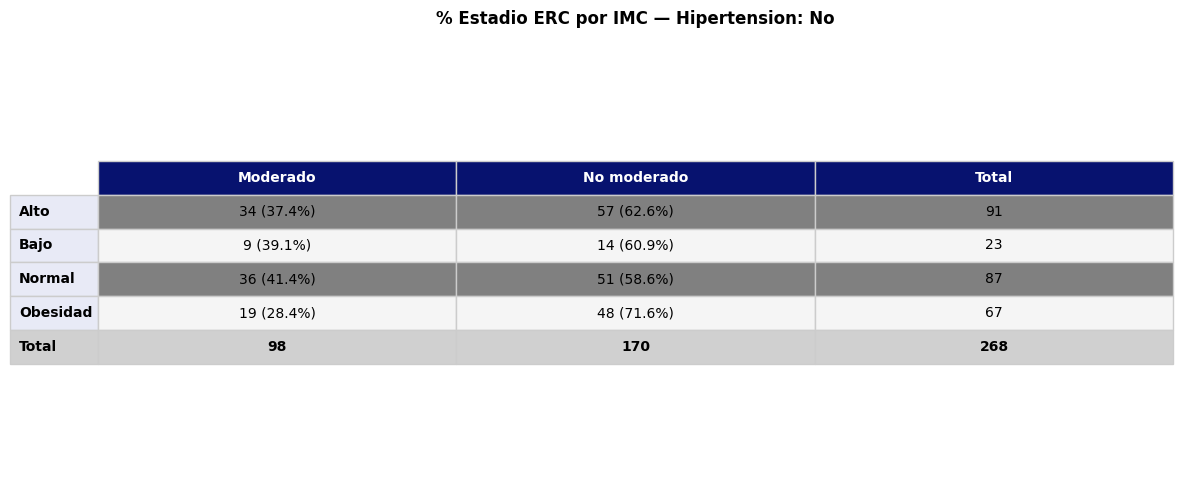

In [110]:
print("\n" + "="*60)
print("  ESTRATIFICADO POR HIPERTENSIÓN")
print("="*60)

for estrato in datos_chi[VAR_HTA].unique():
    subset = datos_chi[datos_chi[VAR_HTA] == estrato]
    chi_cuadrado_completo(
        subset, VAR_ESTADO_NUT, VAR_ERC,
        titulo=f'Estado nutricional vs Estadio ERC — {VAR_HTA}: {estrato} (n={len(subset)})'
    )
    plot_contingencia(
        subset, VAR_ESTADO_NUT, VAR_ERC,
        titulo=f'% Estadio ERC por IMC — {VAR_HTA}: {estrato}'
    )

***Estratificado por DM***


  ESTRATIFICADO POR DIABETES

  Estado nutricional vs Estadio ERC — Medicacion_Diabetes: Si (n=33)

Tabla de contingencia (n):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                        3            6
Bajo                        0            1
Normal                      7            6
Obesidad                    3            7

Tabla de contingencia (% por fila):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     33.3         66.7
Bajo                      0.0        100.0
Normal                   53.8         46.2
Obesidad                 30.0         70.0

Frecuencias esperadas:
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                      3.5          5.5
Bajo                      0.4          0.6
Normal                    5.1          7.9
Obesidad                  3.9          6.1

→ Supuesto frecuencias esperadas ≥ 5

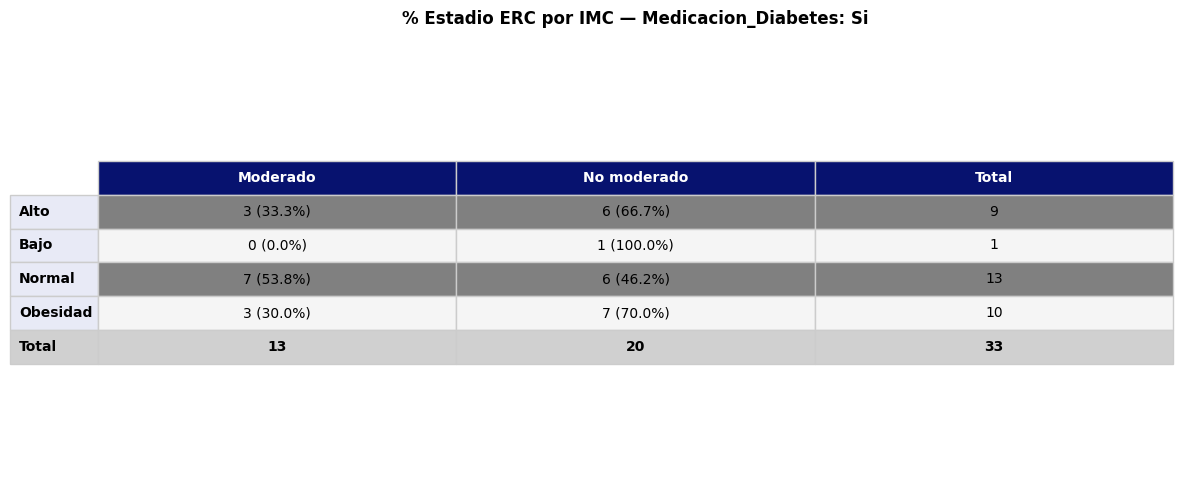


  Estado nutricional vs Estadio ERC — Medicacion_Diabetes: No (n=433)

Tabla de contingencia (n):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                       53           95
Bajo                       16           21
Normal                     63           83
Obesidad                   36           66

Tabla de contingencia (% por fila):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     35.8         64.2
Bajo                     43.2         56.8
Normal                   43.2         56.8
Obesidad                 35.3         64.7

Frecuencias esperadas:
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     57.4         90.6
Bajo                     14.4         22.6
Normal                   56.6         89.4
Obesidad                 39.6         62.4

→ Supuesto frecuencias esperadas ≥ 5: ✓ CUMPLE (100% celdas ok)



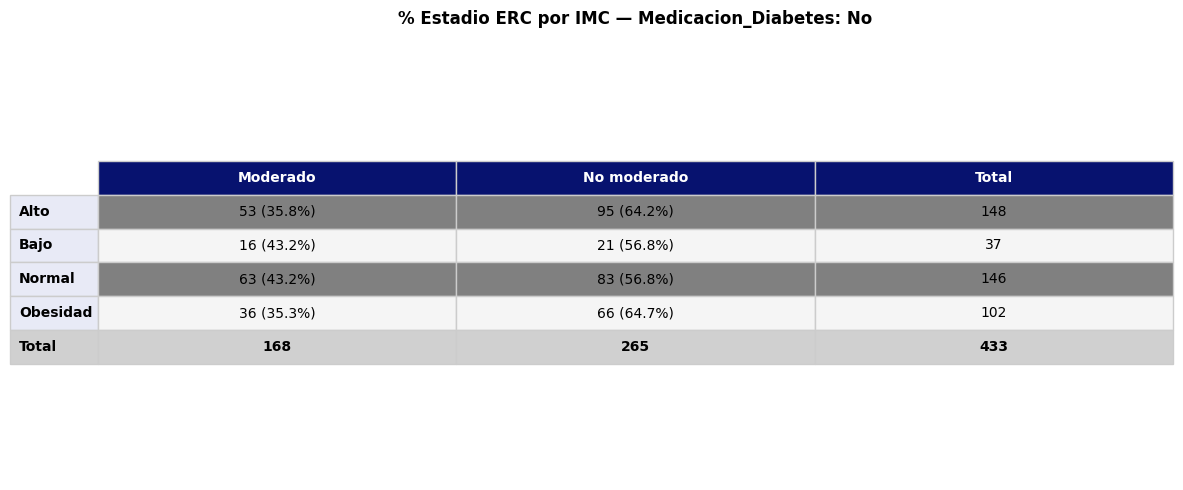

In [111]:
print("\n" + "="*60)
print("  ESTRATIFICADO POR DIABETES")
print("="*60)

for estrato in datos_chi[VAR_DM].unique():
    subset = datos_chi[datos_chi[VAR_DM] == estrato]
    chi_cuadrado_completo(
        subset, VAR_ESTADO_NUT, VAR_ERC,
        titulo=f'Estado nutricional vs Estadio ERC — {VAR_DM}: {estrato} (n={len(subset)})'
    )
    plot_contingencia(
        subset, VAR_ESTADO_NUT, VAR_ERC,
        titulo=f'% Estadio ERC por IMC — {VAR_DM}: {estrato}'
    )

In [112]:
print("\n" + "="*60)
print("  RESUMEN DE RESULTADOS")
print("="*60)
print(f"{'Análisis':<45} {'χ²':>8} {'p-valor':>10} {'Sig':>6}")
print("-"*60)

analisis_list = [('Sin estratificar', datos_chi)]
for estrato in datos_chi[VAR_HTA].unique():
    analisis_list.append((f'HTA: {estrato}', datos_chi[datos_chi[VAR_HTA] == estrato]))
for estrato in datos_chi[VAR_DM].unique():
    analisis_list.append((f'DM: {estrato}', datos_chi[datos_chi[VAR_DM] == estrato]))

for nombre, subset in analisis_list:
    tabla = pd.crosstab(subset[VAR_ESTADO_NUT], subset[VAR_ERC])
    chi2, p, dof, esp = stats.chi2_contingency(tabla)
    sig = '✓' if p < 0.05 else '✗'
    print(f"{nombre:<45} {chi2:>8.3f} {p:>10.4f} {sig:>6}")


  RESUMEN DE RESULTADOS
Análisis                                            χ²    p-valor    Sig
------------------------------------------------------------
Sin estratificar                                 3.396     0.3345      ✗
HTA: Si                                          3.087     0.3785      ✗
HTA: No                                          2.905     0.4065      ✗
DM: Si                                           2.295     0.5134      ✗
DM: No                                           2.556     0.4652      ✗


##### ***Chi-cuadrado de Mantel-Haenszel***

El Chi-cuadrado de Mantel-Haenszel es una prueba que evalúa la asociación entre dos variables categóricas mientras controla el efecto de una tercera variable (el estratificador), combinando la información de múltiples tablas de contingencia (una por cada estrato) en un único estadístico ponderado. A diferencia de analizar cada estrato por separado, este método pondera la contribución de cada tabla según su tamaño y variabilidad interna, produciendo una medida resumen de la asociación condicional entre las dos variables principales, es decir, la asociación que persiste después de remover la influencia de la variable de estratificación.

En el contexto clínico, esta prueba es central en estudios epidemiológicos y de investigación en salud porque permite responder preguntas del tipo "¿la asociación entre exposición y desenlace se mantiene después de ajustar por una comorbilidad o factor de riesgo conocido?", sin necesidad de construir un modelo multivariado completo. Es particularmente útil para detectar confusión (cuando el estratificador distorsiona la relación observada) y modificación de efecto (cuando la fuerza de la asociación difiere claramente entre estratos, sugiriendo que el efecto de la exposición no es uniforme en toda la población).

In [113]:
VAR_ESTADO_NUT = 'Categoria_IMC'
VAR_ERC        = 'Estadio_ERC_Binaria'
VAR_HTA        = 'Hipertension'
VAR_DM         = 'Medicacion_Diabetes'

cols = [VAR_ESTADO_NUT, VAR_ERC, VAR_HTA, VAR_DM]
datos_mh = df_tfg[cols].dropna()

print(f"Observaciones: {len(datos_mh)}")
print(f"\n{VAR_ESTADO_NUT}:\n{datos_mh[VAR_ESTADO_NUT].value_counts()}")
print(f"\n{VAR_ERC}:\n{datos_mh[VAR_ERC].value_counts()}")
print(f"\n{VAR_HTA}:\n{datos_mh[VAR_HTA].value_counts()}")
print(f"\n{VAR_DM}:\n{datos_mh[VAR_DM].value_counts()}")

Observaciones: 466

Categoria_IMC:
Categoria_IMC
Normal      159
Alto        157
Obesidad    112
Bajo         38
Name: count, dtype: int64

Estadio_ERC_Binaria:
Estadio_ERC_Binaria
No moderado    285
Moderado       181
Name: count, dtype: int64

Hipertension:
Hipertension
No    268
Si    198
Name: count, dtype: int64

Medicacion_Diabetes:
Medicacion_Diabetes
No    433
Si     33
Name: count, dtype: int64


***Sin estratificar***

In [114]:
print("\n" + "="*65)
print("  ANÁLISIS GLOBAL — SIN ESTRATIFICAR")
print("="*65)
tabla_global = pd.crosstab(datos_mh[VAR_ESTADO_NUT], datos_mh[VAR_ERC])
chi2_g, p_g, dof_g, _ = stats.chi2_contingency(tabla_global)
print(f"\nChi²={chi2_g:.4f}, gl={dof_g}, p-valor={p_g:.4f}")
print(f"→ {'Asociación significativa' if p_g < 0.05 else 'Sin asociación significativa'} (α=0.05)")
print(tabla_global)


  ANÁLISIS GLOBAL — SIN ESTRATIFICAR

Chi²=3.3962, gl=3, p-valor=0.3345
→ Sin asociación significativa (α=0.05)
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                       56          101
Bajo                       16           22
Normal                     70           89
Obesidad                   39           73


***Estratificado por HTA***


  Estado nutricional vs Estadio ERC — Estratificado por HTA
  Estratificado por: Hipertension

  Estrato [Hipertension = Si] — n=198
  Chi²=3.0867, gl=3, p=0.3785 ✗ No sig.

  Tabla de contingencia (n):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                       22           44
Bajo                        7            8
Normal                     34           38
Obesidad                   20           25

  Tabla de contingencia (% por fila):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     33.3         66.7
Bajo                     46.7         53.3
Normal                   47.2         52.8
Obesidad                 44.4         55.6

  Estrato [Hipertension = No] — n=268
  Chi²=2.9050, gl=3, p=0.4065 ✗ No sig.

  Tabla de contingencia (n):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                       34           57
Baj

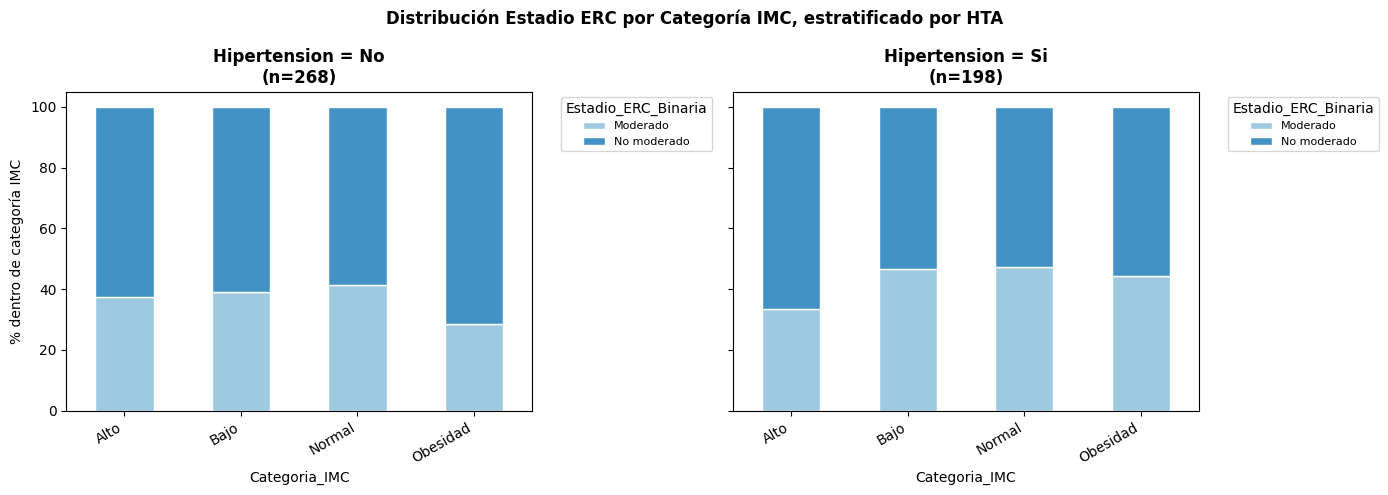

In [115]:
tabla_hta, chi2_hta, p_hta = mantel_haenszel(
    datos_mh, VAR_ESTADO_NUT, VAR_ERC, VAR_HTA,
    titulo='Estado nutricional vs Estadio ERC — Estratificado por HTA'
)
plot_estratificado(
    datos_mh, VAR_ESTADO_NUT, VAR_ERC, VAR_HTA,
    titulo='Distribución Estadio ERC por Categoría IMC, estratificado por HTA'
)

***Estratificado por presencia de DM***


  Estado nutricional vs Estadio ERC — Estratificado por DM
  Estratificado por: Medicacion_Diabetes

  Estrato [Medicacion_Diabetes = Si] — n=33
  Chi²=2.2954, gl=3, p=0.5134 ✗ No sig.

  Tabla de contingencia (n):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                        3            6
Bajo                        0            1
Normal                      7            6
Obesidad                    3            7

  Tabla de contingencia (% por fila):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     33.3         66.7
Bajo                      0.0        100.0
Normal                   53.8         46.2
Obesidad                 30.0         70.0

  Estrato [Medicacion_Diabetes = No] — n=433
  Chi²=2.5563, gl=3, p=0.4652 ✗ No sig.

  Tabla de contingencia (n):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                       

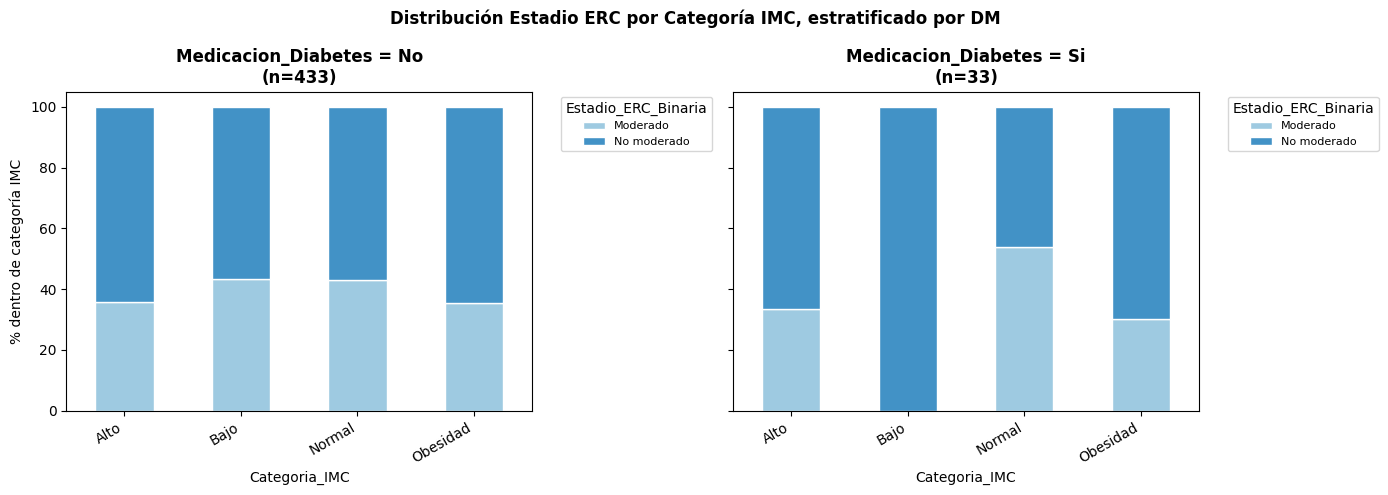

In [116]:
tabla_dm, chi2_dm, p_dm = mantel_haenszel(
    datos_mh, VAR_ESTADO_NUT, VAR_ERC, VAR_DM,
    titulo='Estado nutricional vs Estadio ERC — Estratificado por DM'
)
plot_estratificado(
    datos_mh, VAR_ESTADO_NUT, VAR_ERC, VAR_DM,
    titulo='Distribución Estadio ERC por Categoría IMC, estratificado por DM'
)

#### **Regresión ordinal**

La regresión logística ordinal modela la probabilidad de pertenecer a un estadio de ERC igual o más grave, asumiendo que detrás de las cuatro categorías observadas (G1 a G4) existe una escala continua de severidad renal no observada, sobre la cual el modelo estima puntos de corte que delimitan cada categoría. A diferencia de tratar el estadio de ERC como una variable numérica (que forzaría distancias iguales entre G1-G2 y G3-G4) o como categórica sin orden (que ignoraría que G4 es clínicamente peor que G1), este modelo respeta la progresión de gravedad sin asumir que el salto entre categorías consecutivas sea matemáticamente idéntico. El predictor, en este caso Categoria_IMC, recibe un único coeficiente que representa cuánto desplaza cada categoría de IMC esa severidad latente hacia un estadio más avanzado, bajo el supuesto de que ese efecto se mantiene constante sin importar en qué punto de la escala de gravedad se evalúe (el supuesto de odds proporcionales).

Para evaluar la relación estratificada por HTA y DM, este modelo resulta especialmente útil porque, al ajustarse por separado dentro de cada subgrupo (con y sin hipertensión, con y sin diabetes), permite cuantificar si la fuerza de la asociación entre estado nutricional y severidad de ERC cambia según la presencia de estas comorbilidades, expresando esa diferencia directamente en Odds Ratios comparables entre estratos, con sus intervalos de confianza. Esto va más allá de lo que ofrece un Chi-cuadrado estratificado, que solo indica si existe o no asociación en cada subgrupo: la regresión ordinal estima la magnitud y dirección del efecto de cada categoría de IMC sobre el riesgo de progresión renal dentro de cada estrato, permitiendo identificar con precisión si la hipertensión o la diabetes actúan como factores que amplifican, atenúan o no modifican sustancialmente la relación entre obesidad y deterioro de la función renal.

In [119]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

VAR_ESTADO_NUT = 'Categoria_IMC'
VAR_ERC        = 'Estadio_ERC_Binaria'
VAR_HTA        = 'Hipertension'
VAR_DM         = 'Medicacion_Diabetes'

datos_ord = df_tfg[[VAR_ESTADO_NUT, VAR_ERC, VAR_HTA, VAR_DM]].dropna()

orden_erc = ['No moderado', 'Moderado']

datos_ord[VAR_ERC] = pd.Categorical(datos_ord[VAR_ERC], categories=orden_erc, ordered=True)

print(f"Observaciones: {len(datos_ord)}")
print(datos_ord[VAR_ERC].value_counts().sort_index())

Observaciones: 466
Estadio_ERC_Binaria
No moderado    285
Moderado       181
Name: count, dtype: int64


***Sin estratificar***

In [121]:
modelo_global, or_global = ajustar_logistico_ordinal(
    datos_ord, [VAR_ESTADO_NUT], VAR_ERC,
    titulo='Modelo logístico ordinal — Sin estratificar (solo Categoria_IMC)'
)


  Modelo logístico ordinal — Sin estratificar (solo Categoria_IMC)
  n = 466
                              OrderedModel Results                             
Dep. Variable:     Estadio_ERC_Binaria   Log-Likelihood:                -309.61
Model:                    OrderedModel   AIC:                             627.2
Method:             Maximum Likelihood   BIC:                             643.8
Date:                 Thu, 18 Jun 2026                                         
Time:                         17:43:36                                         
No. Observations:                  466                                         
Df Residuals:                      462                                         
Df Model:                            3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Categoria_IMC_Bajo  

***Estratificado por HTA***

In [122]:
print("\n" + "="*65)
print("  ESTRATIFICADO POR HIPERTENSIÓN")
print("="*65)

resultados_hta = {}
for estrato in datos_ord[VAR_HTA].unique():
    subset = datos_ord[datos_ord[VAR_HTA] == estrato]
    try:
        modelo, or_tabla = ajustar_logistico_ordinal(
            subset, [VAR_ESTADO_NUT], VAR_ERC,
            titulo=f'{VAR_HTA} = {estrato}'
        )
        resultados_hta[estrato] = (modelo, or_tabla)
    except Exception as e:
        print(f"\n⚠️ No se pudo ajustar el modelo para {VAR_HTA}={estrato}: {e}")


  ESTRATIFICADO POR HIPERTENSIÓN

  Hipertension = Si
  n = 198
                              OrderedModel Results                             
Dep. Variable:     Estadio_ERC_Binaria   Log-Likelihood:                -133.08
Model:                    OrderedModel   AIC:                             274.2
Method:             Maximum Likelihood   BIC:                             287.3
Date:                 Thu, 18 Jun 2026                                         
Time:                         17:43:36                                         
No. Observations:                  198                                         
Df Residuals:                      194                                         
Df Model:                            3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Categoria_IMC_Bajo         0.5598

***Estratificado por DM***

In [123]:
print("\n" + "="*65)
print("  ESTRATIFICADO POR DIABETES")
print("="*65)

resultados_dm = {}
for estrato in datos_ord[VAR_DM].unique():
    subset = datos_ord[datos_ord[VAR_DM] == estrato]
    try:
        modelo, or_tabla = ajustar_logistico_ordinal(
            subset, [VAR_ESTADO_NUT], VAR_ERC,
            titulo=f'{VAR_DM} = {estrato}'
        )
        resultados_dm[estrato] = (modelo, or_tabla)
    except Exception as e:
        print(f"\n⚠️ No se pudo ajustar el modelo para {VAR_DM}={estrato}: {e}")


  ESTRATIFICADO POR DIABETES

  Medicacion_Diabetes = Si
  n = 33
                              OrderedModel Results                             
Dep. Variable:     Estadio_ERC_Binaria   Log-Likelihood:                -20.810
Model:                    OrderedModel   AIC:                             49.62
Method:             Maximum Likelihood   BIC:                             55.61
Date:                 Thu, 18 Jun 2026                                         
Time:                         17:43:37                                         
No. Observations:                   33                                         
Df Residuals:                       29                                         
Df Model:                            3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Categoria_IMC_Bajo       -12.10

c:\Users\Mari\miniconda3\envs\deepl_venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [124]:
#Resumen consolidado de Odds Ratios — comparación entre estratos
print("\n" + "="*65)
print("  RESUMEN: OR de Categoria_IMC en cada análisis")
print("="*65)

print("\n--- Sin estratificar ---")
print(or_global.round(4))

print("\n--- Por estrato de HTA ---")
for estrato, (modelo, or_tabla) in resultados_hta.items():
    print(f"\n{VAR_HTA} = {estrato}:")
    print(or_tabla.round(4))

print("\n--- Por estrato de DM ---")
for estrato, (modelo, or_tabla) in resultados_dm.items():
    print(f"\n{VAR_DM} = {estrato}:")
    print(or_tabla.round(4))


  RESUMEN: OR de Categoria_IMC en cada análisis

--- Sin estratificar ---
                            OR  IC_2.5%  IC_97.5%  p_valor
Categoria_IMC_Bajo      1.3114   0.6371    2.6998   0.4617
Categoria_IMC_Normal    1.4182   0.9021    2.2296   0.1301
Categoria_IMC_Obesidad  0.9633   0.5798    1.6004   0.8852

--- Por estrato de HTA ---

Hipertension = Si:
                            OR  IC_2.5%  IC_97.5%  p_valor
Categoria_IMC_Bajo      1.7504   0.5619    5.4520   0.3342
Categoria_IMC_Normal    1.7895   0.8976    3.5674   0.0983
Categoria_IMC_Obesidad  1.5999   0.7338    3.4886   0.2373

Hipertension = No:
                            OR  IC_2.5%  IC_97.5%  p_valor
Categoria_IMC_Bajo      1.0773   0.4212    2.7549   0.8766
Categoria_IMC_Normal    1.1834   0.6481    2.1605   0.5836
Categoria_IMC_Obesidad  0.6635   0.3361    1.3099   0.2372

--- Por estrato de DM ---

Medicacion_Diabetes = Si:
                            OR  IC_2.5%  IC_97.5%  p_valor
Categoria_IMC_Bajo      0.0000   0.0

### **Regresión logística binaria simple**

In [125]:
# Celda 2: Preparar datos
VAR_DEP  = 'Estadio_ERC_Binaria'
VAR_PRED = 'Categoria_IMC'

datos_log = df_tfg[[VAR_DEP, VAR_PRED]].dropna()

print(f"Observaciones: {len(datos_log)}")
print(f"\n{VAR_DEP}:\n{datos_log[VAR_DEP].value_counts()}")
print(f"\n{VAR_PRED}:\n{datos_log[VAR_PRED].value_counts()}")

Observaciones: 466

Estadio_ERC_Binaria:
Estadio_ERC_Binaria
No moderado    285
Moderado       181
Name: count, dtype: int64

Categoria_IMC:
Categoria_IMC
Normal      159
Alto        157
Obesidad    112
Bajo         38
Name: count, dtype: int64


In [126]:
print("Categorías de la variable dependiente y su codificación:")
print(pd.Categorical(datos_log[VAR_DEP]).categories)

Categorías de la variable dependiente y su codificación:
Index(['Moderado', 'No moderado'], dtype='object')


In [128]:
datos_log['Estadio_ERC_Binaria_num'] = datos_log['Estadio_ERC_Binaria'].map({
    'No moderado': 0,  
    'Moderado': 1    
})

In [129]:
modelo_log = smf.logit('Estadio_ERC_Binaria_num ~ C(Categoria_IMC)', data=datos_log).fit()
print(modelo_log.summary())

Optimization terminated successfully.
         Current function value: 0.664398
         Iterations 4
                              Logit Regression Results                             
Dep. Variable:     Estadio_ERC_Binaria_num   No. Observations:                  466
Model:                               Logit   Df Residuals:                      462
Method:                                MLE   Df Model:                            3
Date:                     Thu, 18 Jun 2026   Pseudo R-squ.:                0.005440
Time:                             17:47:26   Log-Likelihood:                -309.61
converged:                            True   LL-Null:                       -311.30
Covariance Type:                 nonrobust   LLR p-value:                    0.3357
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       

### **Regresión múltiple**

In [130]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
VAR_DEP   = 'Estadio_ERC_Binaria'  
VAR_IMC   = 'Categoria_IMC'
VAR_HTA   = 'Hipertension'
VAR_DM    = 'Medicacion_Diabetes'

cols = ['Estadio_ERC_Binaria', VAR_IMC, VAR_HTA, VAR_DM]
datos_mult = df_tfg[cols].dropna()

datos_mult[VAR_DEP] = datos_mult['Estadio_ERC_Binaria'].map({
    'No moderado': 0,   
    'Moderado': 1    
})

print(f"Observaciones: {len(datos_mult)}")
print(f"\n{VAR_DEP}:\n{datos_mult[VAR_DEP].value_counts()}")
print(f"\n{VAR_HTA}:\n{datos_mult[VAR_HTA].value_counts()}")
print(f"\n{VAR_DM}:\n{datos_mult[VAR_DM].value_counts()}")

Observaciones: 466

Estadio_ERC_Binaria:
Estadio_ERC_Binaria
0    285
1    181
Name: count, dtype: int64

Hipertension:
Hipertension
No    268
Si    198
Name: count, dtype: int64

Medicacion_Diabetes:
Medicacion_Diabetes
No    433
Si     33
Name: count, dtype: int64


In [134]:
formula = f'{VAR_DEP} ~ C({VAR_IMC}) + C({VAR_HTA}) + C({VAR_DM})'
modelo_mult = smf.logit(formula, data=datos_mult).fit()
print(modelo_mult.summary())

Optimization terminated successfully.
         Current function value: 0.663035
         Iterations 4
                            Logit Regression Results                           
Dep. Variable:     Estadio_ERC_Binaria   No. Observations:                  466
Model:                           Logit   Df Residuals:                      460
Method:                            MLE   Df Model:                            5
Date:                 Thu, 18 Jun 2026   Pseudo R-squ.:                0.007481
Time:                         17:52:20   Log-Likelihood:                -308.97
converged:                        True   LL-Null:                       -311.30
Covariance Type:             nonrobust   LLR p-value:                    0.4590
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -0.6809      0.187     -3.645   

In [135]:
or_table_mult = pd.DataFrame({
    'OR': np.exp(modelo_mult.params),
    'IC_2.5%': np.exp(modelo_mult.conf_int()[0]),
    'IC_97.5%': np.exp(modelo_mult.conf_int()[1]),
    'p_valor': modelo_mult.pvalues
}).round(4)

print("Odds Ratios ajustados:")
print(or_table_mult)

Odds Ratios ajustados:
                                  OR  IC_2.5%  IC_97.5%  p_valor
Intercept                     0.5062   0.3510    0.7299   0.0003
C(Categoria_IMC)[T.Bajo]      1.3174   0.6390    2.7161   0.4552
C(Categoria_IMC)[T.Normal]    1.4120   0.8973    2.2220   0.1359
C(Categoria_IMC)[T.Obesidad]  0.9694   0.5827    1.6127   0.9047
C(Hipertension)[T.Si]         1.2482   0.8486    1.8359   0.2601
C(Medicacion_Diabetes)[T.Si]  0.9372   0.4443    1.9769   0.8648
